In [1]:
# general libraries
import numpy as np
import pandas as pd
import scipy.integrate as integrate
import scipy.special as special
from scipy.integrate import quad
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker
from IPython.display import Video

# project libraries
from lcpalib import presets as ps
from lcpalib import plotting as pl

# matplotlib setup and numpy random seed
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline
np.random.seed(311)

# Simulation of a positron-induced Muon Source (part 1)

The production of a high brillance muon beam is one of the most important challenge for the future of Particle Physics. A particularly interesting idea consists of shooting high energy positrons on a target, aiming at the production of muons by means of the process $e^+ + e^- \rightarrow \mu^+ + \mu^-$. To mimize the divergence of the resulting "muon beam", the positrons energy is chosen so that the reaction occurs close to threshold (assuming the electrons in the target to be at rest). The main goal of this project is to produce a Monte Carlo simulation of such a process.

### Authors:
Andrea Semenzato, Pietro Bernardi, Tomas Mezquita, Mariam Chokheli


### Supervisor:
Prof.Marco Zanetti

In [2]:
# set this to kPRES to switch to presentation mode and avoid re-calculation of quantities
MODE = ps.kEDIT

# constants
mu_mass=0.105658374524 #muon mass in GeV
e_mass = 0.0005109989461 # GeV
fsc=1/137. #fine structure constant
conv = 0.389379e6 #GeV^-1 to nB
E_sim=2*mu_mass + 0.005

### Point 1
Compute the process leading-order cross section, $\sigma(\theta;\sqrt{s})$, as a function of the scattering angle $\theta$ and with the center of mass energy $\sqrt{s}$ as a parameter.

### Cross section in the center of mass frame.
The process
$ e^- + e^+ \rightarrow \mu^- + \mu^+ $
is fundamental in the understanding of QED theory, and very important in high energy physics for the understanding of $e^-e^+$ colliders and more complicated processes.
<br>
Let's compute the cross-section of this process in the center of the mass frame. First, let's discuss the mass order of the fermions: as we know this process has an energy about the order of at least two times the muon mass. Also recall that $m_\mu/m_e\sim 200$, so $m_e^2<<s$, consequently, we can assume an electron massless limit, while the muon mass cannot be negligible.

Also recall that $s$ is a Mandelstam variable and corresponds to $s=(p_1+p_2)^2=(p_3+p_4)^2$.

Firstly, we need to compute the Feynmann diagram and the correspondent amplitude $\mathcal{M}$, following the Feynmann rules.
<div align="center">
    <img src="./img/FDME.png" alt="Feynmann diagram" width="400">
</div>

$$i\mathcal{M}=\frac{ie^2}{s} [\bar{v}(p_2) \gamma^\mu u(p_1)] [\bar{u}(p_3) \gamma_\mu v(p_4)] $$

As we can see, this process can be only possible through an s-channel. The next step is to compute the summed squared amplitude over the initial polarization states:

$$|\mathcal{\bar{M}}|^2=\frac{8e^4}{s^2} [(p_1\cdot p_3)(p_2\cdot p_4)+(p_1\cdot p_4)(p_2\cdot p_3)+m_\mu^2(p_1\cdot p_2)]$$

Let's now apply the center of mass frame and energy/momentum conservation, we can express the 4-momentum of all the particles in the following way:

<div align="center">
    <img src="./img/CoM.png" width="700">
</div>

Using that in the electron massless limit $s=(p_1+p_2)^2=2(p_1\cdot p_2)=4E^2$, we can establish the relation $E=\frac{\sqrt{s}}{2}$, and $|\vec{k}|=\sqrt{E^2-m_\mu^2}=\frac{1}{2}\sqrt{s-4m_\mu^2}$.

We can write the summed squared amplitude over the initial polarization states as a funtion of $s$ and $\theta$ variables:

$$|\mathcal{\bar{M}}|^2=16\pi^2\alpha^2\left[\left(1+\frac{4m_\mu^2}{s}\right)+\left(1-\frac{4m_\mu^2}{s}\right)\cos^2{\theta}\right]$$

We can now compute the differential cross section using the following expression: $\frac{d\sigma}{d\Omega}=\frac{1}{64\pi^2 s}\frac{|\vec{k}|}{E}|\mathcal{\bar{M}}|^2$. We get the following expression:

$$\left(\frac{d\sigma}{d\Omega}\right)_{CM}=\frac{ \alpha^2}{4 s} \sqrt{1-\frac{4m_\mu^2}{s}} \left[\left(1+\frac{4m_\mu^2}{s}\right)+\left(1-\frac{4m_\mu^2}{s}\right)\cos^2{\theta}\right]$$

Now we integrate the differential cross section in order to get the total cross section:

$$\sigma=\int_{-1}^{1} \frac{d\sigma}{d\Omega} d\Omega= \frac{4\pi \alpha^2}{3s} \sqrt{1-\frac{4m_\mu^2}{s}} \left(1+\frac{2m_\mu^2}{s}\right) $$

Let's start now with the computation and analysis of all this magnitudes:

In [3]:
#Functions
def cross_section(s=E_sim**2): #s in GeV^2
    return (4*np.pi*fsc**2)/(3*s)*np.sqrt(1-4*mu_mass**2/s)*(1+2*mu_mass**2/s)*conv

def dif_cross_section(theta, s=E_sim**2):
    return (fsc**2)/(4*s)*np.sqrt(1-4*mu_mass**2/s)*((1+4*mu_mass**2/s)+(1-4*mu_mass**2/s)*(np.cos(theta))**2)*conv

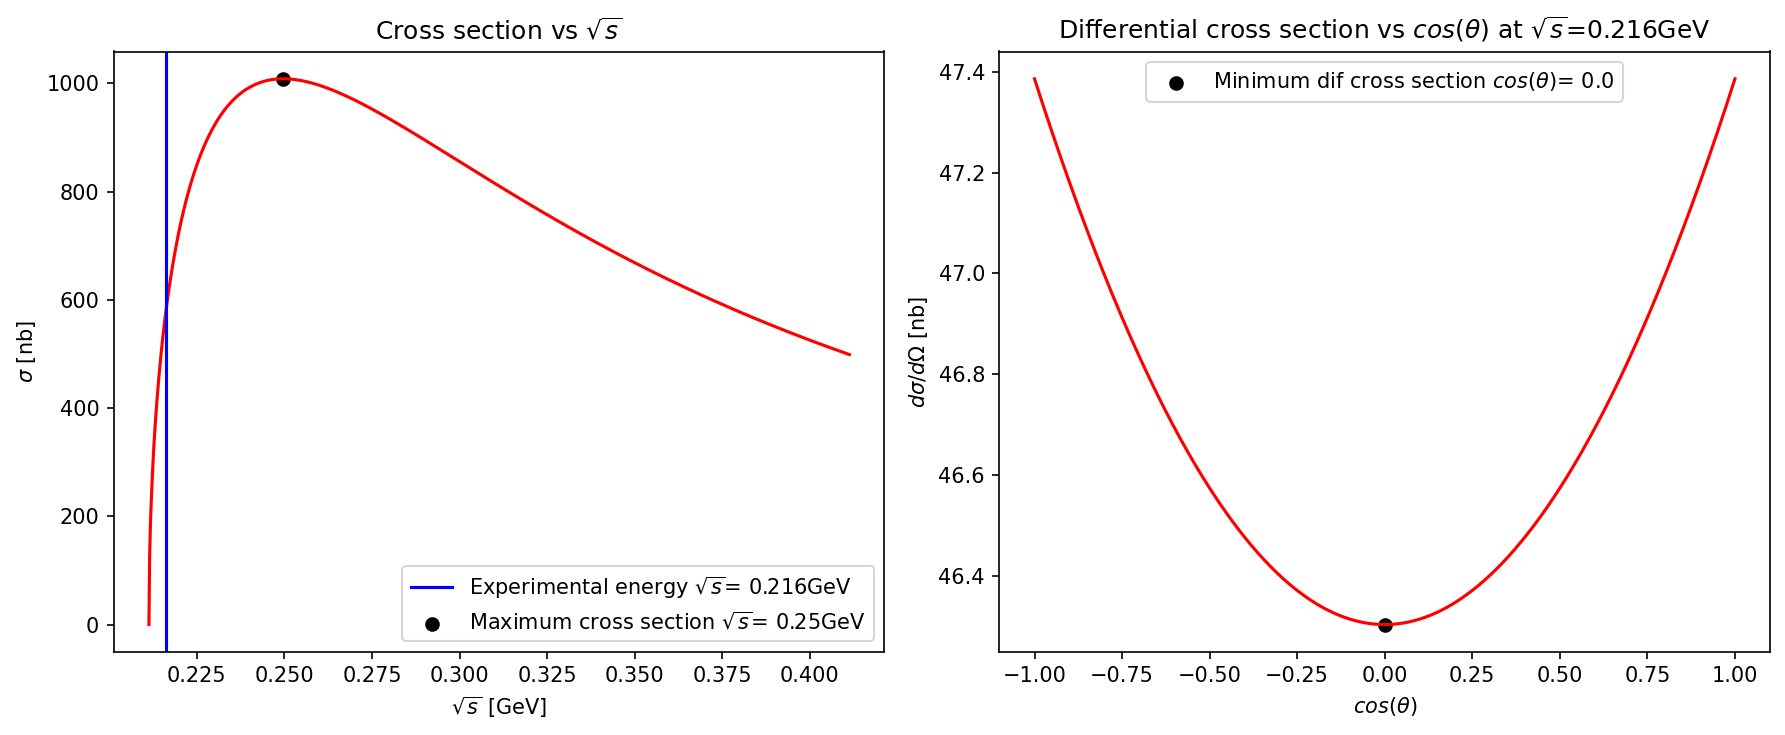

In [4]:
# getting some energy and theta values for plotting reasons
N_pts = 1000
E_values=np.linspace(2*mu_mass,2*mu_mass+0.2,N_pts)
theta_values=np.linspace(0,np.pi,N_pts)

# getting the coordinates for the max of the total cross section
idx = np.argmax(cross_section(s=E_values**2))
E_maxcs=E_values[idx]

# getting the coordinates for the min of the differential cross section
idx2=np.argmin(dif_cross_section(theta_values, s=E_sim**2))
theta_mincs=theta_values[idx2]

# plotting
fig, ax = plt.subplots(1,2, figsize=(12,5))
# pad 0
ax[0].plot(E_values,cross_section(E_values**2), c='r')
ax[0].axvline(E_sim, label=r'Experimental energy $\sqrt{s}$= '+ str(round(E_sim,3)) +"GeV", c='b')
ax[0].scatter(E_maxcs,cross_section(E_maxcs**2), label=r'Maximum cross section $\sqrt{s}$= '+ str(round(E_maxcs,3)) +"GeV", c='k')
ax[0].set_xlabel(r'$\sqrt{s}$ [GeV]')
ax[0].set_ylabel(r'$\sigma$ [nb]')
ax[0].set_title(r'Cross section vs $\sqrt{s}$')
ax[0].legend()
# pad 1
ax[1].plot(np.cos(theta_values),dif_cross_section(theta_values, s=E_sim**2), c='r')
ax[1].scatter(np.cos(theta_mincs),dif_cross_section(theta_mincs, s=E_sim**2), label=r'Minimum dif cross section $cos(\theta$)= '+ str(round(np.cos(theta_mincs),1)), c='k')
ax[1].set_xlabel(r'$cos(\theta)$')
ax[1].set_ylabel(r'$d\sigma/d\Omega$ [nb]')
ax[1].set_title(r'Differential cross section vs $cos(\theta)$ at $\sqrt{s}$='+ str(round(E_sim,3)) +"GeV")
ax[1].legend()
# showing
fig.tight_layout()

We have computed the total cross-section, which measures the probability that this process will take place. The cross-section is a function of the energy $\sqrt{s}$.

Let's analyze the first graph: for energies lower than $\sqrt{s} \sim 2m_{\mu}$, the process doesn't take place as the energy of the particles is not sufficient for the process to occur. Then, the total cross-section increases with energy until reaching a maximum at $\sqrt{s} = 0.25$ GeV, close to the low energy limit, where the process is more likely to take place. From higher energies, the cross-section slowly decreases, as particles with excessively more energy will collide less frequently, resulting in fewer processes taking place.


As for the second graph, we are going to study the differential cross-section, which is also a function of the scattering angle $\theta$, so are going to fix an experimental energy (also shown in graph 1) to study its dependence on $\cos{\theta}$. We can immediately observe a quadratic relation which is already reflected in the differential cross-section expression ($\frac{d\sigma}{d\Omega}\propto \cos{\theta}^{2}$). A minimum is found at $\cos{\theta} = 0$, corresponding to $\theta = 90^\degree$. This will be related to the angular distribution, which will be discussed in the next point.

### Point 2 
Compute and display the angle and momentum components distributions of the emerging muon pairs.

### Angle and momentum components distributions of the emerging muon pairs

The probability distribution function of the theta angle is given by ($ d\Omega=d\cos{\theta}d\phi)$:

$$
P(\theta) = \frac{d\sigma}{d\theta} = \int_{0}^{2\pi} d\phi \sin\theta \left(\frac{d\sigma}{d\Omega}\right) = 2\pi\sin\theta\left(\frac{d\sigma}{d\Omega}\right)
$$

We can also define a normalized (its integral in $\theta$ range, $[0,\pi]$, should be 1) function that goes by:

$$P(\theta)_{norm}=\frac{P(\theta)}{\sigma}$$

In [5]:
def pdf(theta, s=E_sim**2):
    return dif_cross_section(theta, s)*np.sin(theta)*2*np.pi

def pdf_norm(theta, s=E_sim**2):
    return pdf(theta, s)/cross_section(s)

#Normaization check
print('Value of the cross section: '+ str(round(cross_section(s=E_sim**2),3)))
print('Value integral pdf: '+  str(round(integrate.quad(lambda theta: pdf(theta, s=E_sim**2),0,np.pi)[0],3)))
print('Value integral pdf normalized: ', str(round(integrate.quad(lambda theta: pdf_norm(theta, s=E_sim**2),0,np.pi)[0],3)))

Value of the cross section: 586.403
Value integral pdf: 586.403
Value integral pdf normalized:  1.0


Now we can compute the angle distribution and see how it evolves when the energy is increased. For a better representation, we will use an animation:

In [7]:
# useful things
sqrt_s_plot = np.linspace(2*mu_mass+0.001, 0.6, 200)
s_tot = cross_section(sqrt_s_plot**2)
theta = np.linspace(0,180,180)
pdf_theta = pdf_norm(theta*np.pi/180, E_sim**2)

if (MODE==ps.kEDIT):
    # initialize the figure
    fig = plt.figure(figsize=(12,6))
    ax0 = plt.subplot2grid((1,2), loc=(0,0), rowspan=1, colspan=1, fig=fig)
    ax1 = plt.subplot2grid((1,2), loc=(0,1), rowspan=1, colspan=1, fig=fig)
    
    # setting stuff
    ax0.set_xlim(2*mu_mass, 0.6)
    ax1.set_xlim(0, 180)
    ax1.set_ylim(0, 0.009)
    ax0.set_xlabel(r'Center of mass energy $\sqrt{s} [GeV]$')
    ax0.set_ylabel(r'Total cross section $\sigma(\sqrt{s})$')
    ax0.set_title(r'Total cross section vs Center of mass energy')
    ax1.set_title(r'Production angle probability density function')
    ax1.set_xlabel(r'$\theta$ (degrees)')
    ax1.set_ylabel(r'Probability Density')
    fig.tight_layout()
    
    # line variables
    line_ax0, = ax0.plot(sqrt_s_plot, s_tot, lw = 3)
    linescat_ax0, = ax0.plot([], [], marker='o', color='red', markersize=10)
    vline_ax0, = ax0.plot([], [], color='red', lw=1.5, linestyle='dashed')
    line_ax1, = ax1.plot([], [], lw = 3)
    txt0 = ax0.text(0,0,0,c='red')
    
    # functions
    def init():
        linescat_ax0.set_data([], [])
        vline_ax0.set_data([], [])
        line_ax1.set_data([], [])
        return line_ax1
    
    def animate(i):
        # moving the point across the plot
        linescat_ax0.set_data(sqrt_s_plot[i], s_tot[i])
        # setting the vertical line
        vline_ax0.set_data([sqrt_s_plot[i],sqrt_s_plot[i]], [-1200,1200])
        # setting text
        if (sqrt_s_plot[i] < 0.4):    
            txt0.set_position((sqrt_s_plot[i]*1.02, s_tot[i]))
        else:
            txt0.set_position((sqrt_s_plot[i]*0.80, s_tot[i]*0.9))
        txt0.set_text(r'$\sqrt{s}='+str(round(sqrt_s_plot[i],2))+r'$ GeV')
        # calculating the pdf plot
        y_tmp = pdf_norm(theta*np.pi/180, sqrt_s_plot[i]**2)
        y = y_tmp/sum(y_tmp)
        line_ax1.set_data(theta, y)
         
        return line_ax1
        #return (linescat_ax0, line_ax1)
    
    anim = FuncAnimation(fig, animate, init_func = init, frames = 200, interval = 20, blit = False) 
    
    anim.save('./img/CrossSec_ThetaPdf.mp4',  writer = 'ffmpeg', fps = 30)
    
    plt.close(fig)

/var/folders/nn/f6b1btbd1dgc4g_ddfnl2s3r0000gn/T/ipykernel_67001/1436947055.py:41: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  linescat_ax0.set_data(sqrt_s_plot[i], s_tot[i])


In [8]:
%%HTML
<div align="center">
    <video width="800" controls>
      <source src="./img/CrossSec_ThetaPdf.mp4" type="video/mp4">
    </video>
</div>

From the animation, we can see how the angle distribution evolves, in the low energy region, when $\sqrt{s} \sim 2m_{\mu}$, we can see that we obtain a single maximum at $\theta = 90 \degree$. When the energy is increased the maximum starts to flatten and two maximums start to appear, now the angle distribution is more spread, with maximum probability in two angles.

This can be explained mathematicaly by observing $P(\theta)$ expression, which is proportional to $ \sin\theta\frac{d\sigma}{d\Omega}$. For a better understanding of the explanation below, we are going to put the full expression of $P(\theta)$:

$$ P(\theta)=\frac{ \alpha^2\pi}{2 s} \sqrt{1-\frac{4m_\mu^2}{s}} \left[\left(1+\frac{4m_\mu^2}{s}\right)+\left(1-\frac{4m_\mu^2}{s}\right)\cos^2{\theta}\right]\sin{\theta}$$

- Lower energies ( $\left(1-\frac{4m_{\mu}}{s}\right) \rightarrow 0$): the differential cross-section has a very low angular dependence, that is why the only angular dependence of the distribution is given by the sine:  $P(\theta) \propto \sin{\theta}$, which will give us the maximum probability at $\theta=90 \degree $.

- Higher energies ( $\frac{4m_{\mu}}{s}<<1$): we can approximate the differential cross section to $\left(\frac{d\sigma}{d\Omega}\right) \sim \frac{\alpha^2}{4s}\left(1+\cos^2\theta\right)$, consequently we will obtain an angular distribution of:$$P(\theta) \propto (1+\cos^2\theta)\sin{\theta}$$ $$\frac{dP(\theta)}{d\theta} \propto (1+\cos^2\theta)\cos\theta-2\cos\theta\sin^2\theta=0$$ Solving the equation we obtain three critical points: one minimum at $ 90 \degree$, and two maximums around the values $\sim 55 \degree$ and $\sim 125 \degree$, which are approximately the values that we can see in the distributions for high energies. 

### Point 3

### Lorentz Boosts
In the following calculations we use c=1. The four-momentum transforms as any four-vector under Lorenz transformation[7]. We can simply make a Lorentz boost:

\begin{align}
    E' &= \gamma(E - \beta p_z) \\
    p'_x &= p_x \\
    p'_y &= p_y \\
    p'_z &= \gamma(p_z - \beta E)
\end{align}

where $\beta = v_z$ and $\gamma = (1 - \beta^2)^{-1/2}$. 

#### CoM-to-Lab frame

We can now calculate the velocity of the incoming positron:

\begin{equation*}
    \beta_{\text{CoM}} = v_z=\frac{p'_z}{E'_1+m_2} =\frac {\sqrt{E_1^2 - m_e^2}}{E'_1+m_e}=\sqrt{\frac{E_1^2-m_e^2}{(E_1+m_e)^2}}\approx\sqrt{1 - \frac{m_e^2}{E^2}}=\sqrt{1- \frac{4m_e^2}{s}}
\end{equation*}

In [9]:
momentum = np.sqrt((E_sim / 2) ** 2 - (e_mass**2)) #positron momentum using the relativistic formula
gamma = E_sim / (2 * e_mass) # Lorentz gamma factor
print(gamma)

# Computes Lorentz-transformed variables
def lorentz_boost(E, px, py, pz, gamma):

    v = -np.sqrt(1 - 1 / gamma ** 2 ) # Calculate velocity
    pz_t = gamma * (pz - E * v) #Transformed momentum along z-axis
    E_t = gamma * (E - pz * v) #Transformed energy
     
    return E_t, px, py, pz_t, v

v=lorentz_boost(E_sim/2, 0,0, momentum, gamma) #Compute the velocity using Lorentz transformation

#In the Lorentz transformation, only the momentum component along the z-axis (pz) is altered,
#while the components along the x-axis (px) and y-axis (py) remain unchanged.
print("Velocity (v):", v[4])
print("Lorentz gamma factor:", gamma)
print("Energy:", v[0])

211.66066065199658
Velocity (v): -0.9999888392820437
Lorentz gamma factor: 211.66066065199658
Energy: 45.78523501464573


### Point 4
### Monte Carlo simulations

Write a Monte Carlo simulation that generates scattering events following the distrubtions that you found analytically.

In [10]:
import psutil
import os
import time
from scipy.stats import uniform
from scipy.optimize import brentq
from scipy.stats import chisquare
process = psutil.Process(os.getpid())

def pdf_norm_wrap(angle,s=E_sim**2):
    return pdf_norm(angle*np.pi/180, s=s)*np.pi/180

iterations=10**5

#### Hit or Miss Monte Carlo Method

The Hit or Miss Monte Carlo method[1] is a technique used for estimating the integral of a function, or more generally, the area under a curve. This method is particularly useful when dealing with complex integrals that are difficult to solve analytically. It relies on stochastic sampling to approximate the value of the integral.

Consider a function $f(x)$ defined over an interval $[a, b]$. The objective is to construct a sample distribution that fills the area beneath the function.

The method involves the following steps:

1. **Enclose the function within a rectangle**: The rectangle has width $(b-a)$ and height $h$, where $h$ is chosen such that it is greater than or equal to the maximum value of $f(x)$ in the interval $[a, b]$.

2. **Randomly sample points within the rectangle**: Generate $N$ random points $(x_i, y_i)$, where $x_i$ is uniformly distributed over $[a, b]$ and $y_i$ is uniformly distributed over $[0, h]$.

3. **Determine hits and misses**: A point $(x_i, y_i)$ is considered a "hit" if $y_i \leq f(x_i)$. Otherwise, it is a "miss".

4. **Assemble the dataset of "hit" points**: Store each "hit" point in an array accessible via a variable, prepared for plotting.

In [11]:
def hit_or_miss(distribution, num_samples, x_range, y_range):
    x_samples = np.random.uniform(*x_range, num_samples)
    y_samples = np.random.uniform(*y_range, num_samples)
    hits = y_samples <= distribution(x_samples)
    return x_samples[hits]

angles=np.arange(0,180,1)
angle_range = (np.min(angles), np.max(angles))
pdf_range = (np.min(pdf_norm_wrap(angles)), np.max(pdf_norm_wrap(angles)))

mem_before_hm = process.memory_info().rss / 1024 / 1024
start_time_hm = time.time()
theta_samples_hm = hit_or_miss(pdf_norm_wrap, iterations, angle_range, pdf_range)
end_time_hm = time.time()
mem_after_hm = process.memory_info().rss / 1024 / 1024
    
time_hm = round((end_time_hm - start_time_hm),3)
mem_usage_hm = round((mem_after_hm - mem_before_hm),3)
accepted_hm = round((len(theta_samples_hm)/iterations),3)

print(f"Execution time: {time_hm} seconds")
print(f"Memory usage: {mem_usage_hm} MB")
print(f"Accepted rate: {accepted_hm}")

Execution time: 0.009 seconds
Memory usage: 4.906 MB
Accepted rate: 0.645


#### Importance Sampling Method

Importance Sampling[2] is a variance reduction technique utilized in Monte Carlo simulations for estimating the expected value of a function. This method proves particularly beneficial for functions exhibiting regions of significant variability by aiming to decrease the estimate's variance through more frequent sampling from these critical areas of the function.

The essence of Importance Sampling lies in converting the original expectation problem into a form that exhibits lower variance, thereby enhancing the efficiency of the estimation. Consider a function $f(x)$ defined across a domain $D$. Let $p(x)$ represent a probability density function (PDF) over $D$, from which sampling is feasible. The expected value of $f(x)$ is expressed as:

$$E[f(x)] = \int_D f(x)p(x)dx$$

In instances where direct sampling from $p(x)$ proves inefficient due to the variability of $f(x)$, an alternative PDF, $q(x)$, is employed for sampling. This alternative requires $q(x) > 0$ wherever the product $f(x)p(x) \neq 0$. Consequently, the expected value of $f(x)$ can be reformulated as:

$$E[f(x)] = \int_D \frac{f(x)p(x)}{q(x)}q(x)dx$$

In this equation, $\frac{f(x)p(x)}{q(x)}$ denotes the weighted function, with $q(x)$ serving as the importance sampling distribution.

The methodology encompasses the following steps:

1. **Choose an appropriate importance sampling distribution**: Select a $q(x)$ that mirrors the form of $f(x)p(x)$, yet facilitates easier sampling. The selection of $q(x)$ aims to reduce the variance associated with the weighted function.

2. **Sample points**: Draw samples ${x_i}$ from the distribution $q(x)$.

3. **Compute the weights**: Assign weights to each sampled point according to $w(x_i) = \frac{p(x_i)}{q(x_i)}$. These weights are normalized to ensure they sum to 1, enhancing the representativeness of the sample.

4. **Generate the weighted sample set**: Utilizing the weights computed in step 3, a weighted sample set is constructed by selecting points from the initially sampled distribution. This selection is performed with probability proportional to the computed weights, thereby assembling a dataset reflective of the target distribution's characteristics.

In [12]:
theta_range=(0, 180)

def importance_sampling(iterations, pdf_target_norm, proposal_pdf=None):
    theta_samples_prop = np.random.uniform(theta_range[0], theta_range[1], iterations)
    
    if proposal_pdf is None:
        proposal_pdf_values = uniform.pdf(theta_samples_prop, theta_range[0], theta_range[1] - theta_range[0])
    else:
        proposal_pdf_values = proposal_pdf(theta_samples_prop, s=E_sim**2)
    
    weights = np.maximum(pdf_target_norm(theta_samples_prop, s=E_sim**2) / proposal_pdf_values, 0)
    weights /= np.sum(weights)
    
    theta_samples_imp = np.random.choice(theta_samples_prop, size=iterations, p=weights)
    
    return theta_samples_imp

mem_before_imp = process.memory_info().rss / 1024 / 1024
start_time_imp = time.time()
theta_samples_imp = importance_sampling(iterations, pdf_norm_wrap)
end_time_imp = time.time()
mem_after_imp = process.memory_info().rss / 1024 / 1024

time_imp = round((end_time_imp - start_time_imp),3)
mem_usage_imp = round((mem_after_imp - mem_before_imp),3)
accepted_imp = round((len(theta_samples_imp)/iterations),3)

print(f"Execution time: {time_imp} seconds")
print(f"Memory usage: {mem_usage_imp} MB")
print(f"Accepted rate: {accepted_imp}")

Execution time: 0.041 seconds
Memory usage: 5.688 MB
Accepted rate: 1.0


#### Metropolis-Hastings Algorithm

The Metropolis-Hastings algorithm[3] is a branch of the Markov Chain Monte Carlo (MCMC) methods, designed to generate a sequence of samples from a probability distribution for which direct sampling poses significant challenges. 
By generating a sequence of samples, the Metropolis-Hastings algorithm ensures that, over a large number of samples, the distribution of these samples converges to the target distribution.

The methodology encompasses the following steps:

1. **Initialization**: Start with an initial sample $x_0$, serving as the beginning point of the Markov chain. This sample can be an arbitrary value that falls within the domain of the probability distribution of interest.

2. **Iteration Process**: Each iteration $i$ of the algorithm involves the following steps:
   - A new candidate sample $x'$ is proposed, generated from a normal distribution centered around the current sample with a standard deviation defined by the parameter `passes`. This normal distribution serves as the proposal distribution $q(x'|x_i)$.
   - The acceptance probability $A(x', x_i) = \min\left(1, \frac{p(x')q(x_i|x')}{p(x_i)q(x'|x_i)}\right)$ is calculated, where $p(x)$ represents the value of the target distribution at $x$, and $s$ is a predefined parameter influencing the acceptance ratio. This correctly includes $q(x_i|x')$ and $q(x'|x_i)$ to reflect the proposal distribution's role in the acceptance probability.
   - The candidate $x'$ is accepted with probability $A(x', x_i)$. Upon acceptance, $x_{i+1} = x'$; otherwise, $x_{i+1} = x_i$.
3. **Convergence Criterion**: The iteration continues until the samples adequately represent the target distribution, which may be judged by the total number of iterations or an assessment of the sample distribution's stability over iterations.

In [13]:
def metropolis_hastings(distribution, initial_sample, interations, passes, s=E_sim**2):
    current_sample = initial_sample
    samples = [current_sample]
    accepted = 0
    
    for i in range(iterations):
        new_sample = np.random.normal(current_sample, passes) #proposal distribution
        acceptance_ratio = distribution(new_sample, s) / distribution(current_sample, s)
        
        if (np.random.uniform(0,1,1) <= acceptance_ratio):
            current_sample = new_sample
            accepted += 1
        samples.append(current_sample)
        
    return np.asarray(samples),accepted

initial_sample = 90
passes = 7.5

mem_before_mh = process.memory_info().rss / 1024 / 1024
start_time_mh = time.time()
theta_samples_mh, accepted = metropolis_hastings(pdf_norm_wrap, initial_sample, iterations, passes)
end_time_mh = time.time()
mem_after_mh = process.memory_info().rss / 1024 / 1024

time_mh = round((end_time_mh - start_time_mh),3)
mem_usage_mh = round(mem_after_mh - mem_before_mh,3)
accepted_mh = round((accepted / iterations), 3)

print(f"Execution time: {time_mh} seconds")
print(f"Memory usage: {mem_usage_mh} MB")
print(f"Accepted rate: {accepted_mh}")

Execution time: 1.218 seconds
Memory usage: 2.109 MB
Accepted rate: 0.947


#### Inverse Sampling Method

The Inverse Sampling method[4] is utilized for generating random samples from a distribution when direct sampling is complex or infeasible. This method is particularly effective for distributions that are not standard or easily accessible through conventional random number generators.

Inverse Sampling transforms uniformly distributed random numbers into samples from a target distribution by utilizing the inverse of the Cumulative Distribution Function (CDF) of the target distribution. This transformation hinges on the principle that if a random variable $Y$ is uniformly distributed, then the variable $X = F^{-1}(Y)$ follows the distribution $F$, where $F$ is the CDF of the target distribution.

The provided `inverse_sampling` function demonstrates this method through several steps:

1. **Define the Target PDF**: A probability density function (PDF) for $\cos(\theta)$ is defined.

2. **Normalize the PDF**: The PDF is normalized over its domain to ensure that its total integral equals 1, creating a valid probability density function, `pdf_cos_norm`.

3. **Compute the Inverse of the CDF**: Instead of directly computing the CDF and then its inverse, the `inverse_sampling` function employs the `brentq` method to find zeros of the function `cdf_zeros` effectively solving for $x$ in the equation $F(x) = y$ where $y$ is a uniformly distributed random number. This approach utilize the CDF's properties indirectly to generate samples corresponding to the target distribution.

4. **Generate Uniform Samples and Transform**: Uniform random samples are generated, representing $y$ values. Each uniform sample is transformed into a sample from the target distribution by finding the corresponding $\theta$ value that satisfies the inverse CDF equation through the `cdf_zeros` function.

In [14]:
def inverse_sampling(iterations):
    def pdf_cos(z, s=E_sim**2):
        return (((fsc**2) * np.pi * 2 / (4 * s)) * np.sqrt(1 - (4 * mu_mass**2 / s)) *
                ((1 + (4 * mu_mass**2 / s)) + (1 - (4 * mu_mass**2 / s)) * z**2)) * 0.389379e6

    cost_norm_cos = integrate.quad(lambda z: pdf_cos(z), -1, 1)[0]

    def pdf_cos_norm(z, s=E_sim**2):
        return pdf_cos(z, s) / cost_norm_cos

    def cdf_zeros(y, x, s=E_sim**2):
        cost = ((fsc**2) * np.pi * 2 / (4 * s)) * np.sqrt(1 - (4 * mu_mass**2 / s)) * conv
        norm_cost = cross_section(s)
        return (-cost / norm_cost) * (1/3 * (1 - (4 * mu_mass**2 / s)) *
                                      y**3 + (1 + (4 * mu_mass**2 / s)) * y - 4/3 * (1 + 2 * mu_mass**2 / s)) - x

    r_samples = np.random.uniform(0, 1, iterations)
    theta_samples_is = [brentq(cdf_zeros, -1, 1, args=(r,)) for r in r_samples]

    return theta_samples_is

mem_before_is = process.memory_info().rss / 1024 / 1024
start_time_is = time.time()
theta_samples_is = inverse_sampling(iterations)
end_time_is = time.time()
mem_after_is = process.memory_info().rss / 1024 / 1024

time_is = round((end_time_is - start_time_is),3)
mem_usage_is = round((mem_after_is - mem_before_is),3)
accepted_is = round((len(theta_samples_is)/iterations),3)
theta_samples_isc = 180*np.arccos(theta_samples_is)/np.pi

print(f"Execution time: {time_is} seconds")
print(f"Memory usage: {mem_usage_is} MB")
print(f"Accepted rate: {accepted_is}")

Execution time: 2.401 seconds
Memory usage: 1.656 MB
Accepted rate: 1.0


#### Sequential Monte Carlo Method

The Sequential Monte Carlo (SMC) method[5], also known as particle filtering, is used for approximating posterior distributions. This method is especially useful in situations where the target distribution evolves over time or is otherwise difficult to sample from directly due to its complexity.

SMC works by maintaining a set of samples, often referred to as "particles," which represent the posterior distribution of interest. These particles are propagated through time (or iterations) using two main steps: resampling based on weights derived from the target distribution, and moving the particles via a proposal distribution. This process adjusts the density of particles to more closely resemble the target distribution over iterations.

The `sequential_monte_carlo` function illustrates a basic SMC algorithm through several steps:

1. **Initial Sampling**: Initially, particles (samples) $\theta$ are drawn uniformly from the proposal range.

2. **Iteration and Weighting**: For a given number of steps, the particles are weighted according to their likelihood under the target distribution `pdf_target_norm`. These weights represent the relevance of each particle in approximating the target distribution.

3. **Normalization of Weights**: The weights are normalized to ensure they sum to 1, allowing them to be used for the next step.

4. **Resampling**: Based on the calculated weights, a resampling step is performed where particles are probabilistically selected to form the next generation of samples. This selection process favors particles with higher weights, thus steering the ensemble towards regions of higher probability under the target distribution.

In [15]:
def sequential_monte_carlo(iterations, pdf_target_norm, steps):
    theta_samples_se = np.random.uniform(theta_range[0], theta_range[1], iterations)
    
    for step in range(steps):
        weights = pdf_target_norm(theta_samples_se, s=E_sim**2)
        weights /= np.sum(weights)
        theta_samples_se = np.random.choice(theta_samples_se, size=iterations, p=weights)
    
    return theta_samples_se

steps = 1

mem_before_se = process.memory_info().rss / 1024 / 1024
start_time_se = time.time()
theta_samples_se = sequential_monte_carlo(iterations, pdf_norm_wrap, steps=steps)
end_time_se = time.time()
mem_after_se = process.memory_info().rss / 1024 / 1024

time_se = round((end_time_se - start_time_se),3)
mem_usage_se = round((mem_after_se - mem_before_se),3)
accepted_se = round((len(theta_samples_se)/iterations),3)

print(f"Execution time: {time_se} seconds")
print(f"Memory usage: {mem_usage_se} MB")
print(f"Accepted rate: {accepted_se}")

Execution time: 0.034 seconds
Memory usage: 3.141 MB
Accepted rate: 1.0


#### Stratified Sampling Method

Stratified Sampling[6] is a method used in Monte Carlo simulations to improve the accuracy and efficiency of estimations by dividing the population into distinct subgroups, or strata, and sampling from each stratum separately.

The `stratified_sampling` function implements stratified sampling with the following steps:

1. **Domain Partitioning**: The domain, described by a range, is divided into `strata` number of equal intervals. Each interval represents a stratum from which samples are drawn.

2. **Stratum-Specific Sampling**:
    - For each stratum, the integral of the target probability density function (PDF), `pdf_target_norm`, over the stratum's range is computed. This integral represents the stratum's contribution to the total integral over the entire domain.
    - Based on this contribution, a proportionate number of samples, `stratum_samples_count`, is determined for each stratum. This ensures that strata with higher values contribute more samples, aligning the sampling process with the distribution's density.

3. **Sample Generation**: Within each stratum, `stratum_samples_count` samples are generated uniformly. These samples are then aggregated to form the final set of samples, `theta_samples_st`.

4. **Normalization and Aggregation**: The samples from all strata are combined to create a comprehensive sample set that reflects the overall distribution's characteristics more accurately than simple random sampling.

In [16]:
def stratified_sampling(iterations, pdf_target_norm, strata=10):
    
    theta_samples_st = np.array([])
    total_integral = integrate.quad(pdf_target_norm, theta_range[0], theta_range[1])[0]

    for stratum in range(strata):
        stratum_start = theta_range[0] + (theta_range[1] - theta_range[0]) * (stratum / strata)
        stratum_end = theta_range[0] + (theta_range[1] - theta_range[0]) * ((stratum + 1) / strata)
        
        stratum_integral = integrate.quad(pdf_target_norm, stratum_start, stratum_end)[0]
        
        stratum_samples_count = int((stratum_integral / total_integral) * iterations)
        
        if stratum_samples_count > 0:
            stratum_samples = np.random.uniform(stratum_start, stratum_end, stratum_samples_count)
            theta_samples_st = np.concatenate((theta_samples_st, stratum_samples))

    return theta_samples_st
    
strata = 100

mem_before_st = process.memory_info().rss / 1024 / 1024
start_time_st = time.time()
theta_samples_st = stratified_sampling(iterations, pdf_norm_wrap, strata=strata)
end_time_st = time.time()
mem_after_st = process.memory_info().rss / 1024 / 1024

time_st = round((end_time_st - start_time_st),3)
mem_usage_st = round((mem_after_st - mem_before_st),3)
accepted_st = round((len(theta_samples_st)/iterations),3)

print(f"Execution time: {time_st} seconds")
print(f"Memory usage: {mem_usage_st} MB")
print(f"Accepted rate: {accepted_st}")

Execution time: 0.018 seconds
Memory usage: 0.719 MB
Accepted rate: 0.999


#### Plotting

In the upcoming plot, we will present histograms of the angle $\theta$ generated by each Monte Carlo method. Each histogram will illustrate the frequency distribution of the sampled angles, providing an empirical representation of the underlying probability density function (PDF). To enhance the clarity and interpretability of these histograms, we will overlay the theoretical PDF of $\theta$ as a reference, enabling a direct visual comparison between the empirical and theoretical distributions.
Error bars will be included to represent the statistical uncertainty of the histogram bins. These error bars are calculated as the square root of the observed counts in each bin, normalized by the total number of samples and the bin width. This will help in understanding the variability and reliability of the sampled data.

To provide a comprehensive assessment of each method, we will annotate each subplot with critical performance metrics:

- Execution Time: The total time taken to generate the samples for each method.
- Memory Usage: The memory consumption during the sampling process.
- Acceptance Rate: The proportion of proposed samples accepted by each method, indicating its efficiency.
- Chi-Squared Statistic: A measure of goodness-of-fit between the observed sample distribution and the expected theoretical distribution. Lower chi-squared values suggest a closer fit to the theoretical PDF.

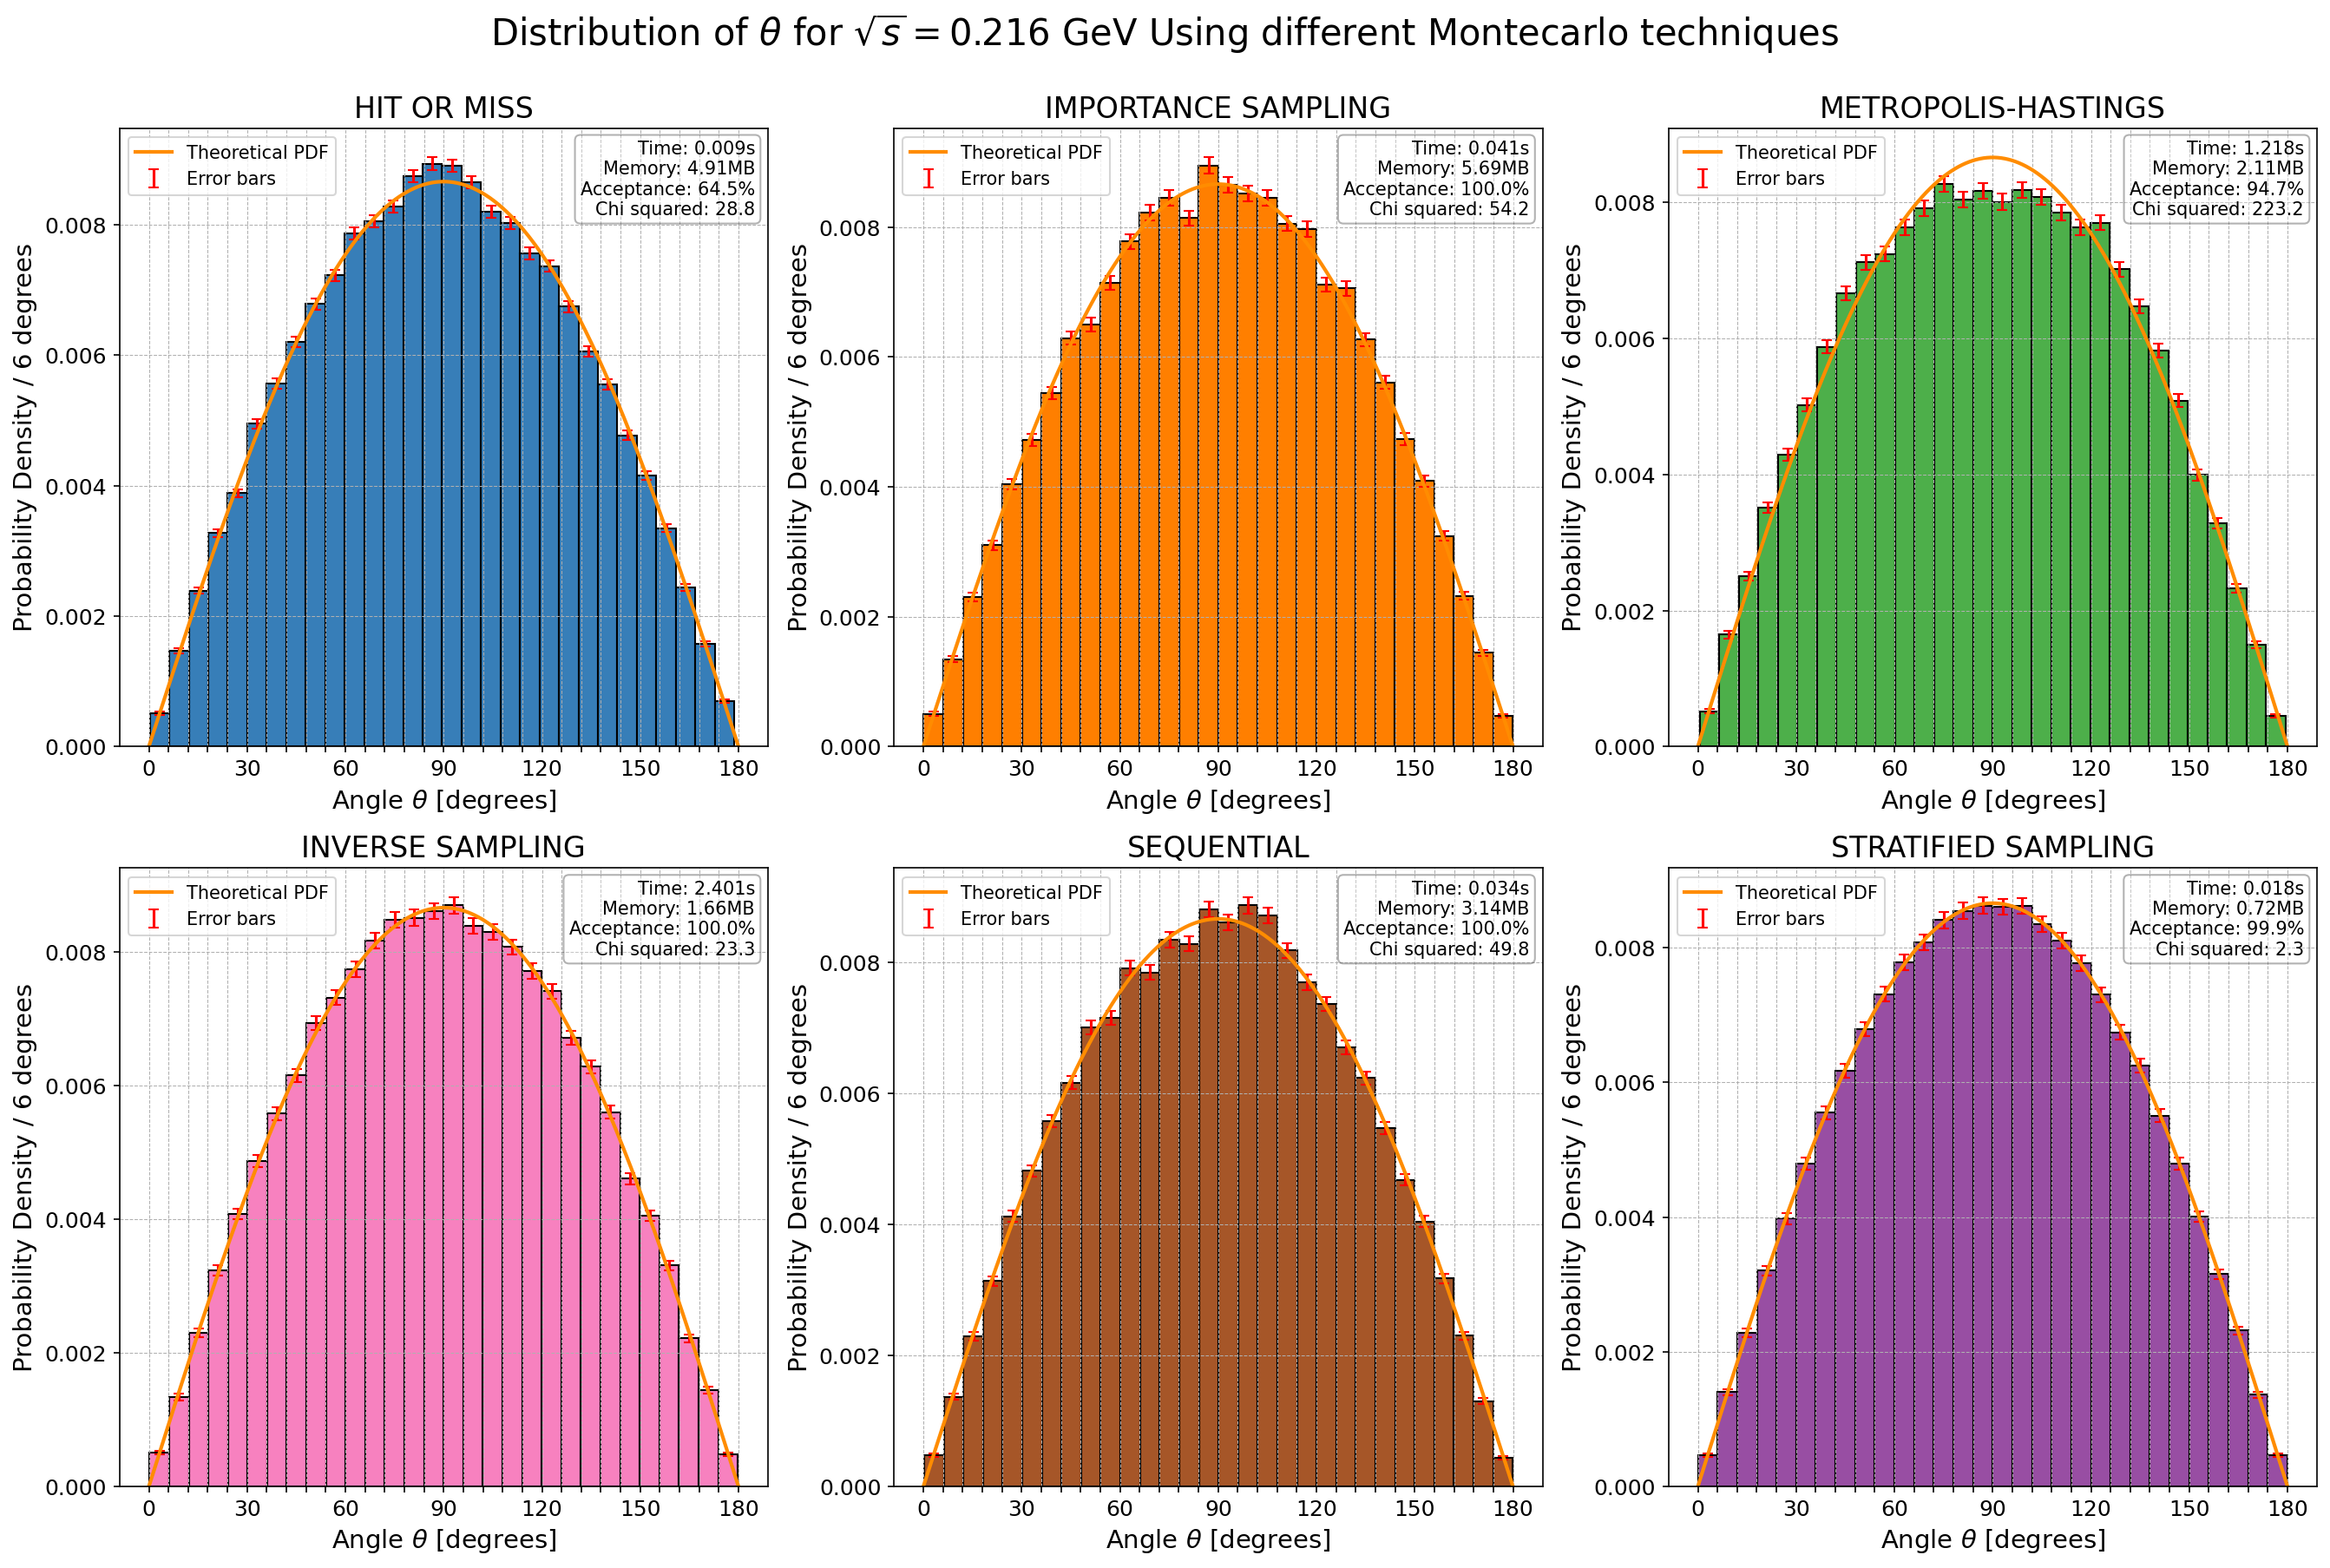

             Method Time (s) Memory (MB) Acceptance (%) Chi Squared
        HIT OR MISS     0.01        4.91          64.50       28.85
IMPORTANCE SAMPLING     0.04        5.69         100.00       54.16
METROPOLIS-HASTINGS     1.22        2.11          94.70      223.22
   INVERSE SAMPLING     2.40        1.66         100.00       23.26
         SEQUENTIAL     0.03        3.14         100.00       49.75
STRATIFIED SAMPLING     0.02        0.72          99.90        2.31


In [147]:
names = ["HIT OR MISS","IMPORTANCE SAMPLING","METROPOLIS-HASTINGS","INVERSE SAMPLING","SEQUENTIAL","STRATIFIED SAMPLING"]
methods = ["hm","imp","mh","isc","se","st"]
colors = ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3"]
times = [time_hm, time_imp, time_mh, time_is, time_se, time_st]
mem_usages = [mem_usage_hm, mem_usage_imp, mem_usage_mh, mem_usage_is, mem_usage_se, mem_usage_st]
acceptances = [accepted_hm, accepted_imp, accepted_mh, accepted_is, accepted_se, accepted_st]
chis_t = []


for method in methods:
    dataset = globals()[f"theta_samples_{method}"]
    observed_counts, bins = np.histogram(dataset, bins=30, density=False)
    bin_widths = np.diff(bins)
    expected_probs = np.array([quad(pdf_norm_wrap, bins[i], bins[i+1])[0] for i in range(len(bins)-1)])
    expected_counts = expected_probs / sum(expected_probs) * sum(observed_counts)
    chi_squared_stat_t = chisquare(f_obs=observed_counts, f_exp=expected_counts)
    chis_t.append(chi_squared_stat_t.statistic)

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
total_samples = len(dataset)

for i, (method, time, mem_usage, acceptance, chi) in enumerate(zip(methods, times, mem_usages, acceptances, chis_t)):
    dataset = globals()[f"theta_samples_{method}"]

    counts, bins = np.histogram(dataset, bins=30)
    bin_width = np.diff(bins)
    errors = np.sqrt(counts) / (total_samples * bin_width)
    
    counts, bins, patches = axs[i].hist(dataset, bins=30, density=True, color=colors[i], edgecolor="black")
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width = np.diff(bins)
    
    axs[i].errorbar(bin_centers, counts, yerr=errors, fmt="none", ecolor="r", capsize=3, label="Error bars")
    axs[i].plot(angles, pdf_norm_wrap(angles), color="darkorange", linewidth=2, label="Theoretical PDF")
    axs[i].set_title(names[i], fontsize=16)
    axs[i].set_xlabel(r"Angle $\theta$ [degrees]", fontsize=14)
    axs[i].set_ylabel("Probability Density / 6 degrees", fontsize=14)
    axs[i].legend(loc="upper left", fontsize=10)
    axs[i].grid(True, which="both", linestyle="--", linewidth=0.5)
    axs[i].set_xticks(np.arange(0, 181, 6))
    axs[i].set_xticklabels([str(degree) if degree % 30 == 0 else '' for degree in np.arange(0, 181, 6)])
    axs[i].tick_params(axis="both", which="major", labelsize=12)
    info_text = f"Time: {time}s\nMemory: {mem_usage:.2f}MB\nAcceptance: {acceptance*100:.1f}%\nChi squared: {chi:.1f}"
    axs[i].text(0.98, 0.98, info_text, transform=axs[i].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.3, boxstyle="round,pad=0.3"))

fig.suptitle(r"Distribution of $\theta$ for $\sqrt{s}=$" + str(round(E_sim, 3)) + " GeV Using different Montecarlo techniques",
             fontsize=20, y=1.0)

plt.tight_layout()
plt.show()

column_labels = ["Method", "Time (s)", "Memory (MB)", "Acceptance (%)", "Chi Squared"]
table_data = [
    [names[i], f"{times[i]:.2f}", f"{mem_usages[i]:.2f}", f"{acceptances[i] * 100:.2f}", f"{chis_t[i]:.2f}"]
    for i in range(len(names))
]

df = pd.DataFrame(table_data, columns=column_labels)
print(df.to_string(index=False))

#### Babayaga Comparison

For this comparison the goal is to analyze each distribution with the Babayaga algorithm.
BabaYaga is a Monte Carlo event generator designed for $e^+e^-$ collisions into $e^+e^-$, $\mu^+\mu^-$, $\gamma\gamma$, and $\pi^+\pi^-$ at energies below 10-12 GeV, developed by C.M. Carloni Calame, G. Montagna, O. Nicrosini, and F. Piccinini at INFN Pavia. More information can be found on its [official webpage](https://www2.pv.infn.it/~hepcomplex/babayaga.html).

The theoretical prediction for the $\theta$ distribution, as provided by the BabaYaga event generator, will be superimposed on each histogram for comparison. This will enable us to evaluate how closely the empirical distributions generated by the Monte Carlo methods match the BabaYaga prediction.

BabaYaga was run with a center of mass energy of $0.2163$ GeV, and an angle range of $0$ to $180$ degrees.

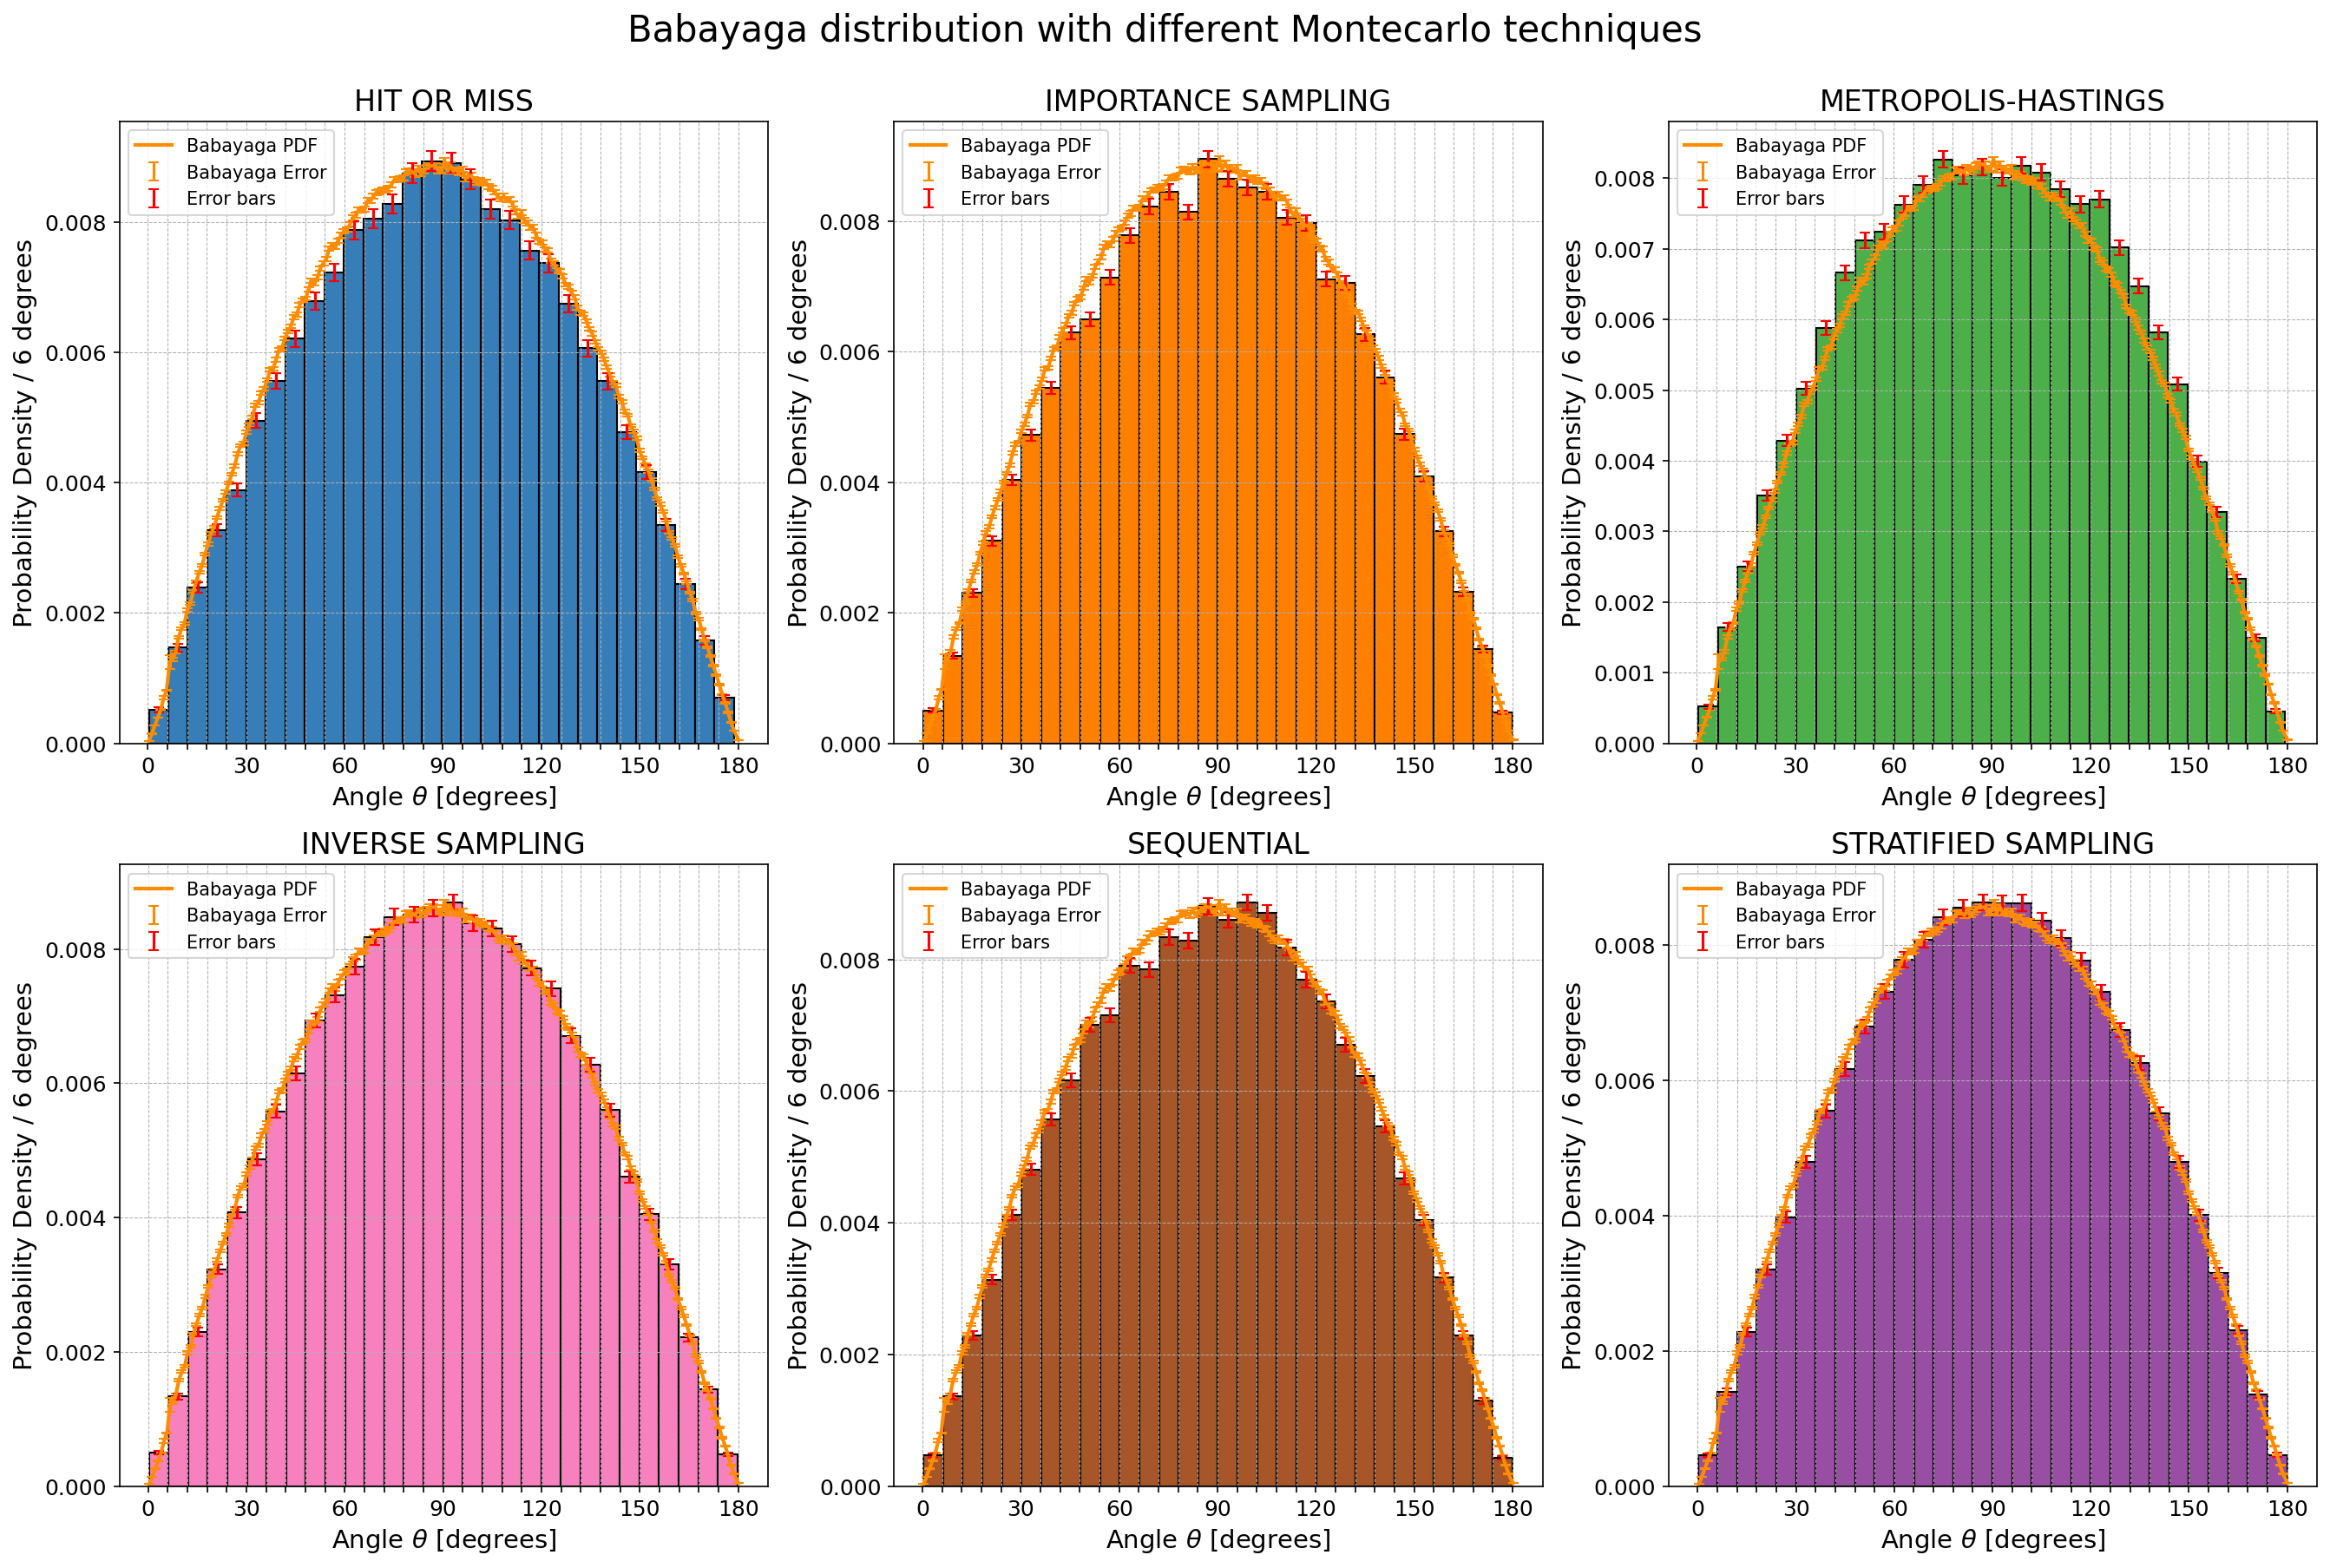

             Method Time (s) Memory (MB) Acceptance (%) Reduced Chi Squared (Babayaga)
        HIT OR MISS     0.01        4.91          64.50                          14.96
IMPORTANCE SAMPLING     0.04        5.69         100.00                          24.21
METROPOLIS-HASTINGS     1.22        2.11          94.70                          26.26
   INVERSE SAMPLING     2.40        1.66         100.00                          25.66
         SEQUENTIAL     0.03        3.14         100.00                          21.06
STRATIFIED SAMPLING     0.02        0.72          99.90                          22.16


In [150]:
Babayaga = np.loadtxt("matched_el_th_exp_200.txt").T

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
chis_b = []

fitted_parameters = 0

for i, method in enumerate(methods):
    dataset = globals()[f"theta_samples_{method}"]
    
    counts, bins, patches = axs[i].hist(dataset, bins=30, density=True, color=colors[i], edgecolor="black")

    k = np.max(Babayaga[1]) / np.max(counts)
    baba_plotted = Babayaga[1] / k
    centers = [Babayaga[0][j] + (Babayaga[0][j+1] - Babayaga[0][j]) / 2 for j in np.arange(len(Babayaga[0]) - 1)]
    centers.append(Babayaga[0][-1] + (Babayaga[0][-1] - Babayaga[0][-2]))

    baba_errors = Babayaga[2] / k
    axs[i].errorbar(centers, baba_plotted, yerr=baba_errors, fmt="none", ecolor="darkorange", capsize=3, label="Babayaga Error")
    
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width = np.diff(bins)
    total_samples = len(dataset)

    counts_err, bins_err = np.histogram(dataset, bins=30)
    errors = np.sqrt(counts_err) / (total_samples * bin_width)
    axs[i].errorbar(bin_centers, counts, yerr=errors, fmt="none", ecolor="r", capsize=3, label="Error bars")
    
    axs[i].plot(centers, baba_plotted, color="darkorange", linewidth=2, label="Babayaga PDF")
    axs[i].set_title(names[i], fontsize=16)
    axs[i].set_xlabel(r"Angle $\theta$ [degrees]", fontsize=14)
    axs[i].set_ylabel("Probability Density / 6 degrees", fontsize=14)
    axs[i].legend(loc="upper left", fontsize=10)
    axs[i].grid(True, which="both", linestyle="--", linewidth=0.5)
    axs[i].set_xticks(np.arange(0, 181, 6))
    axs[i].set_xticklabels([str(degree) if degree % 30 == 0 else '' for degree in np.arange(0, 181, 6)])
    axs[i].tick_params(axis="both", which="major", labelsize=12)

    observed_counts, _ = np.histogram(dataset, bins=bins, density=False)
    expected_counts, _ = np.histogram(Babayaga[0], bins=bins, weights=Babayaga[1], density=False)
    scaling_factor = observed_counts.sum() / expected_counts.sum()
    expected_counts *= scaling_factor
    
    chi_squared_stat_b = chisquare(f_obs=observed_counts, f_exp=expected_counts)
    
    degrees_of_freedom = len(bins) - 1 - fitted_parameters
    
    reduced_chi_squared_b = chi_squared_stat_b.statistic / degrees_of_freedom
    chis_b.append(reduced_chi_squared_b)

fig.suptitle(r"Babayaga distribution with different Montecarlo techniques", fontsize=20, y=1.0)
plt.tight_layout()
plt.show()

column_labels = ["Method", "Time (s)", "Memory (MB)", "Acceptance (%)", "Reduced Chi Squared (Babayaga)"]
table_data = [
    [names[i], f"{times[i]:.2f}", f"{mem_usages[i]:.2f}", f"{acceptances[i] * 100:.2f}", f"{chis_b[i]:.2f}"]
    for i in range(len(names))
]

df = pd.DataFrame(table_data, columns=column_labels)
print(df.to_string(index=False))

In this plot, we delve deeper into the Stratified Sampling Monte Carlo method, which has shown better performance metrics. The comparison between the generated sampling, the theoretical pdf and the Babayaga pdf is visually represented below.

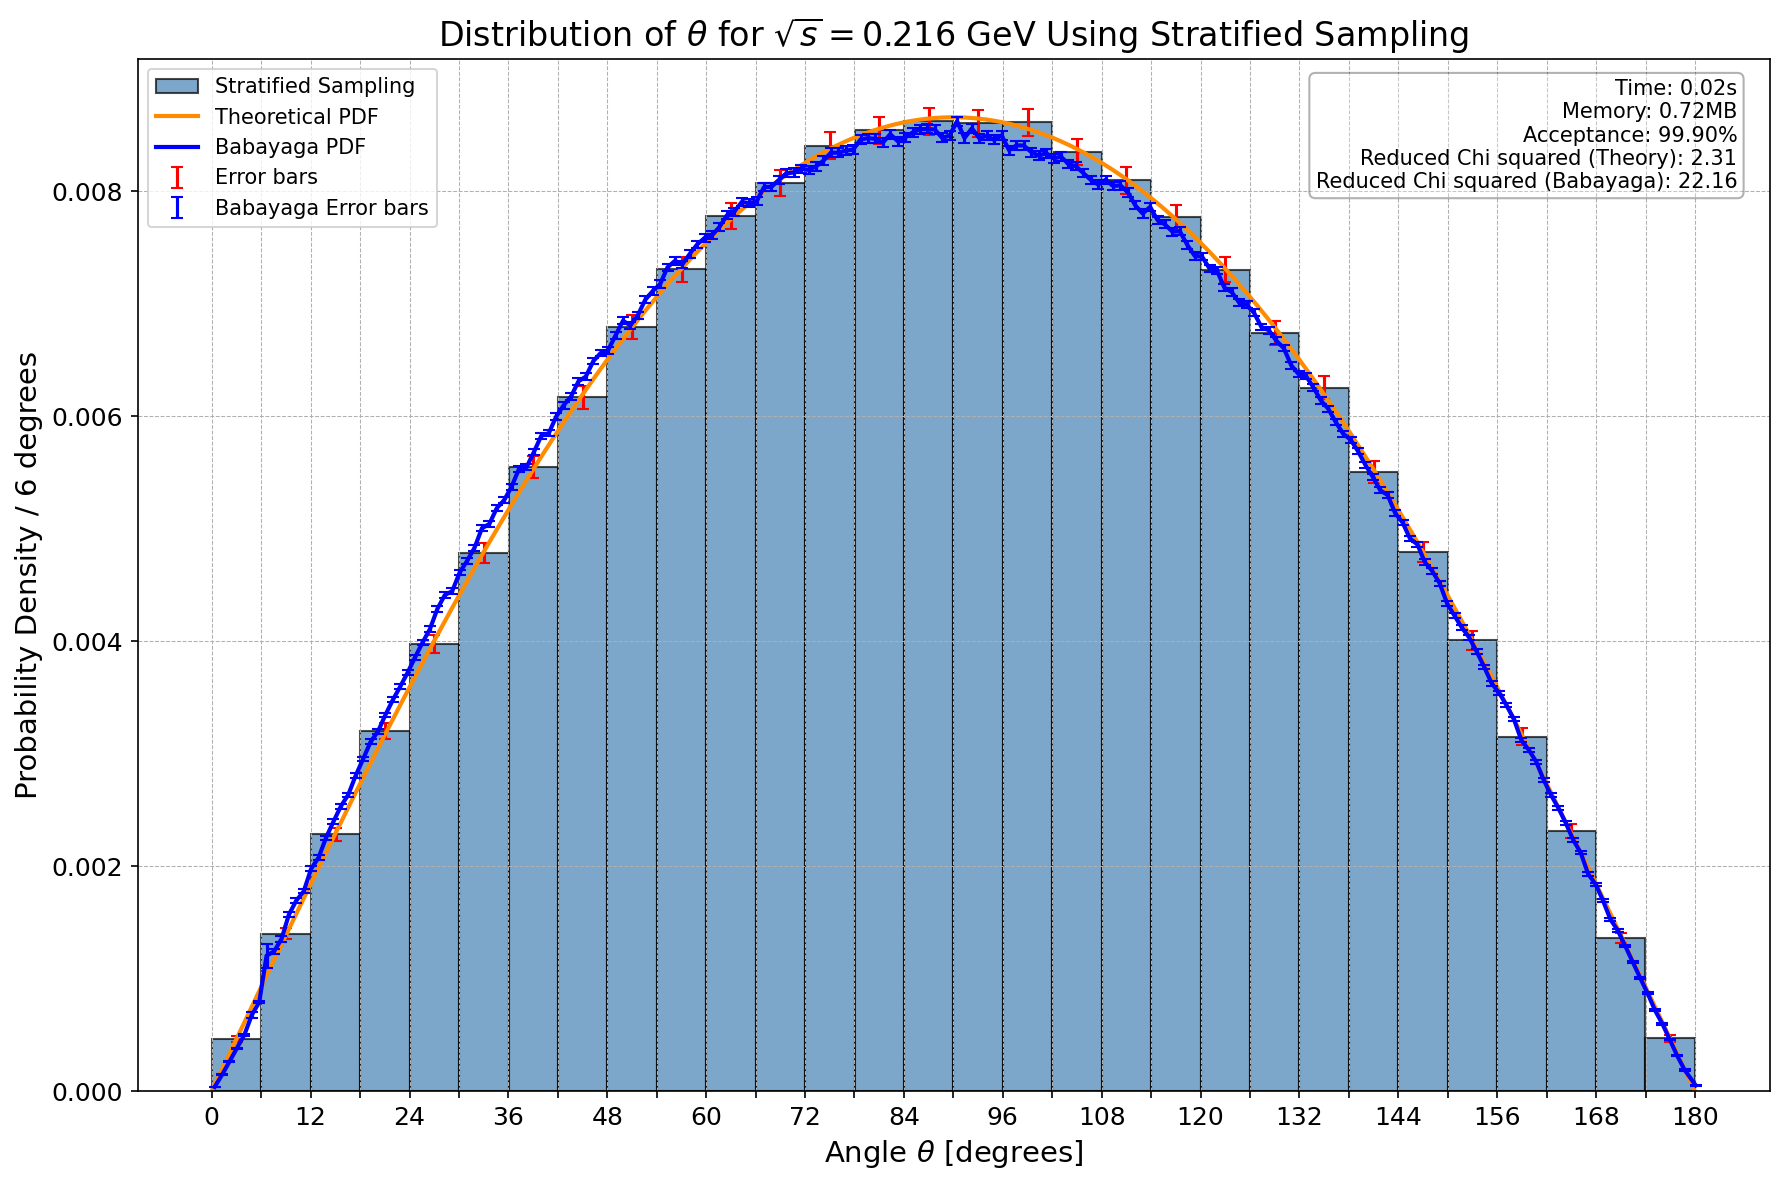

In [153]:
observed_counts, bins = np.histogram(theta_samples_st, bins=30, density=False)
bin_widths = np.diff(bins)

expected_probs = np.array([quad(pdf_norm_wrap, bins[i], bins[i+1])[0] for i in range(len(bins)-1)])
expected_counts = expected_probs / sum(expected_probs) * sum(observed_counts)
chi_squared_stat_t = chisquare(f_obs=observed_counts, f_exp=expected_counts)

degrees_of_freedom_t = len(bins) - 1
reduced_chi_squared_t = chi_squared_stat_t.statistic / degrees_of_freedom_t

expected_counts_b, _ = np.histogram(Babayaga[0], bins=bins, weights=Babayaga[1], density=False)
scaling_factor = observed_counts.sum() / expected_counts_b.sum()
expected_counts_b *= scaling_factor
chi_squared_stat_b = chisquare(f_obs=observed_counts, f_exp=expected_counts_b)

reduced_chi_squared_b = chi_squared_stat_b.statistic / degrees_of_freedom_t

fig, ax = plt.subplots(figsize=(12, 8))

counts, bins, patches = ax.hist(theta_samples_st, bins=30, density=True, color="steelblue", edgecolor='black', alpha=0.7, label='Stratified Sampling')

bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_width = np.diff(bins)
total_samples = len(theta_samples_st)

count_errs, edges_errs = np.histogram(theta_samples_st, bins=30)
errors = np.sqrt(count_errs) / (total_samples * bin_width)
ax.errorbar(bin_centers, counts, yerr=errors, fmt="none", ecolor="r", capsize=3, label="Error bars")

angles = np.linspace(0, 180, 1000)
ax.plot(angles, pdf_norm_wrap(angles), color="darkorange", linewidth=2, label="Theoretical PDF")

k = (np.max(Babayaga[1])) / np.max(counts)
baba_plotted = Babayaga[1] / k
centers = [Babayaga[0][i] + (Babayaga[0][i+1] - Babayaga[0][i]) / 2 for i in np.arange(0, len(Babayaga[0]) - 1)]
centers.append(Babayaga[0][-1] + (Babayaga[0][-1] - Babayaga[0][-2]))
ax.plot(centers, baba_plotted, color="blue", linewidth=2, label="Babayaga PDF")

ax.errorbar(centers, baba_plotted, yerr=Babayaga[2] / k, fmt="none", ecolor="blue", capsize=3, label="Babayaga Error bars")

ax.set_title(r"Distribution of $\theta$ for $\sqrt{s}=$" + str(round(E_sim, 3)) + " GeV Using Stratified Sampling", fontsize=16)
ax.set_xlabel(r"Angle $\theta$ [degrees]", fontsize=14)
ax.set_ylabel("Probability Density / 6 degrees", fontsize=14)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
degrees_x = np.arange(0, 181, 6)
ax.set_xticks(degrees_x)
ax.set_xticklabels([str(degree) if degree % 12 == 0 else '' for degree in degrees_x])
ax.tick_params(axis="both", which="major", labelsize=12)

info_text = (f"Time: {time_st:.2f}s\n"
             f"Memory: {mem_usage_st:.2f}MB\n"
             f"Acceptance: {accepted_st * 100:.2f}%\n"
             f"Reduced Chi squared (Theory): {chi_squared_stat_t.statistic:.2f}\n"
             f"Reduced Chi squared (Babayaga): {reduced_chi_squared_b:.2f}")
ax.text(0.98, 0.98, info_text, transform=ax.transAxes, fontsize=10, verticalalignment="top", horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.3, boxstyle="round,pad=0.3"))

plt.tight_layout()
plt.show()


### Point 5
### Synthetic Dataset

Produce a synthetic dataset of about $N=10^5$ (or more) events. Events should be listed as rows in a file with columns representing the muons coordinates (keep in mind that in the lab frame muons are relativistic and thus the number of coordinates can be only 3 per muon).

   CoM_AntiMuon_px  CoM_AntiMuon_py  CoM_AntiMuon_pz  CoM_Muon_px  \
0         0.000019        -0.000011         0.023120    -0.000019   
1         0.000031         0.000206         0.023119    -0.000031   
2         0.000094         0.000252         0.023119    -0.000094   
3        -0.000094         0.000028         0.023120     0.000094   
4        -0.000002        -0.000010         0.023120     0.000002   

   CoM_Muon_py  CoM_Muon_pz  
0     0.000011    -0.023120  
1    -0.000206    -0.023119  
2    -0.000252    -0.023119  
3    -0.000028    -0.023120  
4     0.000010    -0.023120  


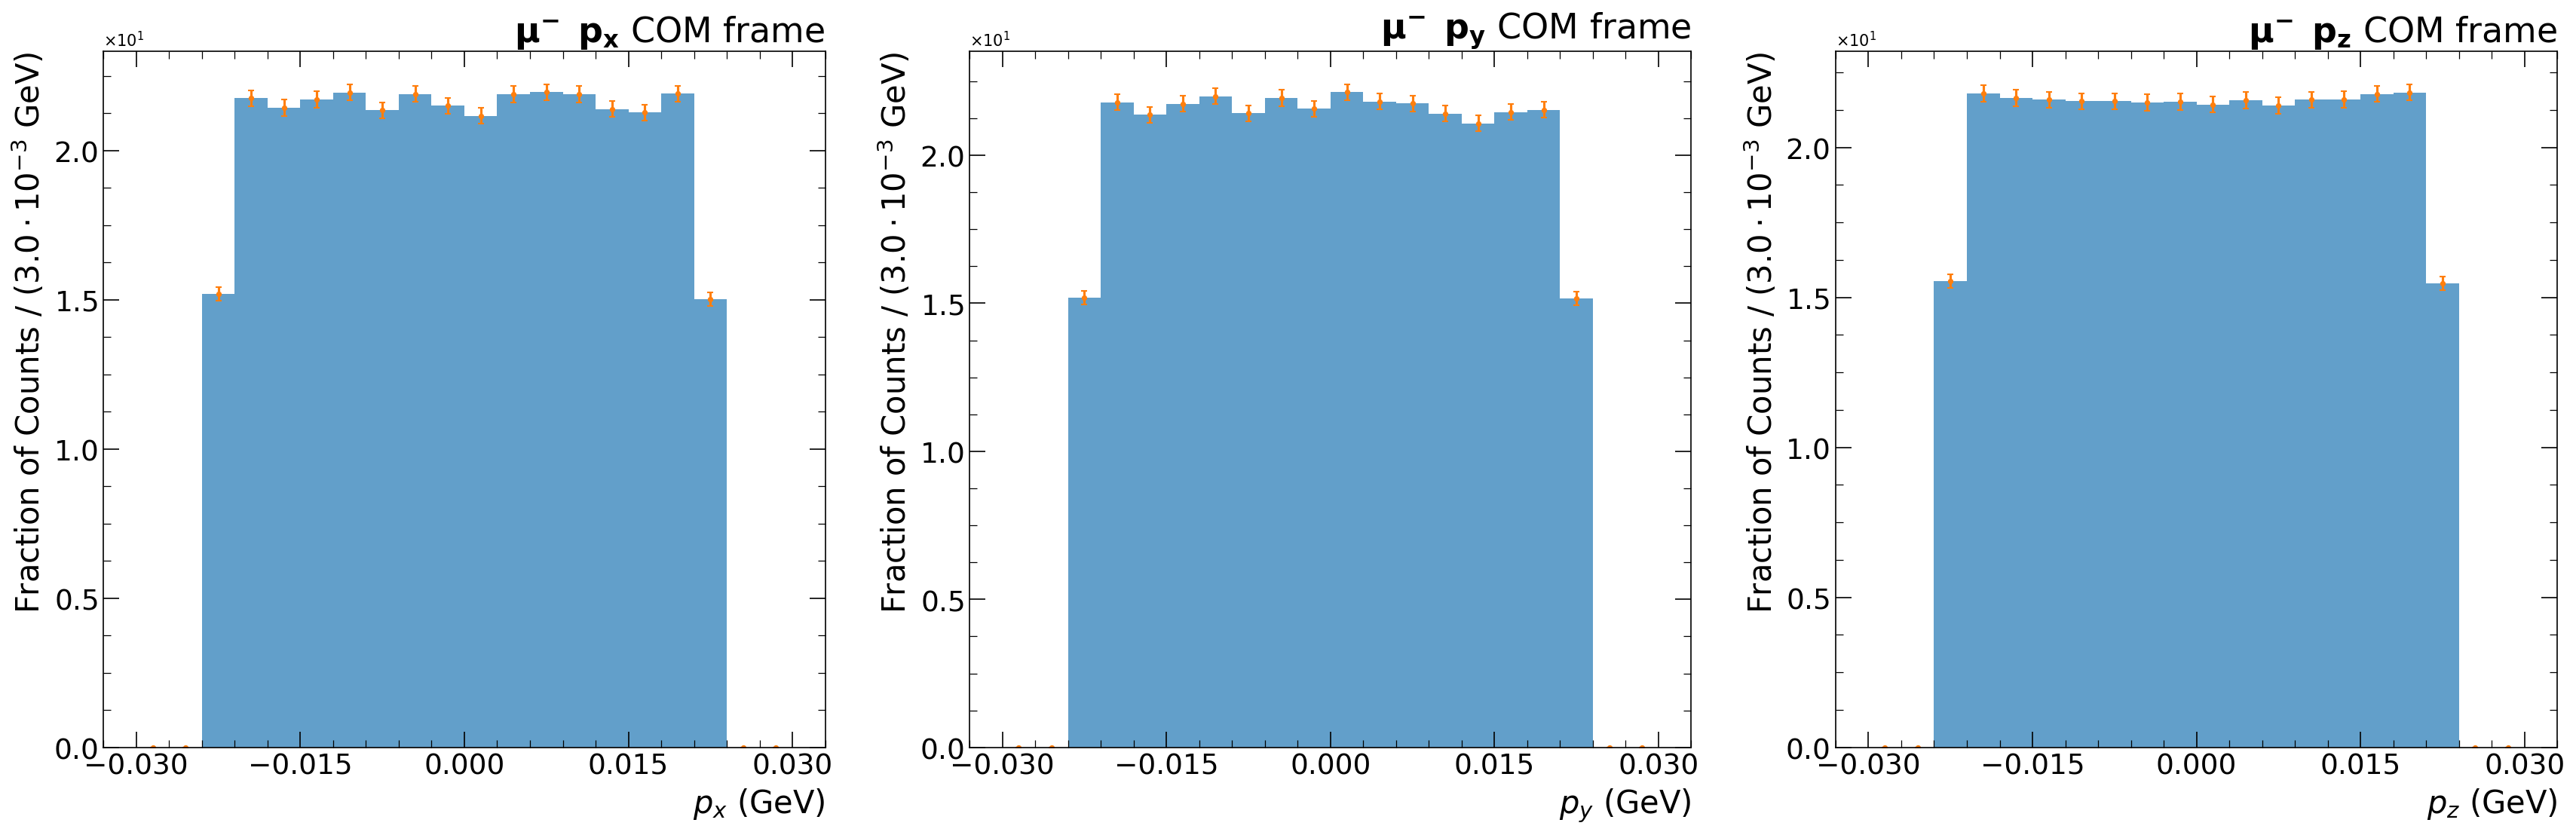

In [20]:
%precision 6

N_samples = len(theta_samples_st)
phi = 360 * np.random.rand(N_samples)
momentum_mu = np.sqrt(E_sim**2 / 4 - mu_mass**2)

sin_theta = np.sin(np.radians(theta_samples_st))
cos_theta = np.cos(np.radians(theta_samples_st))
sin_phi = np.sin(np.radians(phi))
cos_phi = np.cos(np.radians(phi))

momenta = pd.DataFrame({
    "CoM_AntiMuon_px": momentum_mu * cos_phi * sin_theta,
    "CoM_AntiMuon_py": momentum_mu * sin_phi * sin_theta,
    "CoM_AntiMuon_pz": momentum_mu * cos_theta,
})

momenta[["CoM_Muon_px", "CoM_Muon_py", "CoM_Muon_pz"]] = -momenta[["CoM_AntiMuon_px", "CoM_AntiMuon_py", "CoM_AntiMuon_pz"]]
momenta.to_csv("Momenta_CoM.csv", index=False, index_label=False)

components = ["CoM_Muon_px", "CoM_Muon_py", "CoM_Muon_pz"]

fig, axs = plt.subplots(1, 3, figsize=(28, 8))
pl.MuonPlotsCOMPads(axs, momenta,
                 n_maj_loc=5,
                 n_min_loc=5,
                 plot_features=components,
                 alpha=0.7,
                 title_size=22,
                 ylabel_size=20,
                 xlabel_size=20,
                 ticksize_major=18,
                 ticksize_minor=12,
                 legend_size=10,
                 histtype=None,
                 legend=False,
                 plotlabel="Momentum",
                 errlabel="Momentum Error")

print(momenta.head())

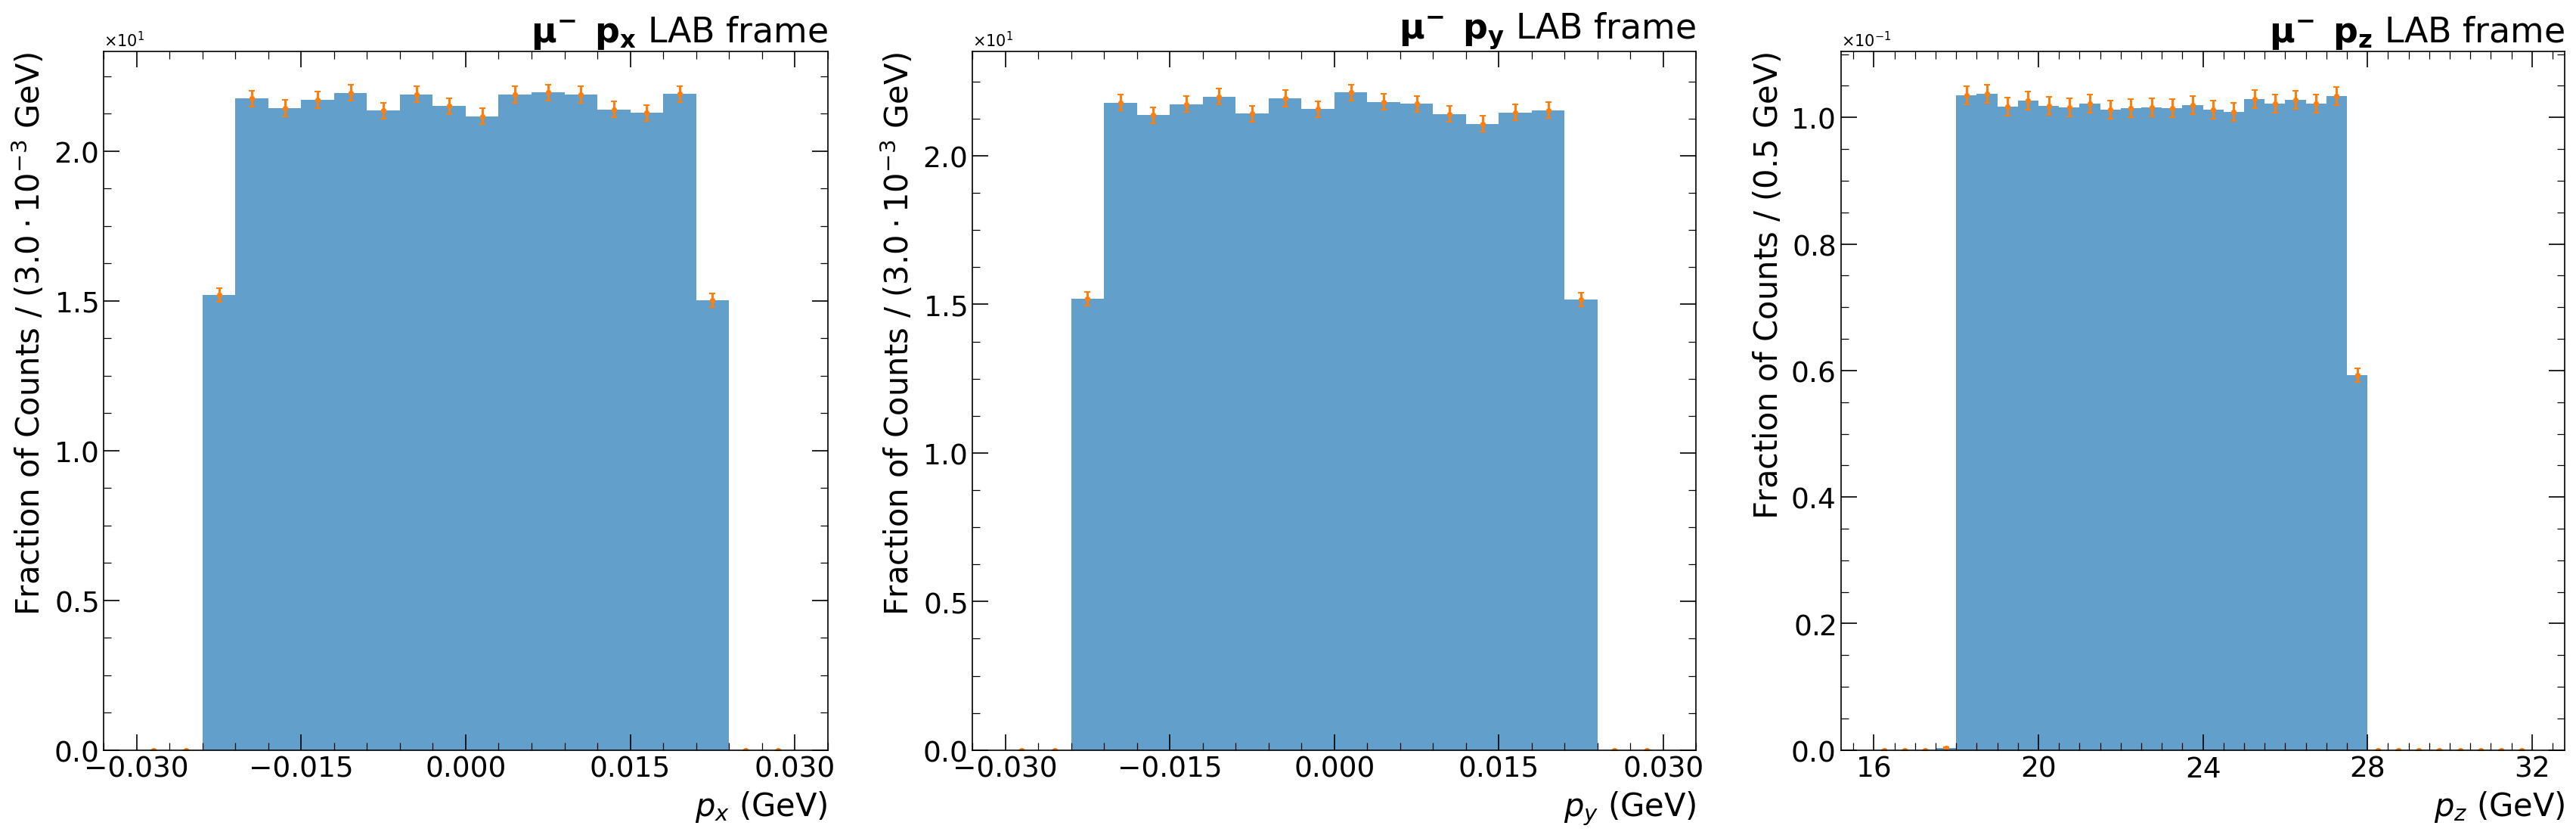

   CoM_AntiMuon_px  CoM_AntiMuon_py  CoM_AntiMuon_pz  CoM_Muon_px  \
0         0.000019        -0.000011         0.023120    -0.000019   
1         0.000031         0.000206         0.023119    -0.000031   
2         0.000094         0.000252         0.023119    -0.000094   
3        -0.000094         0.000028         0.023120     0.000094   
4        -0.000002        -0.000010         0.023120     0.000002   

   CoM_Muon_py  CoM_Muon_pz  LAB_Muon_E  LAB_Muon_px  LAB_Muon_py  LAB_Muon_pz  
0     0.000011    -0.023120   17.999301    -0.000019     0.000011    17.998991  
1    -0.000206    -0.023119   17.999497    -0.000031    -0.000206    17.999186  
2    -0.000252    -0.023119   17.999631    -0.000094    -0.000252    17.999321  
3    -0.000028    -0.023120   17.999343     0.000094    -0.000028    17.999033  
4     0.000010    -0.023120   17.999299     0.000002     0.000010    17.998989  


In [21]:
boosted_momenta = momenta.apply(lambda row: lorentz_boost(E_sim / 2, row["CoM_Muon_px"], row["CoM_Muon_py"], row["CoM_Muon_pz"], gamma), axis=1)

momenta[["LAB_Muon_E", "LAB_Muon_px", "LAB_Muon_py", "LAB_Muon_pz"]] = pd.DataFrame(boosted_momenta.tolist(), index=momenta.index).iloc[:, :4]

components = ["LAB_Muon_px", "LAB_Muon_py", "LAB_Muon_pz"]
fig, axs = plt.subplots(1, 3, figsize=(28, 8))
pl.MuonPlotsLABPads(axs,
                    momenta, 
                    plot_features=components, 
                    alpha=0.7, 
                    title_size=22, 
                    ylabel_size=20, 
                    xlabel_size=20, 
                    ticksize_major=18, 
                    ticksize_minor=12, 
                    legend_size=10, 
                    histtype=None, 
                    legend=False, 
                    plotlabel="Momentum", 
                    errlabel="Momentum Error")
plt.show()

print(momenta.head())

### Point 6

### Beryllium target and Rescaling factor
Given $N$ generated events, we can calculate the correct statistics for this experiment lasting one week just by applying to the simulated events a rescaling factor. The target is a 3cm thick Beryllium block[8,9] and it is bombarded by a positrons arriving at a rate of $10^6$ Hz.

<div align="center"><img src="./img/block.png" width=600></div>

The number of $(\mu^+ \mu^-)$ pairs produced per positron bunch on target is:

$$N(\mu^+\mu^-) = \sigma(e^+e^- \longrightarrow \mu^+\mu^-)N(e^+)\rho(e^-)D,$$

where $N(e^+)$ is the number of positrons, $\rho(e^-)$ is target electron density and $D$ is the thickness of the Beryllium block.

$$\rho(e^-) = \frac{\rho_{Be}{N_A}}{M_{Be}},$$

where $N_A  $ is Avogadro's number, $M_{Be}$ is molar mass of Beryllium and $\rho_{Be}$ is density of Beryllium.

$$N(e^+) = \omega_{e^+}T$$

where $\omega_{e^+}$  is rate of positron and T is time of the experiment.

In [22]:
N_A = 6.02214076e23 # [1/mol] avogadro constant
dens= 1.848 # [g/cm^3] density of Beryllium
m = 9.012182 # [g/mol] molar mass Beryllium
l = 3 # [cm] thickness of Beryllium block
e=4 #number of electron of Beryllium
rate = 1e6 # [1/s] rate of positron
t=604800 # time of the experiment (seconds in a week)

N_p=rate*t #number of positrons
N= cross_section(s=E_sim**2)*1e-33*rate*t*e*(dens*N_A/m*l) # number of created muons

rescaling_factor = N/N_p

print(" Number of positrons : ","{:.2E}".format(N_p))
print(r' Number of created muons in one week operation at E = ',"{:.3f}".format(E_sim),"GeV"," : ","{:.2E}".format(N))
print(" Rescaling factor: ","{:.2E}".format(rescaling_factor))

 Number of positrons :  6.05E+11
 Number of created muons in one week operation at E =  0.216 GeV  :  5.26E+05
 Rescaling factor:  8.69E-07


In [23]:
# setting some variables for later points
E_star = E_sim/2
electron_mass = e_mass
m_mu = mu_mass
N_simulated = 2*10**5
# importing some libs
from lcpalib import lorentz as LB
from lcpalib import beam as Beam
import lcpalib.sampling as smp
from lcpalib import cross_sections as cross_secs
cs = cross_secs.CS()

### Point 7
### Gaussian beam

In the following, the beam will cease to be monochromatic and pointlike. The energy is sampled from a gaussian distribution centered at nominal energy and width of $0.5$ GeV, while the transverse shape will be a circle of radius $1 cm$. We assume beam propagation along the $z$ axis, hence the transverse shape of the beam[10] is the shape the beam has on the x-y plane.

In [24]:
# Computing the nominal energy of the beam in the LAB frame
# In the center of mass this is just the E_star defined above.
# Boosting the nominal energy to the LAB frame
p_cm = np.sqrt((E_star**2) - electron_mass**2)
# Nominal energy of the positron beam in the Lab frame (where the electron is at rest)
E_lab = LB.boost2LAB(p_cm, E_star)['E']

In [25]:
# getting the 'Energies' dataframe that will contain the generated positrons
Energies = None

# sigma of the shape, in GeV
beam_s = 0.5

# Checking the mode
if MODE==ps.kEDIT:
    # Sample from normal distribution for the energy @ nominal E_lab and sigma = beam_s
    E_lab_sample=np.random.normal(E_lab, beam_s, N_simulated)
    p_lab_sample=np.sqrt(E_lab_sample**2 - electron_mass**2)

    # Now to boost back in the CoM all of the generated particles.
    # Since each particle will now have a different energy, given the fact that the beam is no more
    # monochromatic, each particle will have its beta and gamma
    positron_boosts_toCoM = LB.boost2CoM(p_lab_sample, E_lab_sample)

    # Saving a dataframe
    Energies = pd.DataFrame({
        'E_CoM_positron': positron_boosts_toCoM['E*'],
        'pz_CoM_positron': positron_boosts_toCoM['pz*'],
        'E_LAB_positron': E_lab_sample,
        'pz_LAB_positron': p_lab_sample
    })

    # Saving the dataframe to disk
    Energies.to_pickle(ps.kEnergies_DataFrame_pkl)
else:
    # Loading the data from disk
    Energies = pd.read_pickle(ps.kEnergies_DataFrame_pkl)

# printing out
print("Nominal energy value for incoming positron beam (CoM): ","{:.3f}".format(E_star), "GeV")
print("Nominal energy value for incoming positron beam (Lab): ", "{:.3f}".format(E_lab), "GeV")
print(Energies)

Nominal energy value for incoming positron beam (CoM):  0.108 GeV
Nominal energy value for incoming positron beam (Lab):  45.785 GeV
        E_CoM_positron  pz_CoM_positron  E_LAB_positron  pz_LAB_positron
0             0.108391         0.108390       45.982686        45.982686
1             0.107640         0.107639       45.347717        45.347717
2             0.106775         0.106773       44.621226        44.621226
3             0.108415         0.108413       46.002490        46.002490
4             0.106865         0.106864       44.696530        44.696530
...                ...              ...             ...              ...
199995        0.107612         0.107610       45.323417        45.323417
199996        0.108455         0.108453       46.036437        46.036437
199997        0.107526         0.107525       45.251243        45.251243
199998        0.107795         0.107794       45.478136        45.478136
199999        0.108299         0.108298       45.904565        4

The beam is shown, in the transverse plane, as a two dimensional histogram below.

200000


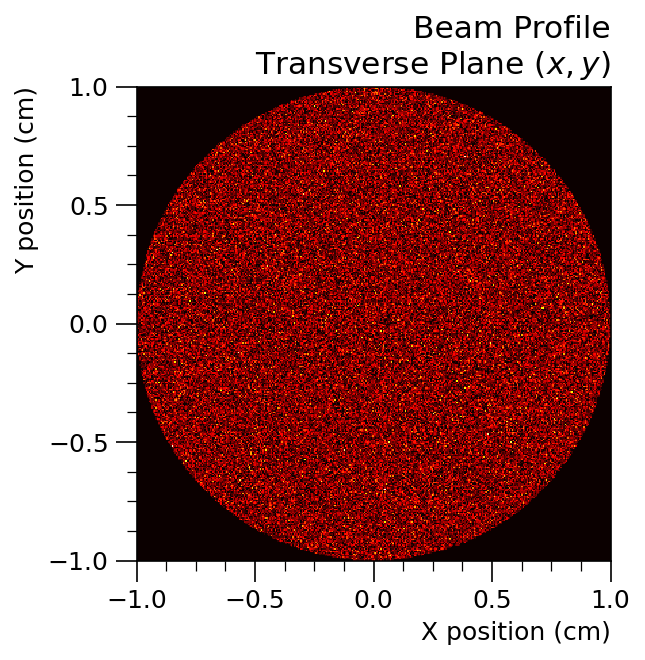

In [134]:
# Beam Shape
scaledEnergies = np.interp(Energies['E_LAB_positron'], [Energies['E_LAB_positron'].min(), Energies['E_LAB_positron'].max()], [0,1])

# Building the beam
beam_geometry = Beam.BeamGeometry()
beam_geometry.generate_positions(N_simulated, Energies['E_LAB_positron'])
coords = beam_geometry.get()

# showing the beam
fig,ax = plt.subplots(figsize=(4.5,4.5))
ax.hist2d(coords[:,0].flatten(), coords[:,1].flatten(), weights=scaledEnergies, bins=(350,350), cmap='hot', range=((-1,1),(-1,1)))

ax.set_xlim(-1,1)
ax.set_ylim(-1,1)

minor_locator_x = AutoMinorLocator(4)
minor_locator_y = AutoMinorLocator(4)
major_locator_x = ticker.MaxNLocator(4)
major_locator_y = ticker.MaxNLocator(4)

ax.xaxis.set_minor_locator(minor_locator_x)
ax.yaxis.set_minor_locator(minor_locator_y)
ax.xaxis.set_major_locator(major_locator_x)
ax.yaxis.set_major_locator(major_locator_y)

ax.set_aspect('equal')

ax.ticklabel_format(axis='y', style='scientific', useMathText=True, scilimits=(0.,1))
ax.tick_params(axis='both', which='major', labelsize=12, length=10, direction='out', top=False, right=False)
ax.tick_params(axis='both', which='minor', labelsize=8, length=5, direction='out', top=False, right=False)

ax.set_xlabel('X position (cm)',fontsize=12, loc='right')
ax.set_ylabel('Y position (cm)',fontsize=12, loc='top')
ax.set_title('Beam Profile\nTransverse Plane $(x,y)$',fontsize=15,loc='right')

fig.tight_layout()

To each two-dimensional bin of the histogram is applied a weight which represents the beam energy as sampled from the gaussian distribution. The same plot is obtained via a simple FLUKA[11] simulation where a positron source was simulated with the same parameters of this exercise and the data scored in a USRBIN card.

The figure is shown here below:

<div align="center"><img src="img/beam_shape.png" width=600></div>


The beam energy both in the LAB frame and in the COM frame is shown below in two plots.

In [28]:
# Getting the "sqrt(s)/2" in the center of mass
sqrt_s_sampled = Energies['E_CoM_positron']

# Setting some histogram parameters
low_bound_com = 0.105
upper_bound_com = 0.111
nbins_com = 48
binsize_com = (upper_bound_com-low_bound_com)/nbins_com

# y label
h_ylabel_com = " Fraction of Counts / $("+str(round(binsize_com*10**3,3))+"\cdot10^{-3}\hspace{0.5}GeV$)"

# threshold for production in the CoM frame
E_com_thr = m_mu

In [29]:
# Laboratory frame
elab_sampled = Energies['E_LAB_positron']

# Histogram parameters
low_bound_lab = 43
upper_bound_lab = 49
nbins_lab = 48
binsize_lab = (upper_bound_lab-low_bound_lab)/nbins_lab

# y label for hist
h_ylabel_lab = "Fraction of Counts / $("+str(round(binsize_lab,3))+"\hspace{0.5}GeV$)"

# threshold for production in the LAB frame
p_cm_min = np.sqrt(m_mu**2 - electron_mass**2)
E_star_min = m_mu
E_lab_thr = LB.boost2LAB(p_cm_min, E_star_min)['E']

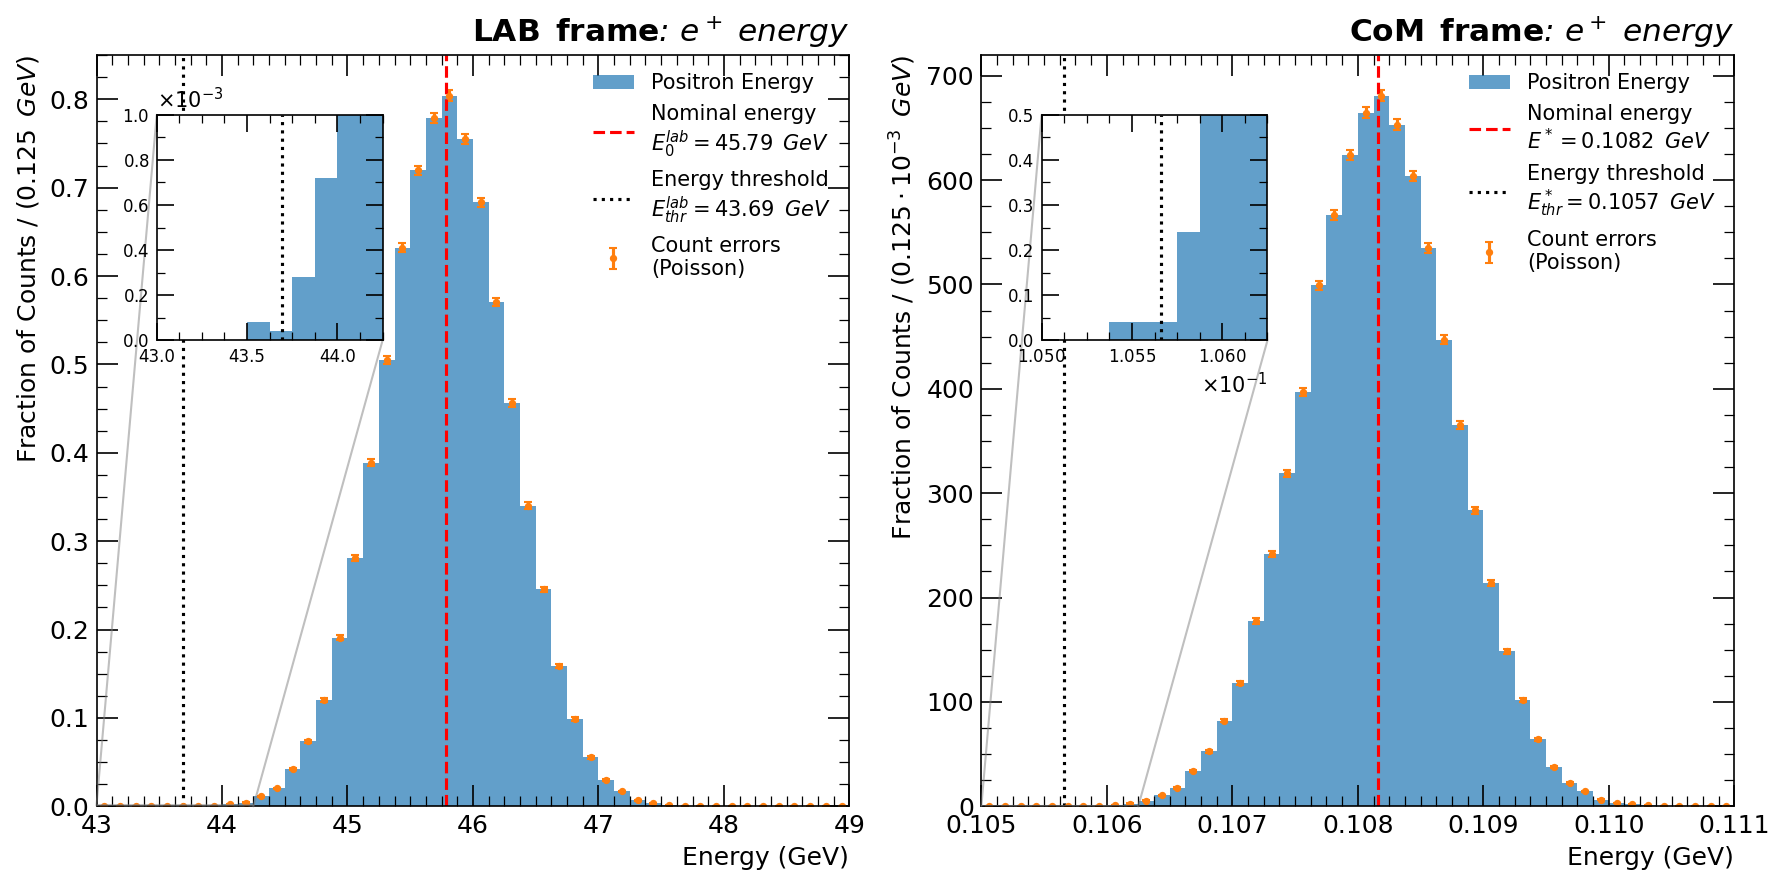

In [30]:
fig = plt.figure(figsize=(12,6))
ax = plt.subplot2grid(shape=(1,2), loc=(0,0), colspan=1, rowspan=1, fig=fig)

# plotting the Laboratory
pl.EnergyPlotPad(elab_sampled, nbins_lab, (low_bound_lab, upper_bound_lab), ax,
                    zoomin_limits=(0,0.001),
                    zoomin_xlims=(43, 44.25),
                    zoomin_ylims=(0,0.001),
                    E_thr=E_lab_thr,
                    E_peak=E_lab,
                    x_or_y_sci='y',
                    plotlabel="Positron Energy",
                    plotlabel_err="Count errors\n(Poisson)",
                    figtitle=r"$\bf{LAB\hspace{0.5}frame}$: $e^+$ energy",
                    threnergy_label="Energy threshold\n$E^{lab}_{thr} = "+str(round(E_lab_thr,2))+"\hspace{0.5}GeV$",
                    nomenergy_label="Nominal energy\n$E^{lab}_0 = "+str(round(E_lab,2))+"\hspace{0.5}GeV$",
                    xlabel="Energy (GeV)",
                    ylabel=h_ylabel_lab,
                    title_loc='right'
                   )

# plotting the CoM
ax1 = plt.subplot2grid(shape=(1,2), loc=(0,1), colspan=1, rowspan=1, fig=fig)
pl.EnergyPlotPad(sqrt_s_sampled, nbins_com, (low_bound_com, upper_bound_com), ax1,
                    zoomin_limits=(0.105,0.10625),
                    zoomin_xlims=(0.105,0.10625),
                    zoomin_ylims=(0,0.5),
                    E_thr=E_com_thr,
                    E_peak=E_star,
                    x_or_y_sci='x',
                    plotlabel="Positron Energy",
                    plotlabel_err="Count errors\n(Poisson)",
                    figtitle=r"$\bf{CoM\hspace{0.5}frame}$: $e^+$ energy",
                    threnergy_label="Energy threshold\n$E^*_{thr} = "+str(round(E_com_thr,4))+"\hspace{0.5}GeV$",
                    nomenergy_label="Nominal energy\n$E^* = "+str(round(E_star,4))+"\hspace{0.5}GeV$",
                    xlabel="Energy (GeV)",
                    ylabel=h_ylabel_com,
                    title_loc='right'
                   )
fig.tight_layout()

As the zoomed-in regions of the plots show, some events could lie below the energy threshold so they are not compatible with muon pairs production. These events will thus be discarded.

In [31]:
# Applying a rectangular cut to select only compatible energies with production
EnergiesOk = Energies[Energies['E_CoM_positron']>m_mu].reset_index()
EnergiesOk.to_pickle(ps.kEnergies_DataFrame_pkl)    
N_thr = EnergiesOk.shape[0]
print("There are",N_thr,"events above threshold out of",Energies.shape[0])

There are 199998 events above threshold out of 200000


Now, having the compatible energies we can inverse sample the diffusion angle's probability distribution in order to generate angles in the center of mass frame.

In [32]:
# sampling now only the "over the threshold" N events, each one with its energy since now the beam is no longer
# monochromatic. We now need the total energy in the CoM, so the sqrt_s
E_sqrt_s = 2*EnergiesOk['E_CoM_positron']

# getting thetas and phis
thetas = None
phis = None

if MODE==ps.kEDIT:
    # inverse-sampling the distribution
    ISAMPLER = smp.InverseSampler(N_thr, cs.cdf_theta, np.arccos)
    ISAMPLER.runDifferentE(E_sqrt_s)
    thetas = ISAMPLER.getTransformedSamples()
    phis = np.random.random(N_thr)*2*np.pi
    # saving npy
    np.save(ps.kSampledThetas_npy, thetas)
    np.save(ps.kSampledPhis_npy, phis)
else:
    # reading previously defined
    thetas = np.load(ps.kSampledThetas_npy)
    phis = np.load(ps.kSampledPhis_npy)

The resulting distribution is shown below together with the theoretical curves. Since the beam is now longer monochromatic, we have a curve for each value of the center-of-mass energy. These curves lie within an interval that is bounded by the two curves corresponding to the minimum and maximum center-of-mass energy values, respectively.

In [33]:
Babayaga = Babayaga.T

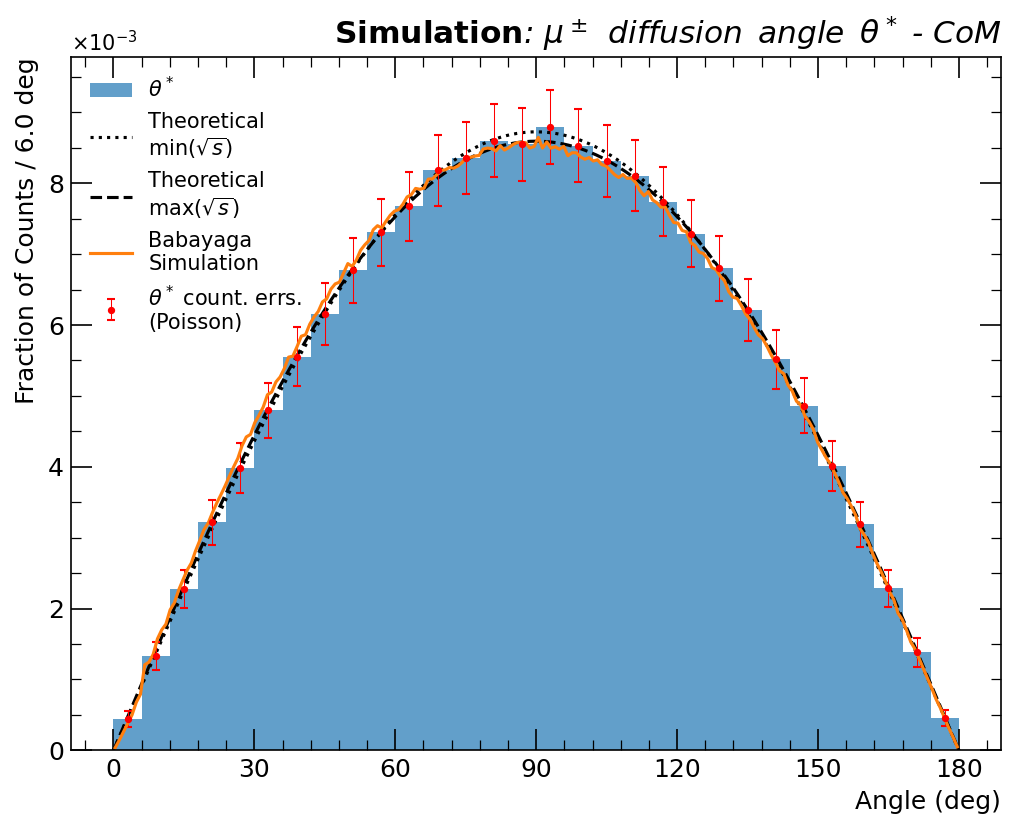

In [34]:
thetas_deg = thetas*180/np.pi
fig, ax = plt.subplots(figsize=(8,6))
pl.AnglePlotPad(thetas_deg, EnergiesOk['E_CoM_positron'], cs.pdf_theta, ax,
                   angledist_label="$\\theta^*$",
                   figtitle=r"$\bf{Simulation}$: "+"$\mu^\pm\hspace{0.5}diffusion\hspace{0.5}angle\hspace{0.5}{\\theta}^*$ - CoM",
                   minloc_x=5,
                   nbins=30,
                   err_label='$\\theta^*$ count. errs.\n(Poisson)'
                  )
# adding babayaga
baba_binsize = Babayaga[1,0]-Babayaga[0,0]
baba_centered = Babayaga[:,0] + (baba_binsize/2.)
baba_norm = Babayaga[:,1]/(baba_binsize*np.sum(Babayaga[:,1]))
plt.plot(baba_centered, baba_norm, label='Babayaga\nSimulation')
ax.legend(loc=2, fontsize=10, frameon=False)

The dataframe containing the simulated data is now expanded with the data regarding the generated Muon-AntiMuon pairs.

In [35]:
# getting the Muon-Antimuon energies and absolute value of the momenta in the CoM
E_thr = 2*EnergiesOk["E_CoM_positron"]

In [36]:
if MODE==ps.kEDIT:
    # Absolute value of p-vector in the center of mass
    EnergiesOk["absP_MuMu_CoM"] = np.sqrt((EnergiesOk["E_CoM_positron"])**2 - m_mu**2)

    # Momenta in the CoM
    EnergiesOk["CoM_AntiMuon_px"] = EnergiesOk["absP_MuMu_CoM"]*np.cos(phis)*np.sin(thetas)
    EnergiesOk["CoM_AntiMuon_py"] = EnergiesOk["absP_MuMu_CoM"]*np.sin(phis)*np.sin(thetas)
    EnergiesOk["CoM_AntiMuon_pz"] = EnergiesOk["absP_MuMu_CoM"]*np.cos(thetas)
    EnergiesOk["CoM_Muon_px"] = -EnergiesOk["CoM_AntiMuon_px"]
    EnergiesOk["CoM_Muon_py"] = -EnergiesOk["CoM_AntiMuon_py"]
    EnergiesOk["CoM_Muon_pz"] = -EnergiesOk["CoM_AntiMuon_pz"]

    # Preparing to boost to the Lab
    #b2L = LB.LorentzBoost(m_mu, E_positron_cm=EnergiesOk["E_CoM_positron"])

    # Boosting AntiMuons to the Lab
    #pB,EB = b2L.boost2LAB(EnergiesOk['CoM_AntiMuon_pz'], EnergiesOk["E_CoM_positron"])
    b2L = LB.boost2LAB(EnergiesOk['CoM_AntiMuon_pz'], EnergiesOk["E_CoM_positron"])
    pB,EB = b2L['pz'], b2L['E']
    EnergiesOk['LAB_AntiMuon_px'] = EnergiesOk['CoM_AntiMuon_px']
    EnergiesOk['LAB_AntiMuon_py'] = EnergiesOk['CoM_AntiMuon_py']
    EnergiesOk['LAB_AntiMuon_pz'] = pB

    # Boosting Muons to the Lab
    #pB, EB = b2L.boost2LAB(EnergiesOk['CoM_Muon_pz'], EnergiesOk["E_CoM_positron"])
    b2L = LB.boost2LAB(EnergiesOk['CoM_Muon_pz'], EnergiesOk["E_CoM_positron"])
    pB,EB = b2L['pz'], b2L['E']
    EnergiesOk['LAB_Muon_px'] = EnergiesOk['CoM_Muon_px']
    EnergiesOk['LAB_Muon_py'] = EnergiesOk['CoM_Muon_py']
    EnergiesOk['LAB_Muon_pz'] = pB
    
    # Saving
    EnergiesOk.to_pickle(ps.kEnergiesOk_DataFrame_pkl)
else:
    # Loading
    EnergiesOk = pd.read_pickle(ps.kEnergies_DataFrame_pkl)

The plots below show the momentum components distributions for the muons (or, equivalently for the anti-muons) both in the center of mass and laboratory frames.

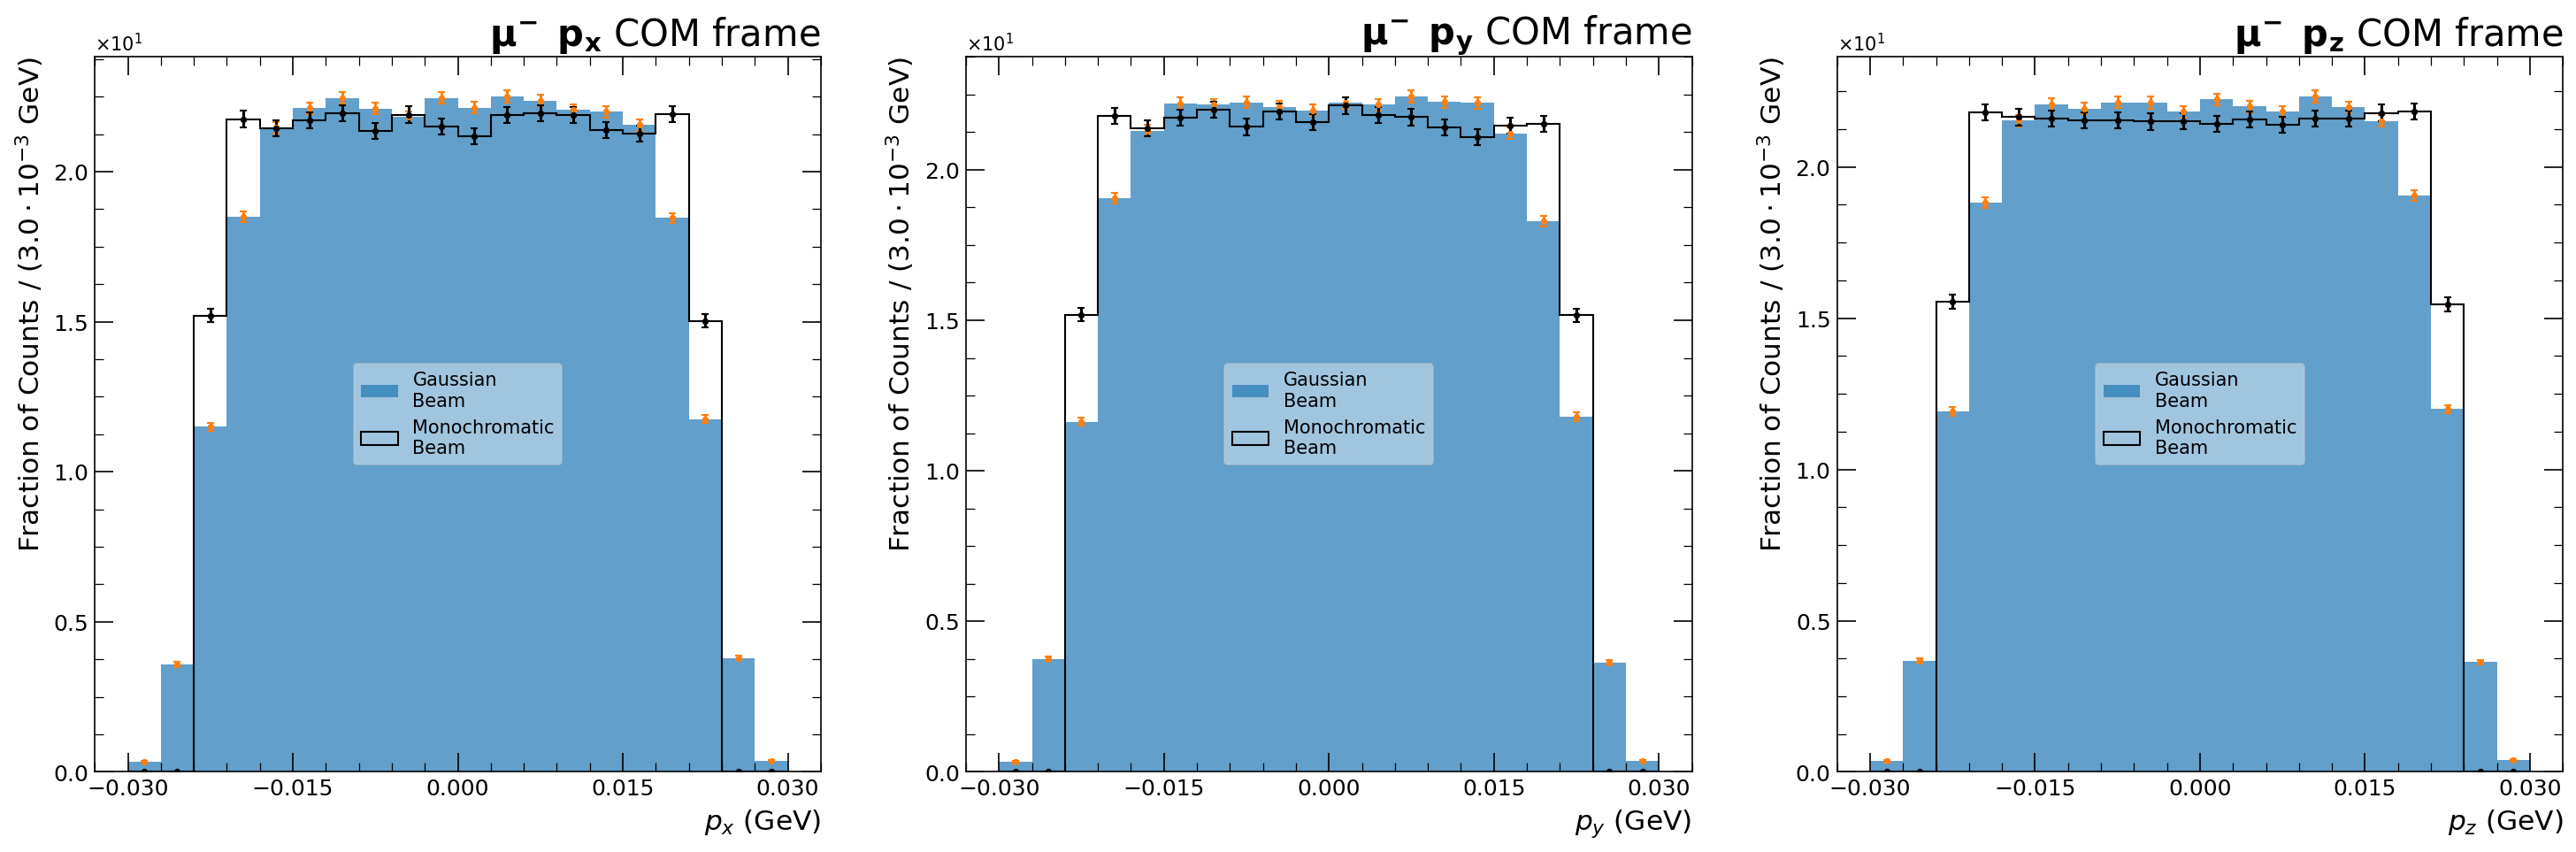

In [137]:
fig, ax = plt.subplots(1,3,figsize=(24,7))
pl.MuonPlotsCOMPads(ax, EnergiesOk,
                    plot_features=['CoM_Muon_px', 'CoM_Muon_py', 'CoM_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    xrange=(-0.03,0.03),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    plotlabel="Gaussian\nBeam",
                    legend_loc='center',
                    legend_bg='white',
                    legend_a=1,
                    legend=True,
                    legend_frame=True
                 )
pl.MuonPlotsCOMPads(ax, momenta,
                    plot_features=['CoM_Muon_px', 'CoM_Muon_py', 'CoM_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    xrange=(-0.03,0.03),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    histtype='step',
                    alpha=1.0,
                    plot_color='black',
                    err_color='black',
                    plotlabel="Monochromatic\nBeam",
                    legend_loc='center',
                    legend_bg='white',
                    legend_a=0.4,
                    legend=True,
                    legend_frame=True
                 )

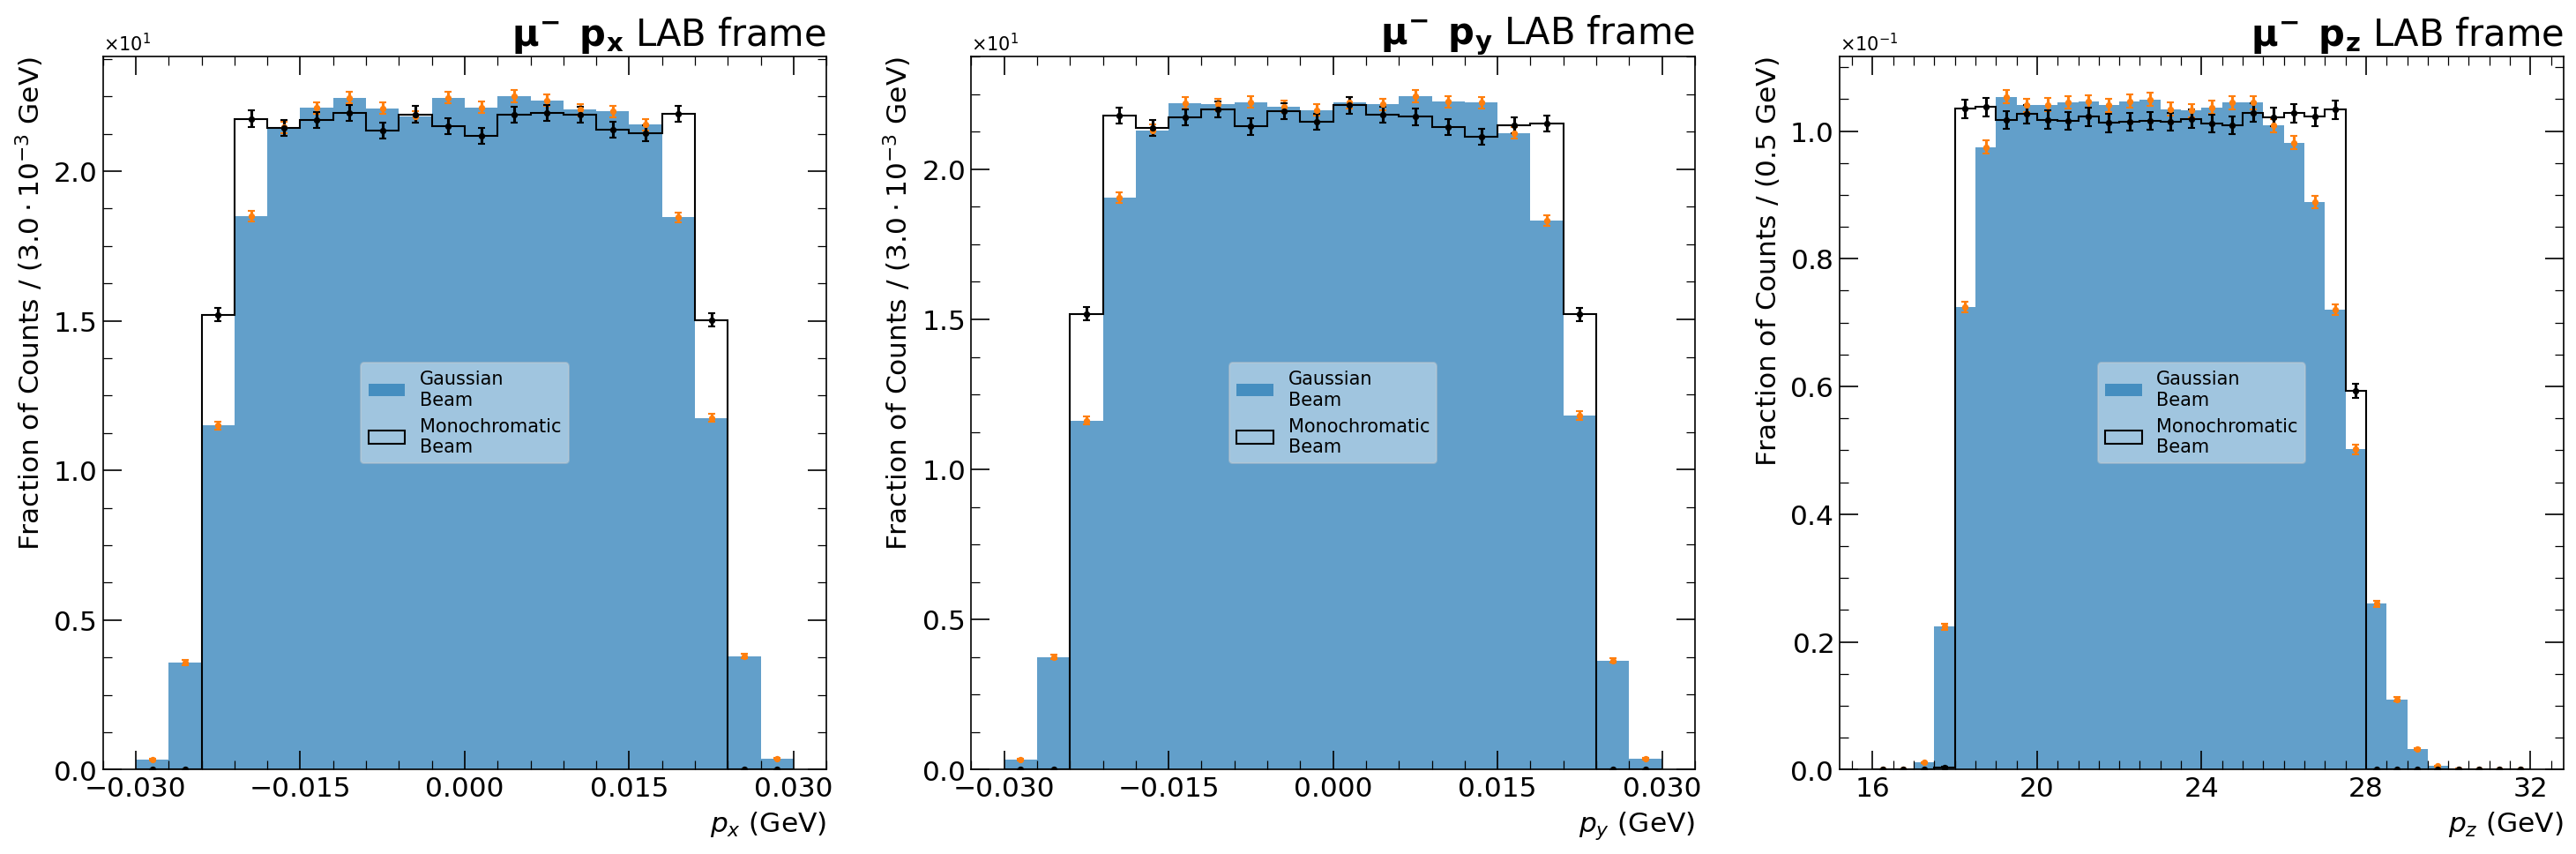

In [132]:
fig, ax = plt.subplots(1,3,figsize=(24,7))
pl.MuonPlotsLABPads(ax, EnergiesOk,
                    plot_features=['LAB_Muon_px', 'LAB_Muon_py', 'LAB_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    plotlabel="Gaussian\nBeam",
                    legend_loc='center',
                    legend_bg='white',
                    legend_a=1,
                    legend=True,
                    legend_frame=True
                 )
pl.MuonPlotsLABPads(ax, momenta,
                    plot_features=['LAB_Muon_px', 'LAB_Muon_py', 'LAB_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    histtype='step',
                    alpha=1.0,
                    plot_color='black',
                    err_color='black',
                    plotlabel="Monochromatic\nBeam",
                    legend_loc='center',
                    legend_bg='white',
                    legend_a=0.4,
                    legend=True,
                    legend_frame=True
                 )

Given the fact that we have the Muons and AntiMuons momentum components both in the COM and LAB frames, we produced a (very) simplified plot showing some "tracks" for the muons (i.e. the directions along which they are generated) originating from the interaction point (which in this case is fixed at the origin).

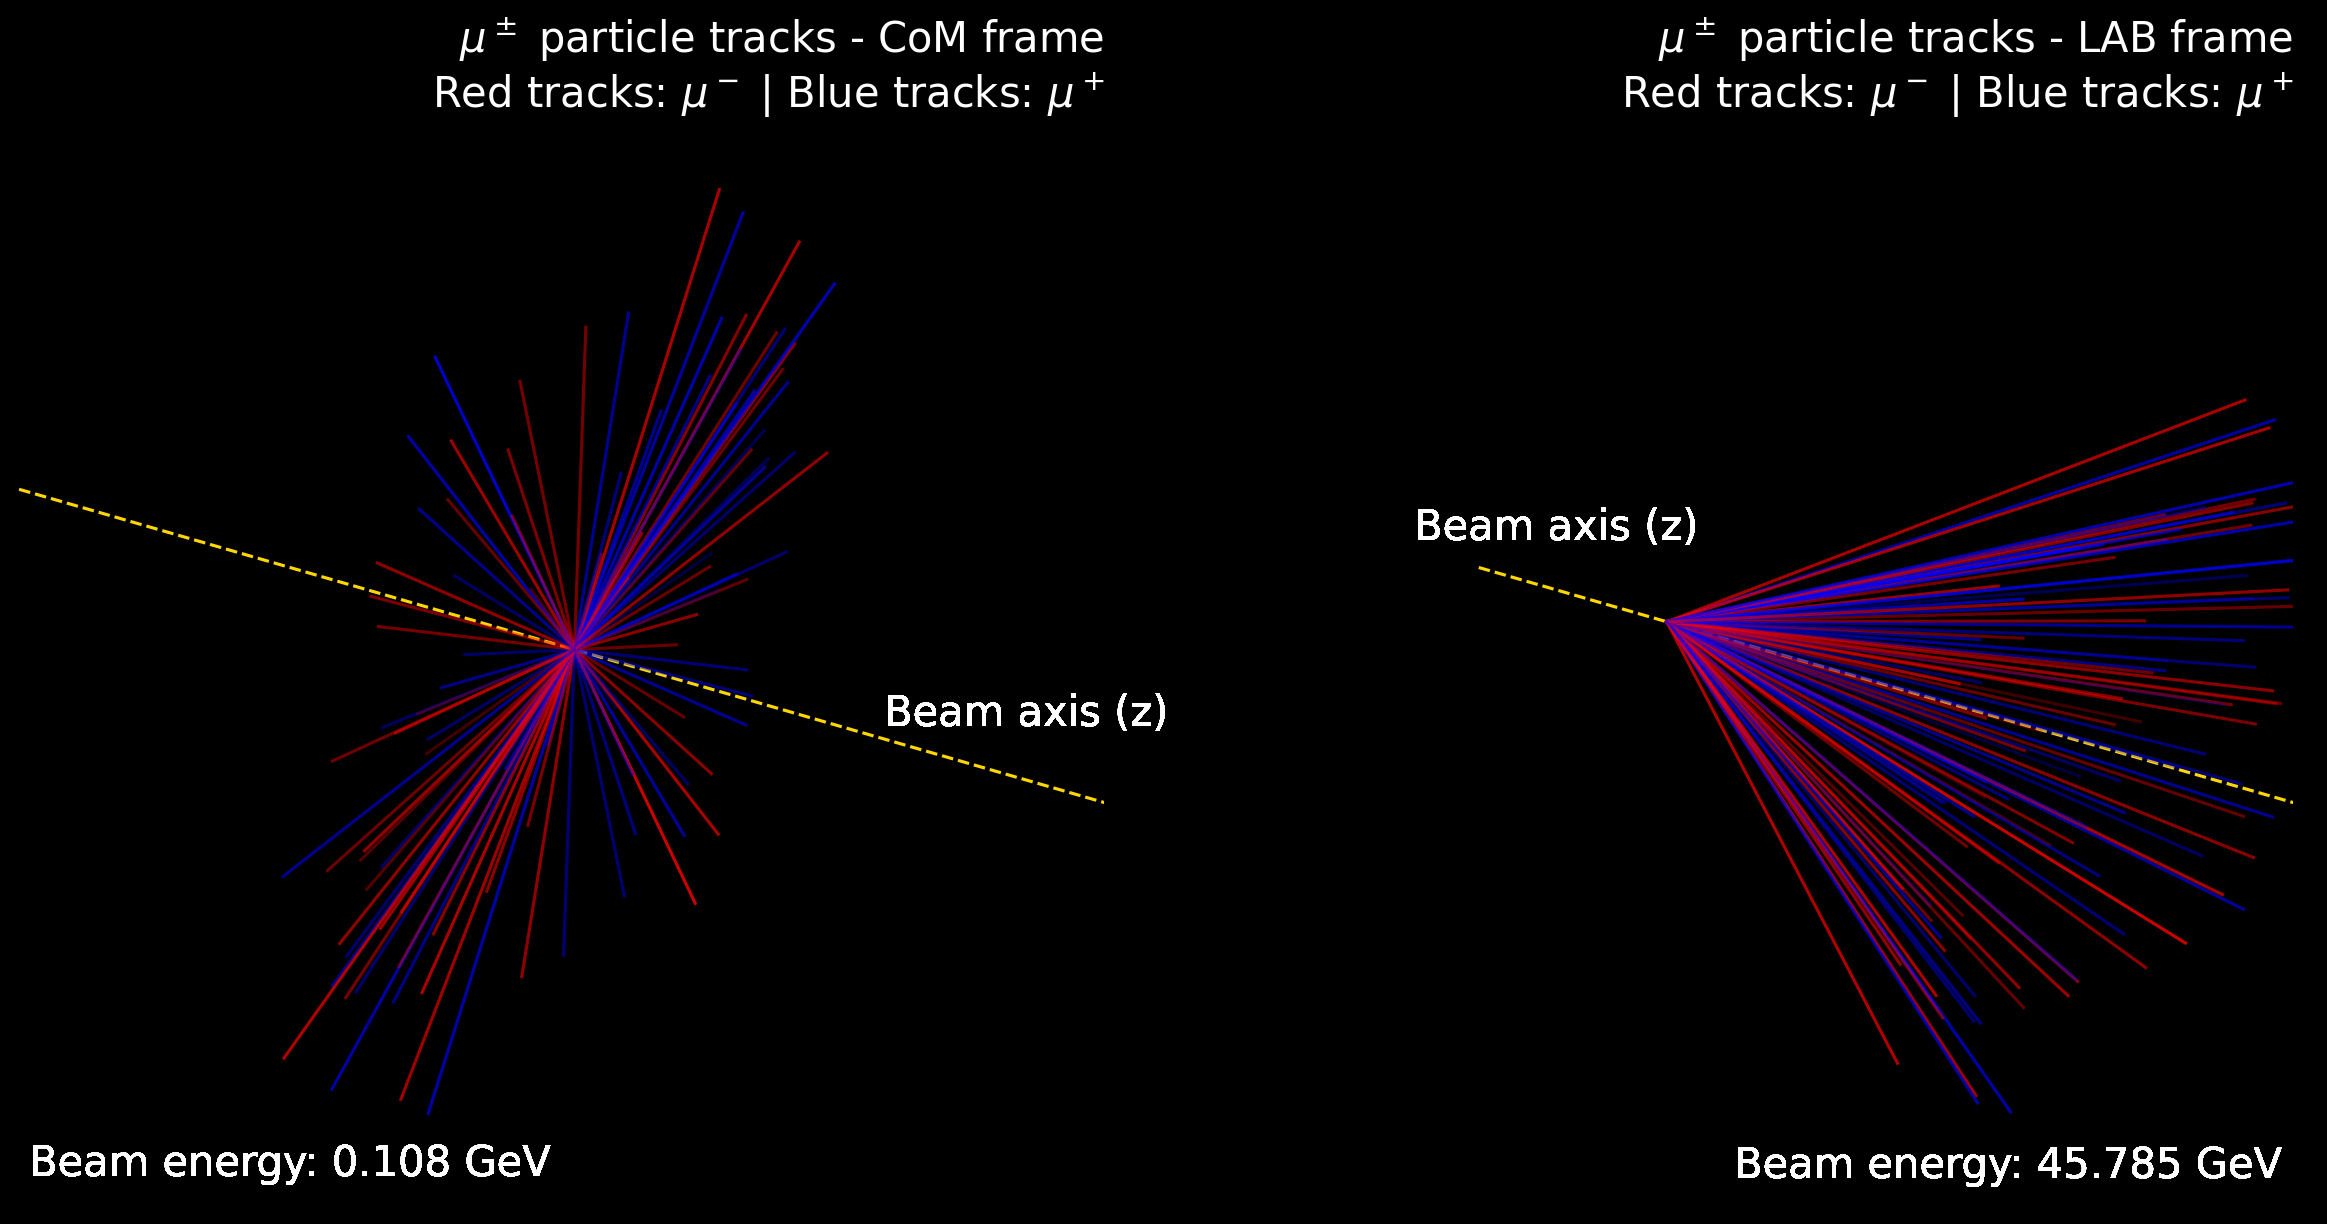

In [39]:
# muon tracks, let's see
fig = plt.figure(figsize=(16,8))
fig.set_facecolor('black')
ax0 = fig.add_subplot(1, 2, 1, projection='3d')
pl.MuonTracks(ax0, EnergiesOk, scaledEnergies,
                 beam_axis=[-20,20],
                 n_tracks = 50,
                 figtitle = "$\mu^\pm$ particle tracks - CoM frame\nRed tracks: $\mu^-$ | Blue tracks: $\mu^+$",
                 beam_energy = E_star,
                 frame = "CoM",
                 axes3d_xlim = [-10,10],
                 axes3d_ylim = [-0.015,0.015],
                 axes3d_zlim = [-0.015,0.015],
                 text_xyz_lab1 = [10, 0.001, 0.],
                 text_xyz_lab2 = [3.5, -0.05, 0.005]
               )
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
pl.MuonTracks(ax1, EnergiesOk, scaledEnergies,
                 beam_axis=[-10,40],
                 n_tracks = 50,
                 figtitle = "$\mu^\pm$ particle tracks - LAB frame\nRed tracks: $\mu^-$ | Blue tracks: $\mu^+$",
                 beam_energy = E_lab,
                 frame = "LAB",
                 axes3d_xlim = [-10,20],
                 axes3d_ylim = [-0.02,0.02],
                 axes3d_zlim = [-0.02,0.02],
                 text_xyz_lab1 = [-14., 0.001, 0.],
                 text_xyz_lab2 = [3, 0.001, -0.053]
               )
fig.tight_layout()

### Point 8

The energy of the positron goes as:
$$
    E(z) = E_0\exp{(-z/X_0)}
$$
where $E_0$ is the energy before interacting with the target. We can then calculate how the beam's energy profile will look like after it has passed the target, so that we may evaluate how much higher the energy should be in order to enable to beam to generate muon pairs across the whole length of the target.

The figure below shows the energy spectrums of the incident and emerging positron beams.

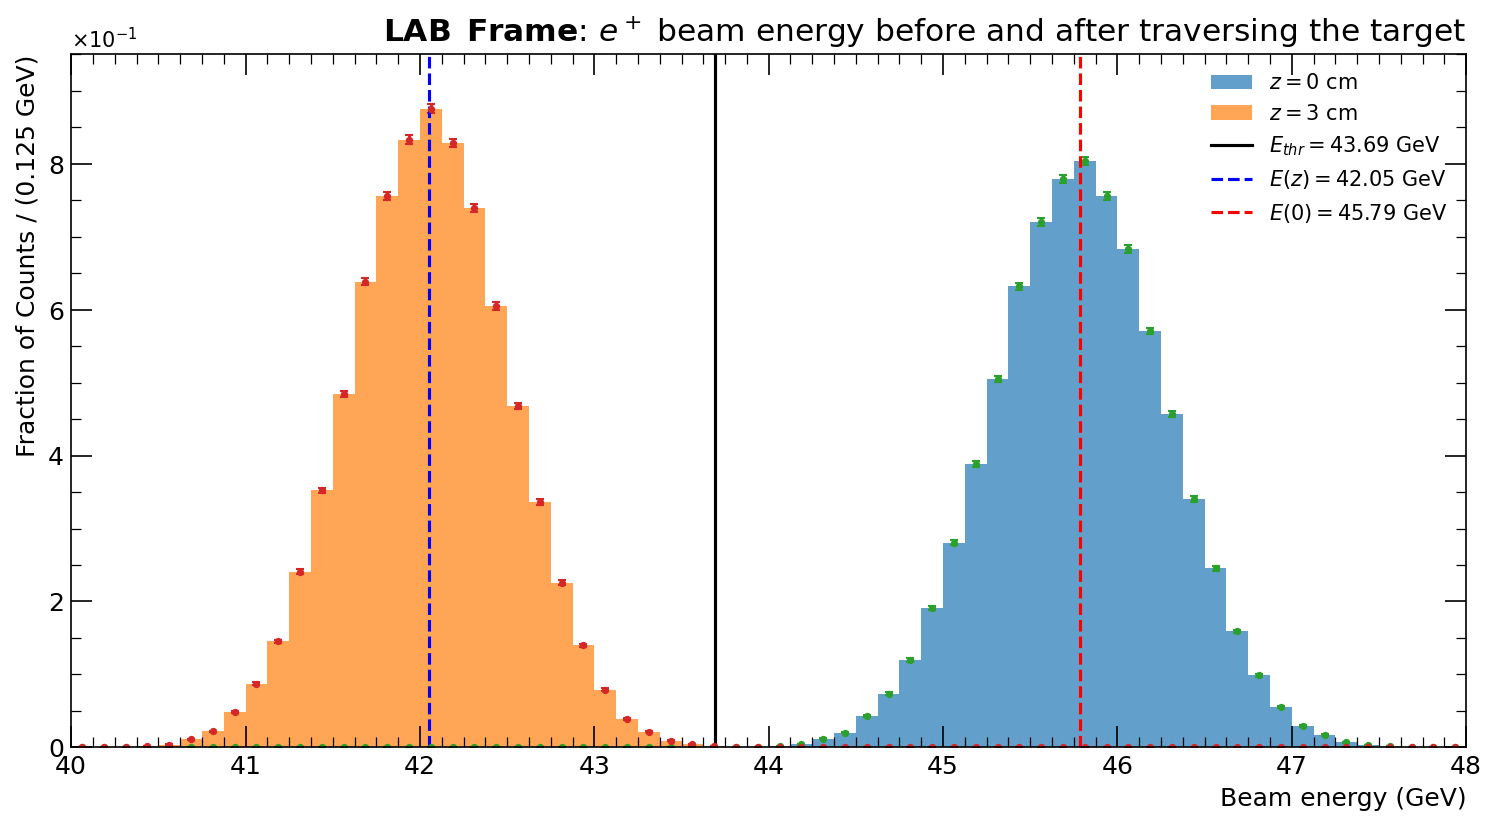

In [40]:
# computing the reduced energies due to transport inside the target
from lcpalib.const import PhysConst
pc = PhysConst().phys
target_Zmax = pc['target']['Zmax']
target_mat = pc['Be']
E_reduced = EnergiesOk['E_LAB_positron']*np.exp(-pc['target']['Zmax']/pc['Be']['X0'])
fig, ax = plt.subplots(figsize=(12,6))
pl.EnergiesBeforeAfter(ax, EnergiesOk['E_LAB_positron'], E_reduced, energies_range=(40,48), nbins=64,
                        label_0="$z=0$ cm",
                        label_1="$z=3$ cm",
                        E_lab_thr=E_lab_thr,
                        E_lab=E_lab,
                        yaxis_label="Fraction of Counts / (0.125 GeV)",
                          alpha=0.7,
                          figtitle=r"$\bf{LAB\hspace{0.5}Frame}$: "+"$e^+$ beam energy before and after traversing the target"
                        )

It is thus clear that the energy loss magnitude is such that the peak value of the emerging beam distribution lies well beneath the energy threshold for production. The energy distribution is both shifted and reshaped since if we name:
$$
k_z = \exp(-z/X_0)\rightarrow E_z = E_0\cdot k_z
$$
with $k_z \leq 1$ and if we name $\mu$ and $\sigma$ the location and scale of the incident beam distribution, we have that the emerging beam will have $(\mu_z,\sigma_z)$ given by:
$$
    \mu_z = \mathbb{E}[E_z] = \mathbb{E}[k_z E_0] = k_z \mu = k_z E_0
$$
$$
    \sigma_z^2 = \mathbb{E}[(E_z - \mu_z)^2] = \mathbb{E}[E_z^2 + \mu_z^2 - 2E_z \mu_z] = \mathbb{E}[E_z^2] - \mu_z\mathbb{E}[E_z] = k_z^2\mathbb{E}[E_0^2] - \mu^2 k_z^2 = k_z^2\cdot(\mathbb{E}[E_0^2] - \mu^2) = k_z^2 \sigma_0^2
$$
Thus we see that the thicker the target gets and the more the beam's peak energy will shift towards lower energies whilst its width gets smaller.

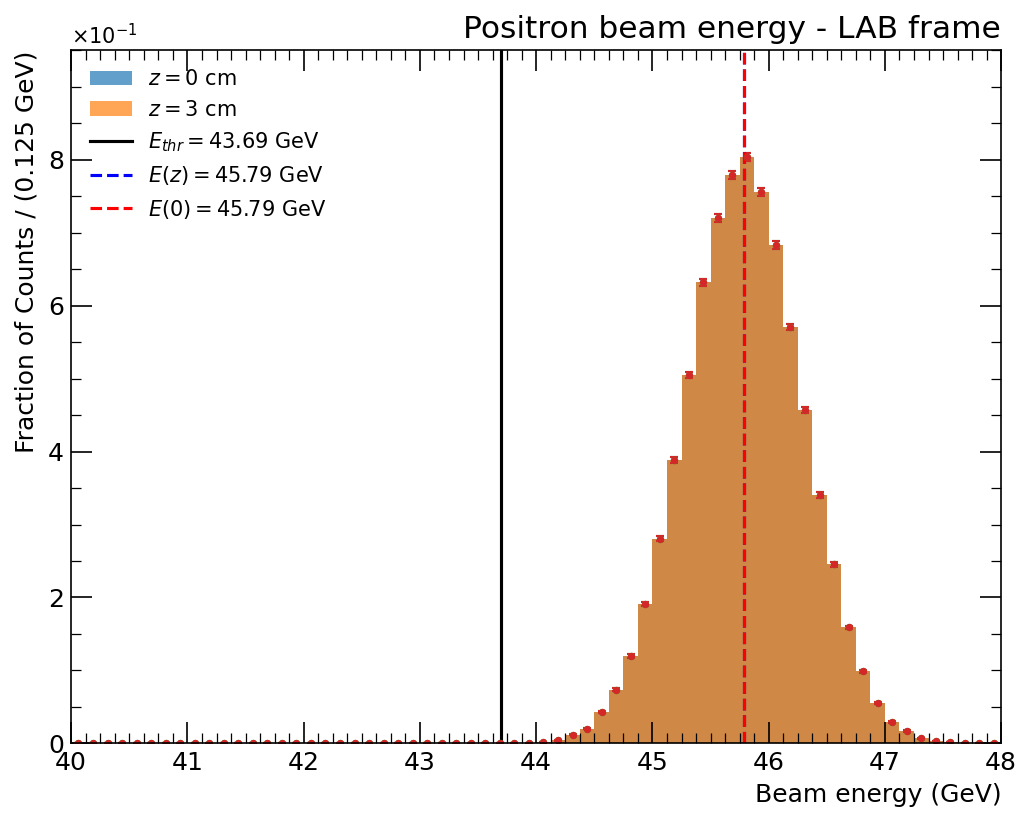

In [41]:
# script to build the animation
if (MODE==ps.kEDIT):
    pl.EnergiesBeforeAfterAnimation('./img/energy.mp4', EnergiesOk['E_LAB_positron'], E_lab_thr, E_lab)

In [42]:
Video("./img/energy.mp4",width=1024)

The plots clearly show that the emerging beam no longer has sufficient energy to generate $\mu^\pm$ pairs. Let's compute the energy loss.

In [43]:
# getting the energy loss
deltaE = E_lab*(1-np.exp(-pc['target']['Zmax']/pc['Be']['X0']))
print("Peak energy loss: {energy:1.4f} GeV".format(energy=deltaE))

Peak energy loss: 3.7324 GeV


In [44]:
# If we diminish it by the factor found above we would have:
E_lab_after = E_lab - deltaE
p_lab_after = np.sqrt(E_lab_after**2 - electron_mass**2)
print("LAB: Positron peak energy after traversing the target is:",round(E_lab_after,2),"GeV")

LAB: Positron peak energy after traversing the target is: 42.05 GeV


In [45]:
# Now, we boost this in the CoM to see how we're doing there
LAB_to_CoM_boost = LB.boost2CoM(p_lab_after, E_lab_after)
E_CoM_after = LAB_to_CoM_boost['E*']
p_CoM_after = LAB_to_CoM_boost['pz*']
print("CoM: Positron peak energy after traversing the target is:",round(E_CoM_after,4),"GeV")

CoM: Positron peak energy after traversing the target is: 0.1037 GeV


In order to ensure (up to a certain probability) that the positron beam energy can be compatible with muon pairs production threshold for the whole length of the target, the following reasoning was followed. The emerging beam's energy distribution is modelled as a gaussian, centered at the threshold energy in the lab frame. Then, this distribution is shifted to higher energies in small steps, until the area underneath the left tail (i.e. the probability of observing an energy value not compatible with production) becomes less than an arbitrary constant $k$ as follows:

$$
    p(E\leq E_{thr}) = \int_{-\infty}^{E_{thr}} N(E; \mu = E_{thr}+\Delta E, \sigma) d E < k,\hspace{1.0cm}k\approx 10^{-7}
$$

Once this condition is satisfied, the emerging beam's energy distribution will have a central energy of $E_{thr}+\Delta E$ and so the central energy of the incident beam will be this one rescaled by the loss factor $\exp{-z/X_0}$:

$$
    E_{0,corr}^{lab} = \frac{E_{thr}+\Delta E}{\exp{(-z/X_0)}}
$$

This is carried out in the next cell.

In [46]:
# defining the gaussian CDF
def cgauss(x, mu, sigma):
    return 0.5*(1 + special.erf((x-mu)/(sigma*np.sqrt(2))))

# initializing the variables
E_peak = E_lab_thr
# preparing some energy increments (from 0 to 5 GeV, arbitrary but covers the expected range)
E_increments = np.linspace(0,5,10**6)
# fixing probability factor
prob = 10**(-7)

# searching
for i in range(len(E_increments)):
    # computing the peak-ratio to compute an appropriate sigma for the candidate distribution
    peak_ratio = E_peak/E_lab
    peak_sigma = peak_ratio*0.5
    
    # computing the probability value to observe an energy value less than the threshold for a gaussian
    # located at E_peak with peak_sigma
    p = cgauss(E_lab_thr, E_peak, peak_sigma)
    if (p < prob):
        # found it!
        break;
    # otherwise, shifting the peak again to higher energies, and trying it again
    E_peak = E_lab_thr + E_increments[i]

# printing results
E_lab_corr = (E_peak/np.exp(-3/35.28)) - E_lab
print("Corrected emerging peak energy:",round(E_peak,2),"GeV")
print("Corrected incident peak energy:",round(E_lab_corr+E_lab,2),"GeV")
print("Energy correction:",round(E_lab_corr,2),"GeV")

Corrected emerging peak energy: 46.32 GeV
Corrected incident peak energy: 50.43 GeV
Energy correction: 4.65 GeV


In [47]:
# we can now re-calculate the quantities using this new peak-energy
# getting the 'Energies' dataframe that will contain the generated positrons
EnergiesCorrected = None

# Checking the mode
if MODE==ps.kEDIT:
    # Sample from normal distribution for the energy @ nominal E_lab and sigma = beam_s
    E_lab_sample=np.random.normal(E_lab_corr+E_lab, beam_s, N_simulated)
    p_lab_sample=np.sqrt(E_lab_sample**2 - electron_mass**2)

    # Now to boost back in the CoM all of the generated particles.
    # Since each particle will now have a different energy, given the fact that the beam is no more
    # monochromatic, each particle will have its beta and gamma
    positron_boosts_toCoM = LB.boost2CoM(p_lab_sample, E_lab_sample)

    # Creating the dataframe with the initial quantities
    EnergiesCorrected = pd.DataFrame({
        'E_CoM_positron': positron_boosts_toCoM['E*'],
        'pz_CoM_positron': positron_boosts_toCoM['pz*'],
        'E_LAB_positron': E_lab_sample,
        'absp_LAB_positron': p_lab_sample
    })

    # Sampling the angles via inverse-sample
    E_sqrt_s = 2*EnergiesCorrected['E_CoM_positron']
    ISAMPLER = smp.InverseSampler(N_simulated, cs.cdf_theta, np.arccos)
    ISAMPLER.runDifferentE(E_sqrt_s)
    thetas = ISAMPLER.getTransformedSamples()
    phis = np.random.random(N_simulated)*2*np.pi

    # Generating muon data
    # Absolute value of p-vector in the center of mass
    EnergiesCorrected["absP_MuMu_CoM"] = np.sqrt((EnergiesCorrected["E_CoM_positron"])**2 - m_mu**2)

    # Momenta in the CoM
    EnergiesCorrected["CoM_AntiMuon_px"] = EnergiesCorrected["absP_MuMu_CoM"]*np.cos(phis)*np.sin(thetas)
    EnergiesCorrected["CoM_AntiMuon_py"] = EnergiesCorrected["absP_MuMu_CoM"]*np.sin(phis)*np.sin(thetas)
    EnergiesCorrected["CoM_AntiMuon_pz"] = EnergiesCorrected["absP_MuMu_CoM"]*np.cos(thetas)
    EnergiesCorrected["CoM_Muon_px"] = -EnergiesCorrected["CoM_AntiMuon_px"]
    EnergiesCorrected["CoM_Muon_py"] = -EnergiesCorrected["CoM_AntiMuon_py"]
    EnergiesCorrected["CoM_Muon_pz"] = -EnergiesCorrected["CoM_AntiMuon_pz"]

    # Preparing to boost to the Lab
    #b2L = LB.LorentzBoost(m_mu, E_positron_cm=EnergiesCorrected["E_CoM_positron"])

    # Boosting AntiMuons to the Lab
    b2L = LB.boost2LAB(EnergiesCorrected['CoM_AntiMuon_pz'], EnergiesCorrected["E_CoM_positron"])
    pB,EB = b2L['pz'], b2L['E']
    EnergiesCorrected['LAB_AntiMuon_px'] = EnergiesCorrected['CoM_AntiMuon_px']
    EnergiesCorrected['LAB_AntiMuon_py'] = EnergiesCorrected['CoM_AntiMuon_py']
    EnergiesCorrected['LAB_AntiMuon_pz'] = pB

    # Boosting Muons to the Lab
    b2L = LB.boost2LAB(EnergiesCorrected['CoM_Muon_pz'], EnergiesCorrected["E_CoM_positron"])
    pB, EB = b2L['pz'], b2L['E']
    EnergiesCorrected['LAB_Muon_px'] = EnergiesCorrected['CoM_Muon_px']
    EnergiesCorrected['LAB_Muon_py'] = EnergiesCorrected['CoM_Muon_py']
    EnergiesCorrected['LAB_Muon_pz'] = pB
    
    # Saving the dataframe to disk
    EnergiesCorrected.to_pickle('./pkl/EnergiesCorrected_dataFrame.pkl')
else:
    # Loading the data from disk
    EnergiesCorrected = pd.read_pickle('./pkl/EnergiesCorrected_dataFrame.pkl')


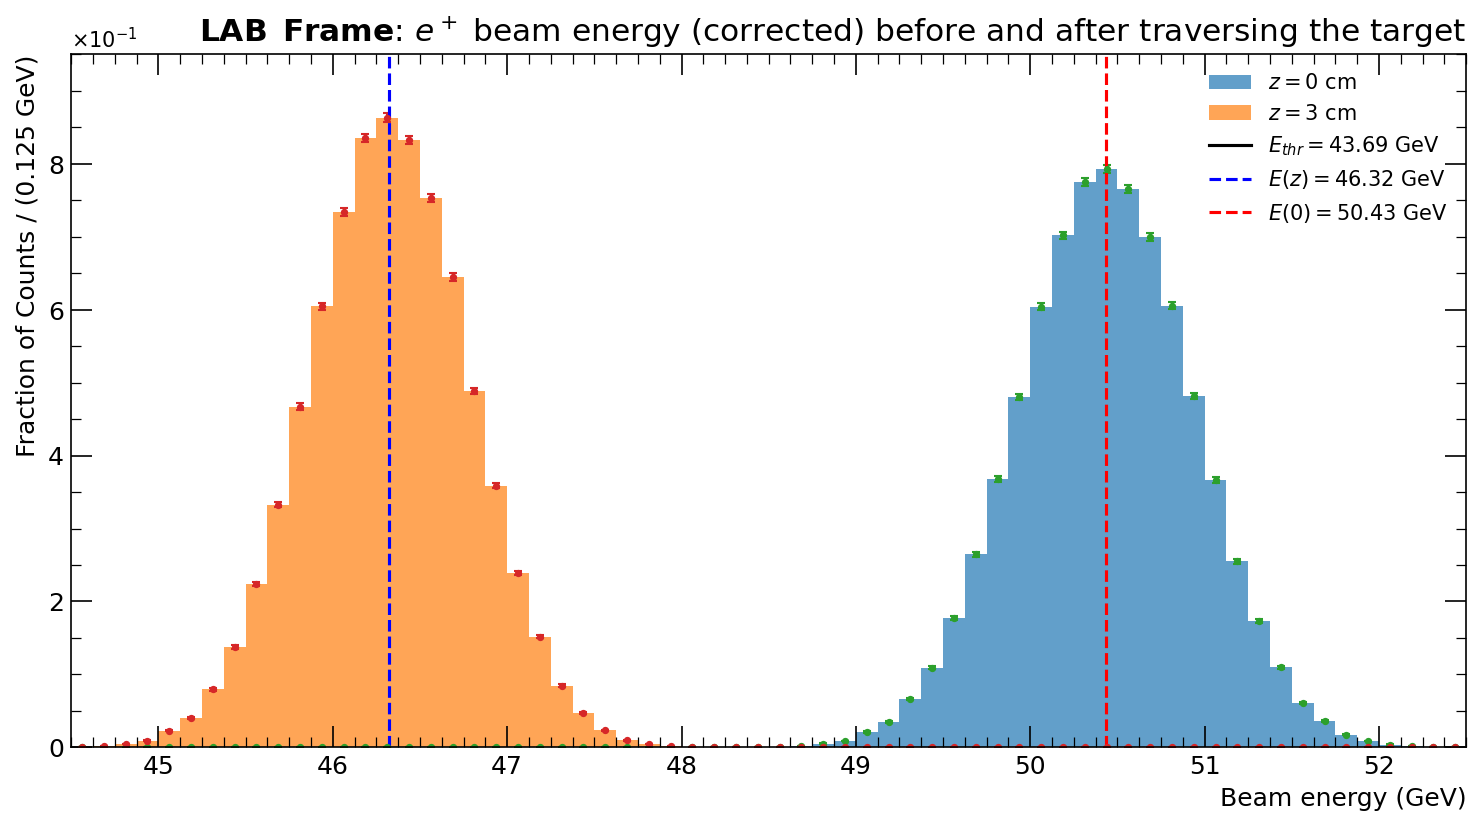

In [48]:
E_reduced = (EnergiesCorrected['E_LAB_positron'])*np.exp(-target_Zmax/target_mat['X0'])
fig, ax = plt.subplots(figsize=(12,6))
pl.EnergiesBeforeAfter(ax,
                          EnergiesCorrected['E_LAB_positron'],
                          E_reduced,
                          energies_range=(44.5,52.5),
                          nbins=64,
                          label_0="$z=0$ cm",
                          label_1="$z=3$ cm",
                          E_lab_thr=E_lab_thr,
                          E_lab=E_lab+E_lab_corr,
                          yaxis_label="Fraction of Counts / (0.125 GeV)",
                          alpha=0.7,
                          figtitle=r"$\bf{LAB\hspace{0.5}Frame}$: "+"$e^+$ beam energy (corrected) before and after traversing the target"
                        )

The muon momenta with the corrected energies are shown below.

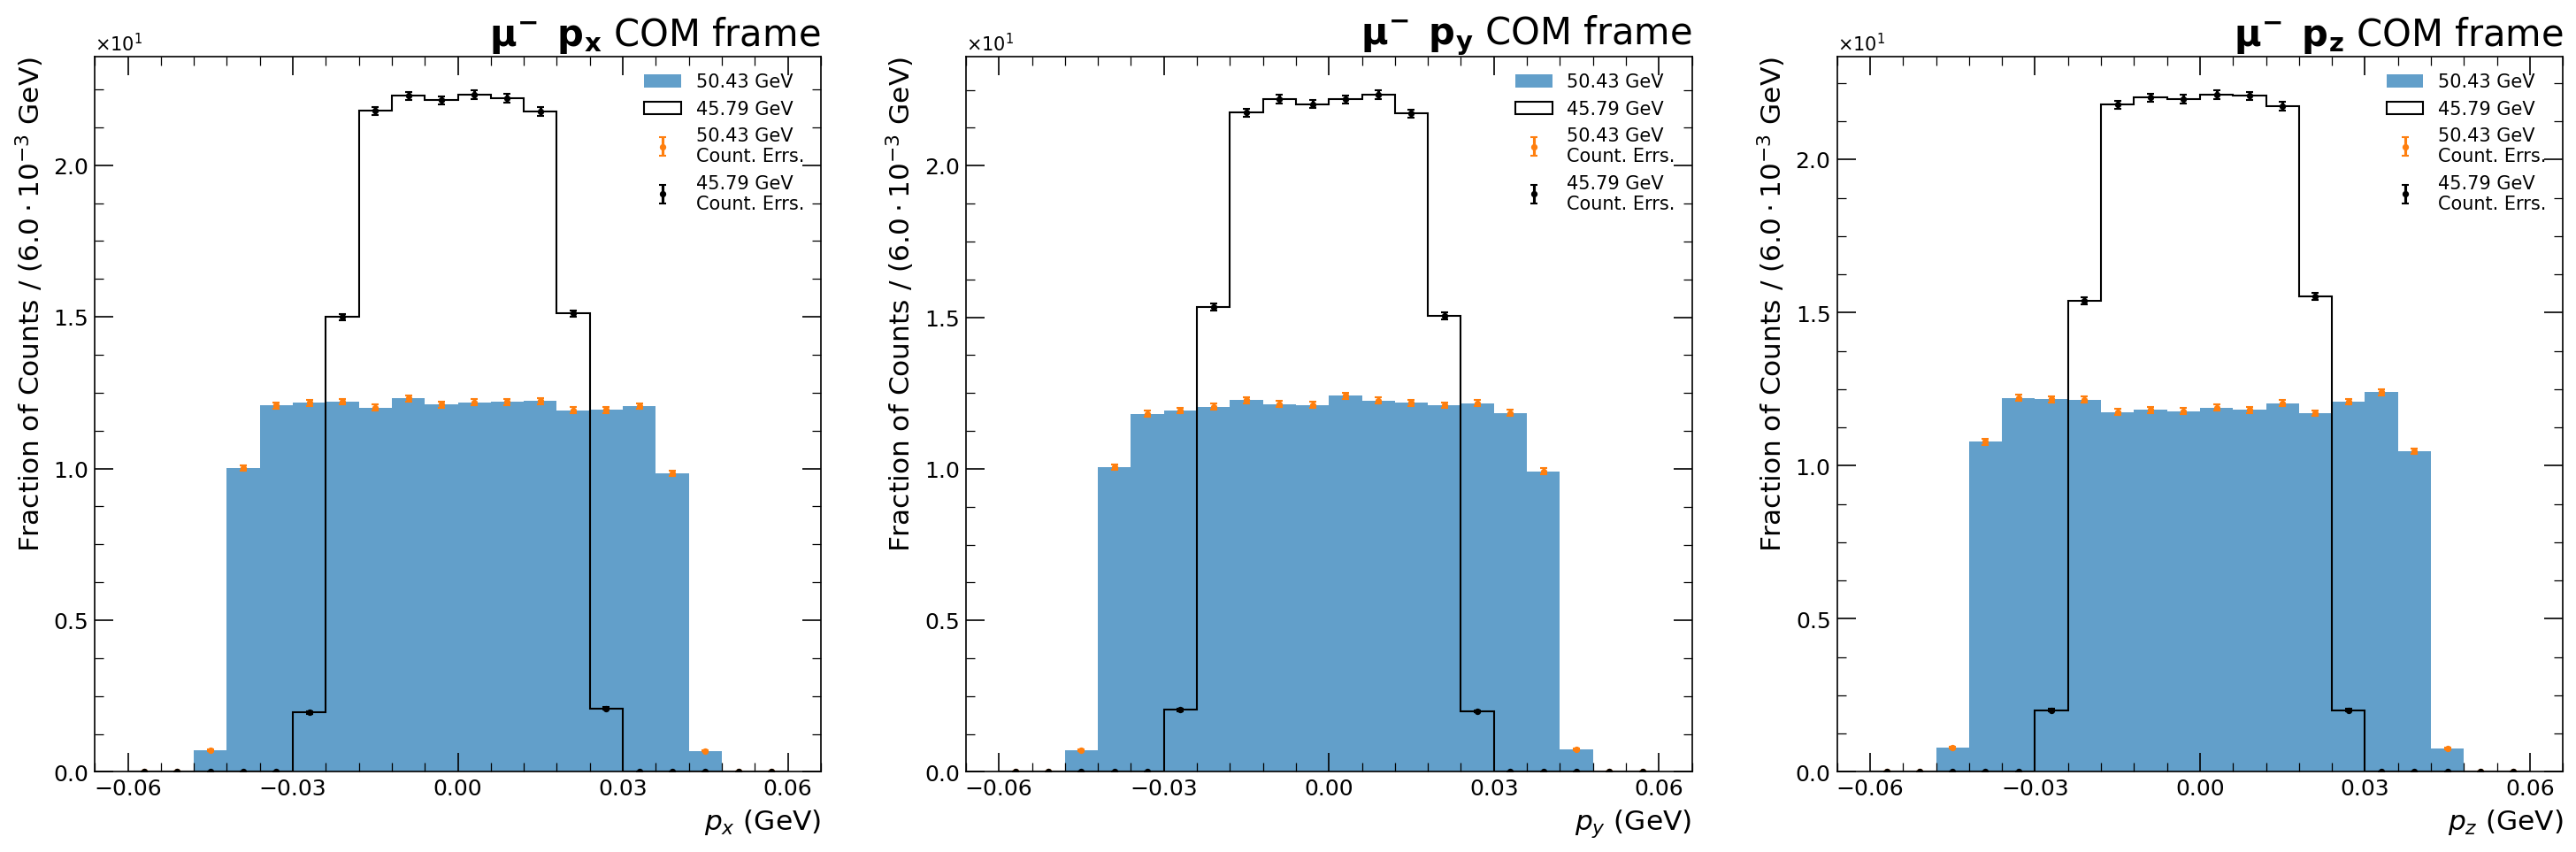

In [138]:
fig, ax = plt.subplots(1,3,figsize=(24,7))
pl.MuonPlotsCOMPads(ax, EnergiesCorrected,
                    plot_features=['CoM_Muon_px', 'CoM_Muon_py', 'CoM_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    xrange=(-0.06,0.06),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    plotlabel=str(round(E_lab+E_lab_corr,2))+" GeV",
                    errlabel=str(round(E_lab+E_lab_corr,2))+ " GeV\nCount. Errs.",
                 )
pl.MuonPlotsCOMPads(ax, EnergiesOk,
                    plot_features=['CoM_Muon_px', 'CoM_Muon_py', 'CoM_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    xrange=(-0.06,0.06),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    histtype='step',
                    alpha=1.0,
                    plotlabel=str(round(E_lab,2))+" GeV",
                    errlabel=str(round(E_lab,2))+ " GeV\nCount. Errs.",
                    legend=True,
                    plot_color='black',
                    err_color='black'
                 )

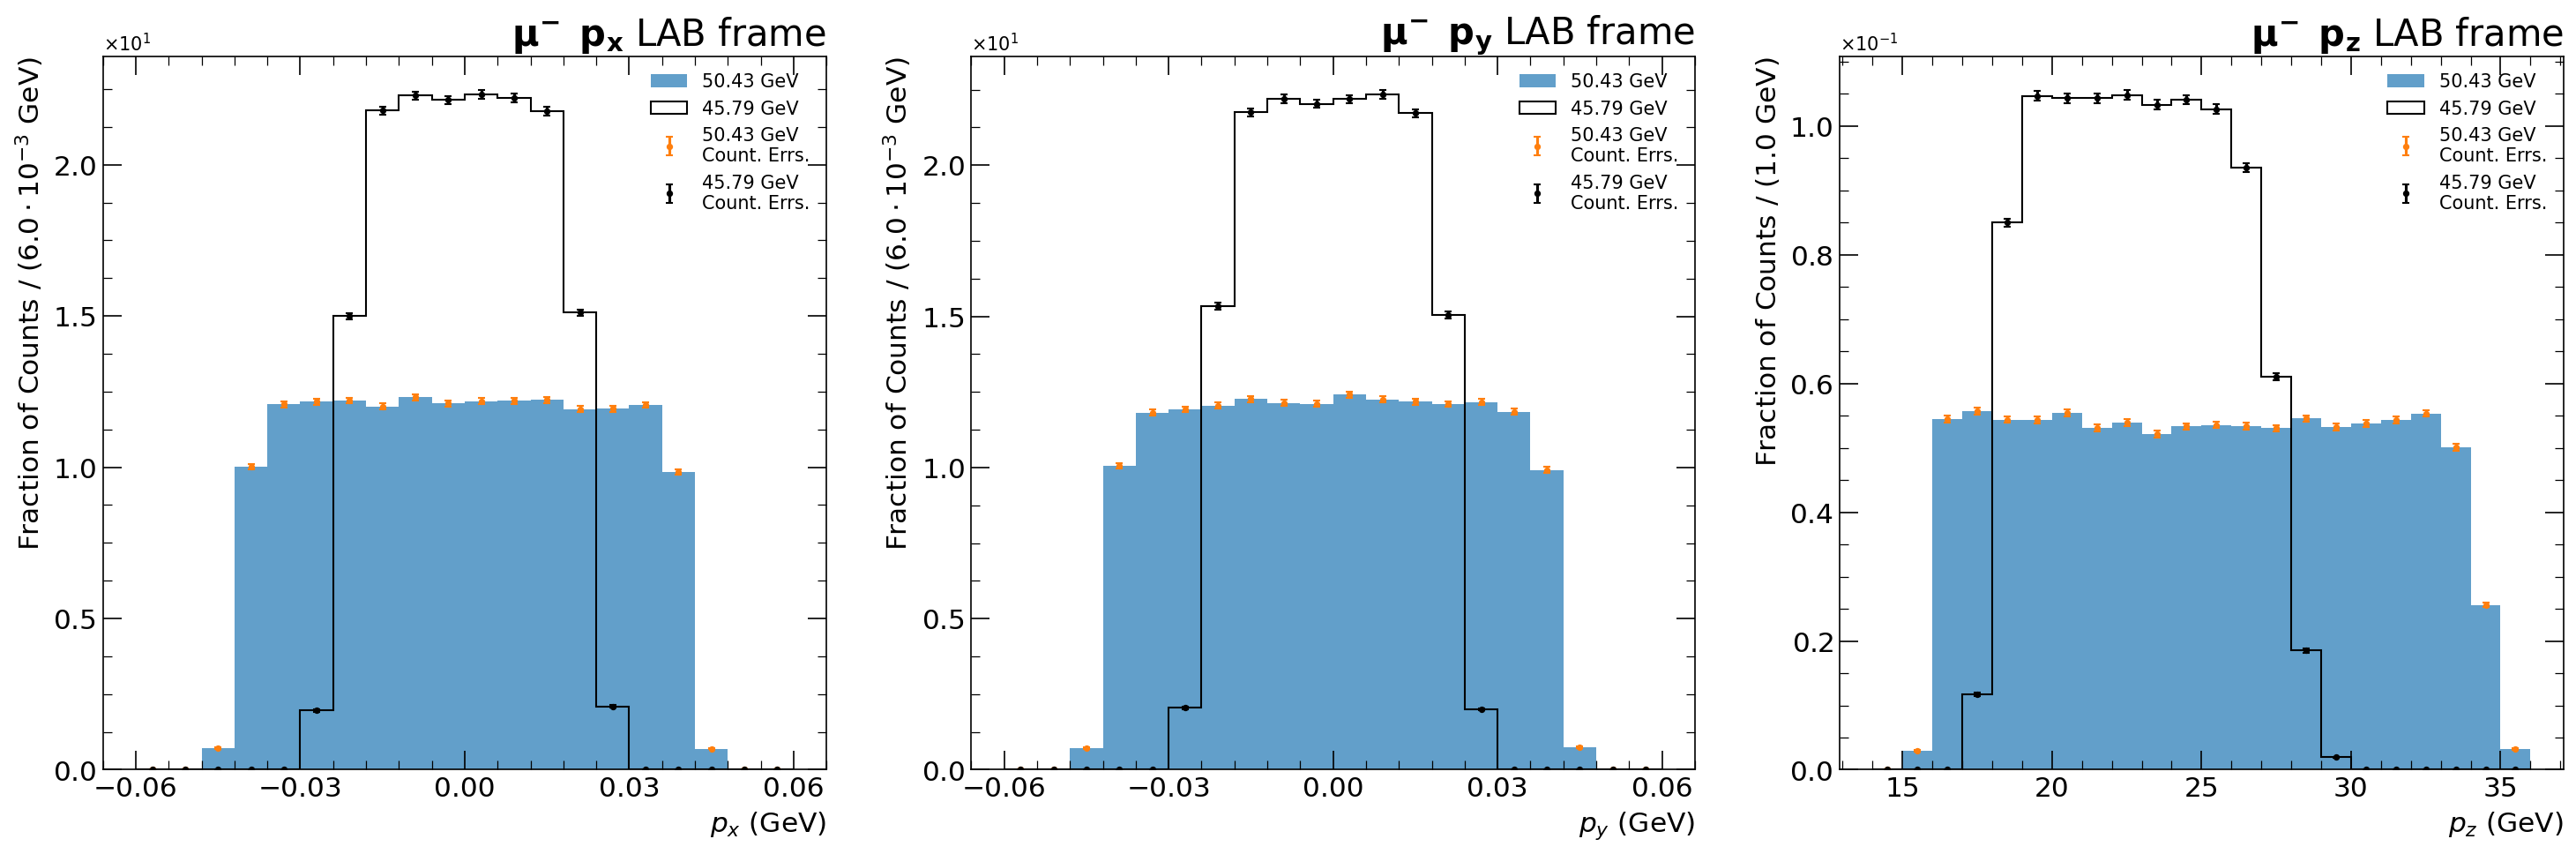

In [139]:
fig, ax = plt.subplots(1,3,figsize=(24,7))
pl.MuonPlotsLABPads(ax, EnergiesCorrected,
                    plot_features=['LAB_Muon_px', 'LAB_Muon_py', 'LAB_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    xrange_xy=(-0.06,0.06),
                    xrange_z=(14,36),
                    nbins_z=22,
                    maxloc_x_z=6,
                    minloc_x_z=5,
                    plotlabel=str(round(E_lab+E_lab_corr,2))+" GeV",
                    errlabel=str(round(E_lab+E_lab_corr,2))+ " GeV\nCount. Errs."
                 )
pl.MuonPlotsLABPads(ax, EnergiesOk,
                    plot_features=['LAB_Muon_px', 'LAB_Muon_py', 'LAB_Muon_pz'],
                    plot_labels=['x', 'y', 'z'],
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                    xrange_xy=(-0.06,0.06),
                    xrange_z=(14,36),
                    nbins_z=22,
                    maxloc_x_z=6,
                    minloc_x_z=5,
                    alpha=1.0,
                    histtype='step',
                    plotlabel=str(round(E_lab,2))+" GeV",
                    errlabel=str(round(E_lab,2))+ " GeV\nCount. Errs.",
                    legend=True,
                    plot_color='black',
                    err_color='black'
                 )

### Point 9

Take the former point into account when generating the events ($\sqrt{s}$ now depends on the position along the target where the $e^+ - e^-$ scattering occurrs).

#### Model
In order to take this into account, the idea was to compute an energy distribution from which data samples could be taken.
The hypothesis is that at each depth in the target, we can imagine there is an energy distribution which is obtained from the incident energy distribution by shifting it according to the $E(z)$ dependance. Each of these distributions is then weighted by the values of the $\mu^\pm$ production cross sections at those energies and, finally, these are summed and the final sum is normalized obtaining the required energy distribution.

This is a semplification since it neglects the tracks of the positrons. The tracks are important since they identify the particle and one can make sure, for instance, that the same positron does not engage into multiple $\mu^\pm$ pair production processes which would be inconsistent.

In order to test this simplified model, we wrote a simulation whose algorithm instead tracks each positron as it propagates and compared the results.

#### Simulation logic
The algorithm follows this logic:
1. A positron is sampled from the beam.
2. It is propagated for a fixed step ($\Delta z$) in the material along the $z$ direction.
3. The energy of the positron at that depth, in the lab frame, is computed and boosted to the center of mass frame.
4. If the energy in the CoM is compatible with production, the probability of interaction ($\propto \sigma(s)$) with that energy value is computed.
5. A uniform number between $0$ and $1$ is sampled and:
   1. if it is less than the interaction probability, the interaction occurrs and the muon-pair is generated at that energy and the positron propagation cycle stops.
   2. if it is not, go back to point 2 and reiterate until an interaction occurrs or the positron exits without interacting.

#### Physical description and explanation
The target has thickness $L=3cm$ and it is seen by each positron as if sliced up into a number $N$ of virtual layers of equal thicknesses $\Delta z$ stacked together as shown in the following picture with $6$ virtual layers.

<div align="center">
    <img src="./img/target_virt.png" width=500><br>
    Figure 9.1
</div>

Thus we have $\Delta z = L/N$.

Each transport step is independent from all the others: the particle enters any given virtual layer at point $i\Delta z$ with energy $E(i\Delta z)$ and arrives at the end of that same layer at point $(i+1)\Delta z$ with reduced energy $E((i+1)\Delta z)$, where the interaction probability is evaluated. The "history" of the particle is encoded in its energy that gets reduced the deeper it travels in the target as a whole and the energy, in turn, modulates the $\mu^\pm$ production process' cross section $\sigma(s)$.

Each time the positron propagates by $\Delta z$ in the material, it has seen a layer of material of thickness $\Delta z$ at an energy given by:
$$
    E(i\cdot\Delta z) = E_0\cdot\exp{(-i\cdot\Delta z/X_0)}
$$
where $i$ is the number of steps taken up at that point and $E_0$ is the incident beam energy. This energy is boosted to the center of mass frame, obtaining $E^*$ which is just $\sqrt{s}/2$. The value that is fed into $\sigma$ is thus $s = 4\cdot (E^*)^2$.

The interaction probability is evaluated, at each step, as specified in [12] (p.30):
$$
    P(s) = N_{e^-}\cdot\Delta z\cdot\sigma(s)
$$
which is valid if $N\cdot\Delta z\cdot\sigma(s) \ll 1$, where $N_{e^-}$ is the volume density of scatterers (in this case the electrons in the target) in units of $cm^{-3}$ defined by:
$$
    N(e^{-}) = \frac{\rho N_A Z}{A}
$$
where $N_A$ is Avogadro's number, $\rho$ is the mass density of the target's material, $Z$ is the atomic number ($=4$ for Beryllium) and $A$ is the molar mass of the target's material. Further, $\Delta z$ is the fixed step in units of $cm$ and $\sigma(s)$ is the fully integrated cross section of the muon pair production process expressed in $cm^2$. In the energy regions that are of interest for this exercise, P is usually in the range of $10^{-7}$, so the approximation holds.

Given the fact that the interaction probability is quite small and that the primary objective was to obtain sufficient data to test whether the simplified model agreed with it, a traditional "for-loop" approach was not optimal, and a more "parallel" approach was needed. For this reason, the algorithm was moved from Python to a CUDA kernel. This was preferred over the possibility of using libraries like numba/cupy in order to take advantage of C++ speed.

#### CUDA implementation

Since each positron is propagated independently from all the others, it seemed an ideal situation for parallelization on a GPU. The device that was used is a Nvidia Maxwell GPU residing on an Nvidia Jetson board. The CUDA grid upon which the kernel is launched was set at $32$ threads per block over $32$ blocks, thus obtaining $1024$ running threads. Since each thread propagates a positron, bunches of $1024$ positrons are propagated simultaneously.

<div align="center">
    <img src="./img/target_virt_threads.png" width=500><br>
    Figure 9.2
</div>

Specifically:
1. While each positron is propagated with the same fixed step $\Delta z$, each thread can apply a uniformly distributed random initial offset (a fraction of $\Delta z$) so that even if the positron is always advanced by the same amount, the offset allows for threads to sample energy on a richer set of spatial locations (similarly to an ADC interleaving technique in digital electronics). This is shown in figure 9.2.
2. If the positron exits the target without interacting, the thread starts another propagation loop sampling another positron from the incident beam. This is repeated until a positron finally interacts or until a maximum number of trials is reached, after which the thread exits anyway due to memory limitations.
3. This "thread recycling" policy allows to further minimize the host-device dead time that would otherwise be required to re-launch the kernel.
4. The cycle starts again with another bunch of positrons until the desired number of events is collected.

The data is then saved as a text file and finally saved by a python script into numpy format for further analysis. Following this approach, with a coarse spatial resolution ($\Delta z = 0.5$ cm), the GPU implemented simulator generated $\approx 4.2$ events/s, while its implementation on the CPU generated $\approx 0.13$ events/s ($\approx 32$ times faster). With much "finer" resolutions ($\Delta z = 0.05$ cm), the event generation rate falls to $0.6$ events/s and $0.02$ events/s for the GPU and CPU respectively.

#### Simulation results and comparison with simplified model

The simulation was set with an incident beam energy in the LAB of $50.43$ GeV ($0.1135$ GeV in the CoM), which was the value that was calculated before in order to have pair production across the whole length of the target. In addition to the "standard" dataset with the target thickness set at $3$ cm there are also two other datasets with a thin target ($1$ cm) and a thick one ($10$ cm). The number of steps was fixed at $15$.

In [51]:
# loading CUDA simulation results
sim_setups = {'10cm':'cuda_target10cm.npy','3cm':'cuda_target3cm.npy','1cm':'cuda_target1cm.npy'}
thickness = '3cm'

# generating a dataframe
EnergiesCUDA = pd.DataFrame()

# the events are listed as:
# z coordinate of interaction, center of mass energy, lab frame energy
if (MODE==ps.kEDIT):
    cuda_sim = np.load('./npy/'+sim_setups[thickness])
    # generating a dataframe
    EnergiesCUDA['z_interaction'] = cuda_sim[:,0]
    EnergiesCUDA['E_CoM_positron'] = cuda_sim[:,1]
    EnergiesCUDA['E_LAB_positron'] = cuda_sim[:,2]
    EnergiesCUDA['sqrt_s'] = 2*cuda_sim[:,1]
else:
    # Loading the dataframe from cuda and the inverse sampled one
    EnergiesCUDA = pd.read_pickle('./pkl/EnergiesCUDA_dataFrame.pkl')

The simplified model distribution (the energy spectrum of the positrons that interacted in the LAB frame) is calculated in the next cell.

In [133]:
LB.boost2CoM(np.sqrt(E_lab_n**2 - electron_mass**2), E_lab_n)

{'pz*': 0.113516, 'E*': 0.113517, 'beta': 0.999990, 'gamma': 222.147744}

In [52]:
# defining a gaussian function with amplitude 1
def gaussf(x, mu, sigma):
    return (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((x-mu)/(sigma))**2)

# setting the lab energy to the level obtained in the previous point
E_lab_n = E_lab_corr+E_lab

# n_pts determines how many "gaussians" we want to sum
n_pts = 1000
z_depths = np.linspace(0,target_Zmax,n_pts+1)
# arrays to hold the parameters of the various gaussians
mus = []
sigmas = []
csec = []

# looping through the depths
for i in range(1,n_pts+1,1):
    # computing the gaussian peak (i.e. the gaussian) at this depth
    peak = E_lab_n*np.exp(-z_depths[i]/target_mat['X0'])
    # shifting and reshaping
    mus.append(peak)
    sigmas.append(0.5*np.exp(-z_depths[i]/target_mat['X0']))
    # computing cross section at this energy
    b2C = LB.boost2CoM(np.sqrt(peak**2 - electron_mass**2), peak)['E*']
    csec.append(cs.sigma_nb(4*b2C**2))

# computing now the weights that will re-weight the gaussian mixture.
# these weights are due to the cross-section's energy dependance.
weights = (csec/np.sum(csec))

# computing the mixture by generating energy counts distributions at each depth
counts, edges= np.histogram(EnergiesCUDA['E_LAB_positron'],bins=1024,range=(44,52),density=True)
centers_env = 0.5*(edges[1:]+edges[:-1])
# each gaussian is binned (centers_env is discrete) and the counts are reweighted by applying the weights calculated above
f = gaussf(centers_env, mus[0], sigmas[0])*weights[0]
for i in range(1,n_pts,1):
    f += gaussf(centers_env, mus[i], sigmas[i])*weights[i]

# checking normalization
wnorm = 1./(np.sum(weights))
f = f*wnorm

We can thus inverse-sample the distribution that was just computed in order to obtain events.

In [53]:
def IS_energy(f):
    # computing the cumulative distribution
    mycdf = np.cumsum(f)
    mycdf = mycdf / mycdf[-1]
    
    # inverse sampling between 44 and 52 GeV
    bin_midpoints = np.linspace(44,52,1024)
    values = np.random.rand(len(EnergiesCUDA))
    value_bins = np.searchsorted(mycdf, values)
    random_from_cdf = bin_midpoints[value_bins]

    return random_from_cdf

# boosting to com and building a df
EnergiesIS = pd.DataFrame()
if (MODE==ps.kEDIT):
    # sampling
    random_from_cdf = IS_energy(f)
    EnergiesIS['E_CoM_positron'] = LB.boost2CoM(np.sqrt(random_from_cdf**2 - electron_mass**2), random_from_cdf)['E*']
    EnergiesIS['E_LAB_positron'] = random_from_cdf
    EnergiesIS['sqrt_s'] = 2*EnergiesIS['E_CoM_positron']
else:
    EnergiesIS = pd.read_pickle('./pkl/EnergiesIS_dataFrame.pkl')

We can thus display the interaction energies in the LAB and COM frames.

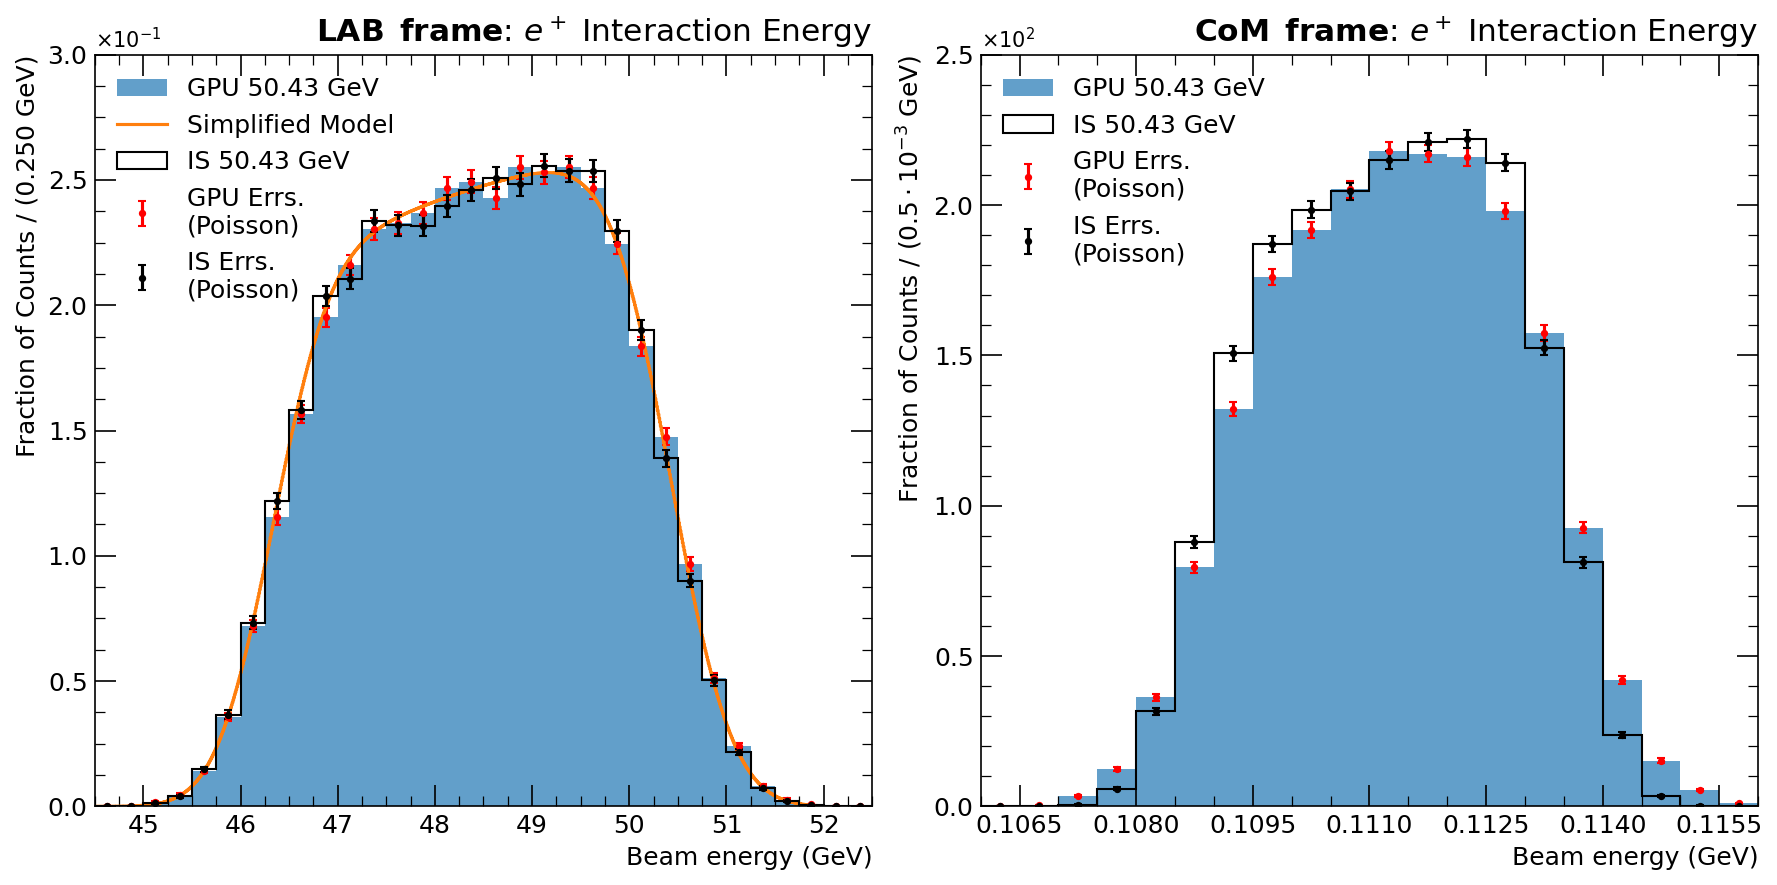

In [143]:
fig = plt.figure(figsize=(12,6))
ax = plt.subplot2grid(shape=(1,2), loc=(0,0), rowspan=1, colspan=1, fig=fig)
pl.PositronInteractionEnergies(ax, data=EnergiesCUDA['E_LAB_positron'], nbins=32, datarange=(44.5,52.5),
                                  xrange=(44.5,52.5),
                                  yrange=(0,0.3),
                                  xminloc=4,
                                  yminloc=4,
                                  ylabel="Fraction of Counts / (0.250 GeV)",
                                  xlabel="Beam energy (GeV)",
                                  figtitle=r"$\bf{LAB\hspace{0.5}frame}$:"+" $e^+$ Interaction Energy",
                                  alpha=0.7,
                                  legend=False,
                                  histlabel="GPU 50.43 GeV",
                                  histerrlabel="GPU Errs.\n(Poisson)",
                                  histerrcolor='red',
                                 )
# plotting the distribution
ax.step(centers_env, f, where='mid',label="Simplified Model", linestyle='solid')
pl.PositronInteractionEnergies(ax, data=EnergiesIS['E_LAB_positron'], nbins=32, datarange=(44.5,52.5), xrange=(44.5,52.5), yrange=(0,0.3),
                                  xminloc=4,
                                  yminloc=4,
                                  ylabel="Fraction of Counts / (0.250 GeV)",
                                  xlabel="Beam energy (GeV)",
                                  figtitle=r"$\bf{LAB\hspace{0.5}frame}$:"+" $e^+$ Interaction Energy",
                                  alpha=1.0,
                                  legend=True,
                                  histlabel="IS 50.43 GeV",
                                  histerrlabel="IS Errs.\n(Poisson)",
                                  histerrcolor='black',
                                  hist_type='step',
                                  hist_color='black'
                                 )

ax1 = plt.subplot2grid(shape=(1,2), loc=(0,1), rowspan=1, colspan=1, fig=fig)
pl.PositronInteractionEnergies(ax1, data=EnergiesCUDA['E_CoM_positron'], nbins=20, datarange=(0.106,0.116),
                                  xrange=(0.106,0.116),
                                  yrange=(0,250),
                                  xminloc=3,
                                  yminloc=5,
                                  ylabel="Fraction of Counts / ($0.5\cdot 10^{-3}$ GeV)",
                                  xlabel="Beam energy (GeV)",
                                  figtitle=r"$\bf{CoM\hspace{0.5}frame}$:"+" $e^+$ Interaction Energy",
                                  alpha=0.7,
                                  histlabel="GPU 50.43 GeV",
                                  histerrlabel="GPU Errs.\n(Poisson)",
                                  histerrcolor='red',
                                  legend=False
                                 )
pl.PositronInteractionEnergies(ax1, data=EnergiesIS['E_CoM_positron'], nbins=20, datarange=(0.106,0.116), xrange=(0.106,0.116),
                                  yrange=(0,250),
                                  xminloc=3,
                                  yminloc=5,
                                  ylabel="Fraction of Counts / ($0.5\cdot 10^{-3}$ GeV)",
                                  xlabel="Beam energy (GeV)",
                                  figtitle=r"$\bf{CoM\hspace{0.5}frame}$:"+" $e^+$ Interaction Energy",
                                  alpha=1.0,
                                  histlabel="IS 50.43 GeV",
                                  histerrlabel="IS Errs.\n(Poisson)",
                                  histerrcolor='black',
                                  hist_type='step',
                                  hist_color='black',
                                  legend=True
                                 )

fig.tight_layout()

As it was expected, there are some discrepancies between the GPU simulation and the data that was inverse-sampled from the simplified model. It is further pointed out that because of the CUDA version available on the GPU platform, the quality of the random number generators could be not up to standard since it has been improved in recent versions.

To investigate the more "problematic" regions, a bin by bin compatibility between the GPU simulation and the inverse-sampled one is calculated, where the test statistic is:
$$
t_i = \frac{\left|x_i^{GPU} - x_i^{IS}\right|}{ \sqrt{(\sigma_i^{GPU})^2 + (\sigma_i^{IS})^2} }
$$
We assume that $t_i$ comes from a normal distribution with $\mu=0$ and $\sigma=1$. Hence, we will say that in the $i$-th bin we don't have compatibility if $t_i$ is larger than $1.96$ which corresponds to a significance level $\alpha = 0.05$.

In [55]:
# compatibility between measurements
cmeas = None
if (MODE==ps.kEDIT): 
    alpha = 0.05
    critical = norm.isf(q=alpha/2)
    
    # binning
    cgpu, egpu = np.histogram(EnergiesCUDA['E_LAB_positron'], bins=32, range=(44.5, 52.5))
    
    res = np.zeros(32)
    for iter in range(1000):
        random_from_cdf = IS_energy(f)
        cis, eis = np.histogram(random_from_cdf, bins=32, range=(44.5, 52.5))
        
        # computing compatibilities
        d = np.abs(cgpu - cis)
        errs = np.sqrt(cgpu + cis)
        comps = []
        for i in range(0,len(d),1):
            if errs[i]>0:
                comps.append(d[i]/errs[i])
            else:
                comps.append(2)
        
        results = comps < critical
        res += results
    res = res/1000
    cmeas = pd.DataFrame()
    cmeas['bin_centers'] = 0.5*(egpu[1:]+egpu[:-1])
    cmeas['compats'] = res
    cmeas.to_pickle('./pkl/GPU_IS_compats.pkl')
else:
    cmeas = pd.read_pickle('./pkl/GPU_IS_compats.pkl')

In [56]:
print(" # | EnergyBin | Prob. of compatibility")
for i in range(0,len(cmeas),1):
    print("%2d |   %2.2f   | %1.3f"%(i, cmeas['bin_centers'][i], cmeas['compats'][i]))

 # | EnergyBin | Prob. of compatibility
 0 |   44.62   | 0.290
 1 |   44.88   | 0.671
 2 |   45.12   | 0.804
 3 |   45.38   | 0.996
 4 |   45.62   | 0.995
 5 |   45.88   | 0.984
 6 |   46.12   | 0.982
 7 |   46.38   | 0.919
 8 |   46.62   | 0.677
 9 |   46.88   | 0.981
10 |   47.12   | 0.994
11 |   47.38   | 0.989
12 |   47.62   | 0.982
13 |   47.88   | 0.984
14 |   48.12   | 0.977
15 |   48.38   | 0.983
16 |   48.62   | 0.901
17 |   48.88   | 0.981
18 |   49.12   | 0.990
19 |   49.38   | 0.983
20 |   49.62   | 0.981
21 |   49.88   | 0.993
22 |   50.12   | 0.935
23 |   50.38   | 0.829
24 |   50.62   | 0.785
25 |   50.88   | 0.961
26 |   51.12   | 0.859
27 |   51.38   | 0.995
28 |   51.62   | 0.974
29 |   51.88   | 0.899
30 |   52.12   | 1.000
31 |   52.38   | 0.000


Now, as it was done before, the diffusion angles are inversed sampled while the radial angles are uniformly generated.

In [73]:
# getting thetas and phis
thetas_cuda = None
phis_cuda = None
thetas_IS = None
phis_IS = None
if MODE==ps.kEDIT:
    # inverse-sampling the distribution of the CUDA simulation
    ISAMPLER = smp.InverseSampler(len(EnergiesCUDA['sqrt_s']), cs.cdf_theta, np.arccos)
    ISAMPLER.runDifferentE(EnergiesCUDA['sqrt_s'])
    thetas_cuda = ISAMPLER.getTransformedSamples()
    phis_cuda = np.random.random(len(EnergiesCUDA['sqrt_s']))*2*np.pi
    # saving npy
    np.save('./npy/InvSampled_Thetas_CUDA.npy', thetas_cuda)
    np.save('./npy/InvSampled_Phis_CUDA.npy', phis_cuda)
    
    # doing the same also for the inverse-sampled from the histogram
    ISAMPLER = smp.InverseSampler(len(EnergiesIS['sqrt_s']), cs.cdf_theta, np.arccos)
    ISAMPLER.runDifferentE(EnergiesIS['sqrt_s'])
    thetas_IS = ISAMPLER.getTransformedSamples()
    phis_IS = np.random.random(len(EnergiesIS['sqrt_s']))*2*np.pi
    # saving npy
    np.save('./npy/InvSampled_Thetas_IS.npy', thetas_IS)
    np.save('./npy/InvSampled_Phis_IS.npy', phis_IS)
else:
    # reading previously saved data
    thetas_cuda = np.load('./npy/InvSampled_Thetas_CUDA.npy')
    phis_cuda = np.load('./npy/InvSampled_Phis_CUDA.npy')
    thetas_IS = np.load('./npy/InvSampled_Thetas_IS.npy')
    phis_IS = np.load('./npy/InvSampled_Phis_IS.npy')

The diffusion angle distribution is shown below with the theoretical curves corresponding to the pdf with minimal and maximal center of mass energy.

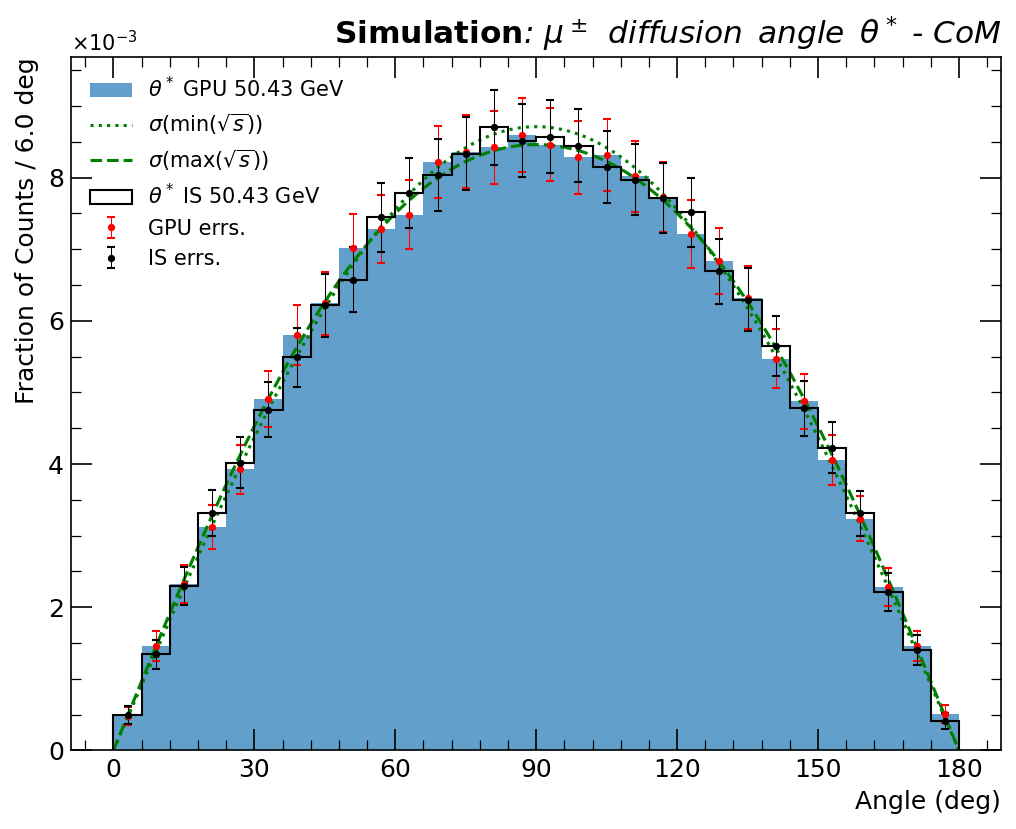

In [74]:
thetas_cuda_deg = thetas_cuda*180/np.pi
fig, ax = plt.subplots(figsize=(8,6))
pl.AnglePlotPad(thetas_cuda_deg, EnergiesCUDA['E_CoM_positron'], cs.pdf_theta, ax, nbins=30, minloc_x=5, 
                   angledist_label="$\\theta^*$ GPU 50.43 GeV",
                   figtitle=r"$\bf{Simulation}$: "+"$\mu^\pm\hspace{0.5}diffusion\hspace{0.5}angle\hspace{0.5}{\\theta}^*$ - CoM",
                   minth_label=r'$\sigma(\min(\sqrt{s}))$',
                   maxth_label=r'$\sigma(\max(\sqrt{s}))$',
                   err_label='GPU errs.',
                   minth_color='green',
                   maxth_color='green'
                  )
thetas_IS_deg = thetas_IS*180/np.pi
pl.AnglePlotPad(thetas_IS_deg, EnergiesIS['E_CoM_positron'], cs.pdf_theta, ax, nbins=30, minloc_x=5, 
                   angledist_label="$\\theta^*$ IS 50.43 GeV",
                   figtitle=r"$\bf{Simulation}$: "+"$\mu^\pm\hspace{0.5}diffusion\hspace{0.5}angle\hspace{0.5}{\\theta}^*$ - CoM",
                   minth_label=r'IS $\sigma(\min(\sqrt{s}))$',
                   maxth_label=r'IS $\sigma(\max(\sqrt{s}))$',
                   err_label='IS errs.',
                   err_color='black',
                   minth_color='green',
                   maxth_color='green',
                   hist_type='step',
                   hist_color='black',
                   alpha=1,
                   draw_minmaxth=False
                  )

Now the quantities related to the muon-antimuon pairs are calculated as it was done before.

In [75]:
# calculating quantities for the generated Muon-AntiMuon pairs for both CUDA sim and the IS one
if MODE==ps.kEDIT:
    # Absolute value of p-vector in the center of mass
    EnergiesCUDA["absP_MuMu_CoM"] = np.sqrt((EnergiesCUDA['E_CoM_positron'])**2 - m_mu**2)
    EnergiesIS["absP_MuMu_CoM"] = np.sqrt((EnergiesIS['E_CoM_positron'])**2 - m_mu**2)

    # Momenta in the CoM - CUDA
    EnergiesCUDA["CoM_AntiMuon_px"] = EnergiesCUDA["absP_MuMu_CoM"]*np.cos(phis_cuda)*np.sin(thetas_cuda)
    EnergiesCUDA["CoM_AntiMuon_py"] = EnergiesCUDA["absP_MuMu_CoM"]*np.sin(phis_cuda)*np.sin(thetas_cuda)
    EnergiesCUDA["CoM_AntiMuon_pz"] = EnergiesCUDA["absP_MuMu_CoM"]*np.cos(thetas_cuda)
    EnergiesCUDA["CoM_Muon_px"] = -EnergiesCUDA["CoM_AntiMuon_px"]
    EnergiesCUDA["CoM_Muon_py"] = -EnergiesCUDA["CoM_AntiMuon_py"]
    EnergiesCUDA["CoM_Muon_pz"] = -EnergiesCUDA["CoM_AntiMuon_pz"]

    # Momenta in the CoM - IS
    EnergiesIS["CoM_AntiMuon_px"] = EnergiesIS["absP_MuMu_CoM"]*np.cos(phis_IS)*np.sin(thetas_IS)
    EnergiesIS["CoM_AntiMuon_py"] = EnergiesIS["absP_MuMu_CoM"]*np.sin(phis_IS)*np.sin(thetas_IS)
    EnergiesIS["CoM_AntiMuon_pz"] = EnergiesIS["absP_MuMu_CoM"]*np.cos(thetas_IS)
    EnergiesIS["CoM_Muon_px"] = -EnergiesIS["CoM_AntiMuon_px"]
    EnergiesIS["CoM_Muon_py"] = -EnergiesIS["CoM_AntiMuon_py"]
    EnergiesIS["CoM_Muon_pz"] = -EnergiesIS["CoM_AntiMuon_pz"]
    
    # Boosting AntiMuons to the LAB - CUDA
    b2L = LB.boost2LAB(EnergiesCUDA['CoM_AntiMuon_pz'], EnergiesCUDA["E_CoM_positron"])
    pB,EB = b2L['pz'], b2L['E']
    EnergiesCUDA['LAB_AntiMuon_px'] = EnergiesCUDA['CoM_AntiMuon_px']
    EnergiesCUDA['LAB_AntiMuon_py'] = EnergiesCUDA['CoM_AntiMuon_py']
    EnergiesCUDA['LAB_AntiMuon_pz'] = pB

    # Boosting AntiMuons to the LAB - IS
    b2L = LB.boost2LAB(EnergiesIS['CoM_AntiMuon_pz'], EnergiesIS["E_CoM_positron"])
    pB,EB = b2L['pz'], b2L['E']
    EnergiesIS['LAB_AntiMuon_px'] = EnergiesIS['CoM_AntiMuon_px']
    EnergiesIS['LAB_AntiMuon_py'] = EnergiesIS['CoM_AntiMuon_py']
    EnergiesIS['LAB_AntiMuon_pz'] = pB

    # Boosting Muons to the LAB - CUDA
    b2L = LB.boost2LAB(EnergiesCUDA['CoM_Muon_pz'], EnergiesCUDA["E_CoM_positron"])
    pB, EB = b2L['pz'], b2L['E']
    EnergiesCUDA['LAB_Muon_px'] = EnergiesCUDA['CoM_Muon_px']
    EnergiesCUDA['LAB_Muon_py'] = EnergiesCUDA['CoM_Muon_py']
    EnergiesCUDA['LAB_Muon_pz'] = pB

    # Boosting Muons to the LAB - IS
    b2L = LB.boost2LAB(EnergiesIS['CoM_Muon_pz'], EnergiesIS["E_CoM_positron"])
    pB, EB = b2L['pz'], b2L['E']
    EnergiesIS['LAB_Muon_px'] = EnergiesIS['CoM_Muon_px']
    EnergiesIS['LAB_Muon_py'] = EnergiesIS['CoM_Muon_py']
    EnergiesIS['LAB_Muon_pz'] = pB
    
    # Saving
    EnergiesCUDA.to_pickle('./pkl/EnergiesCUDA_dataFrame.pkl')
    EnergiesIS.to_pickle('./pkl/EnergiesIS_dataFrame.pkl')

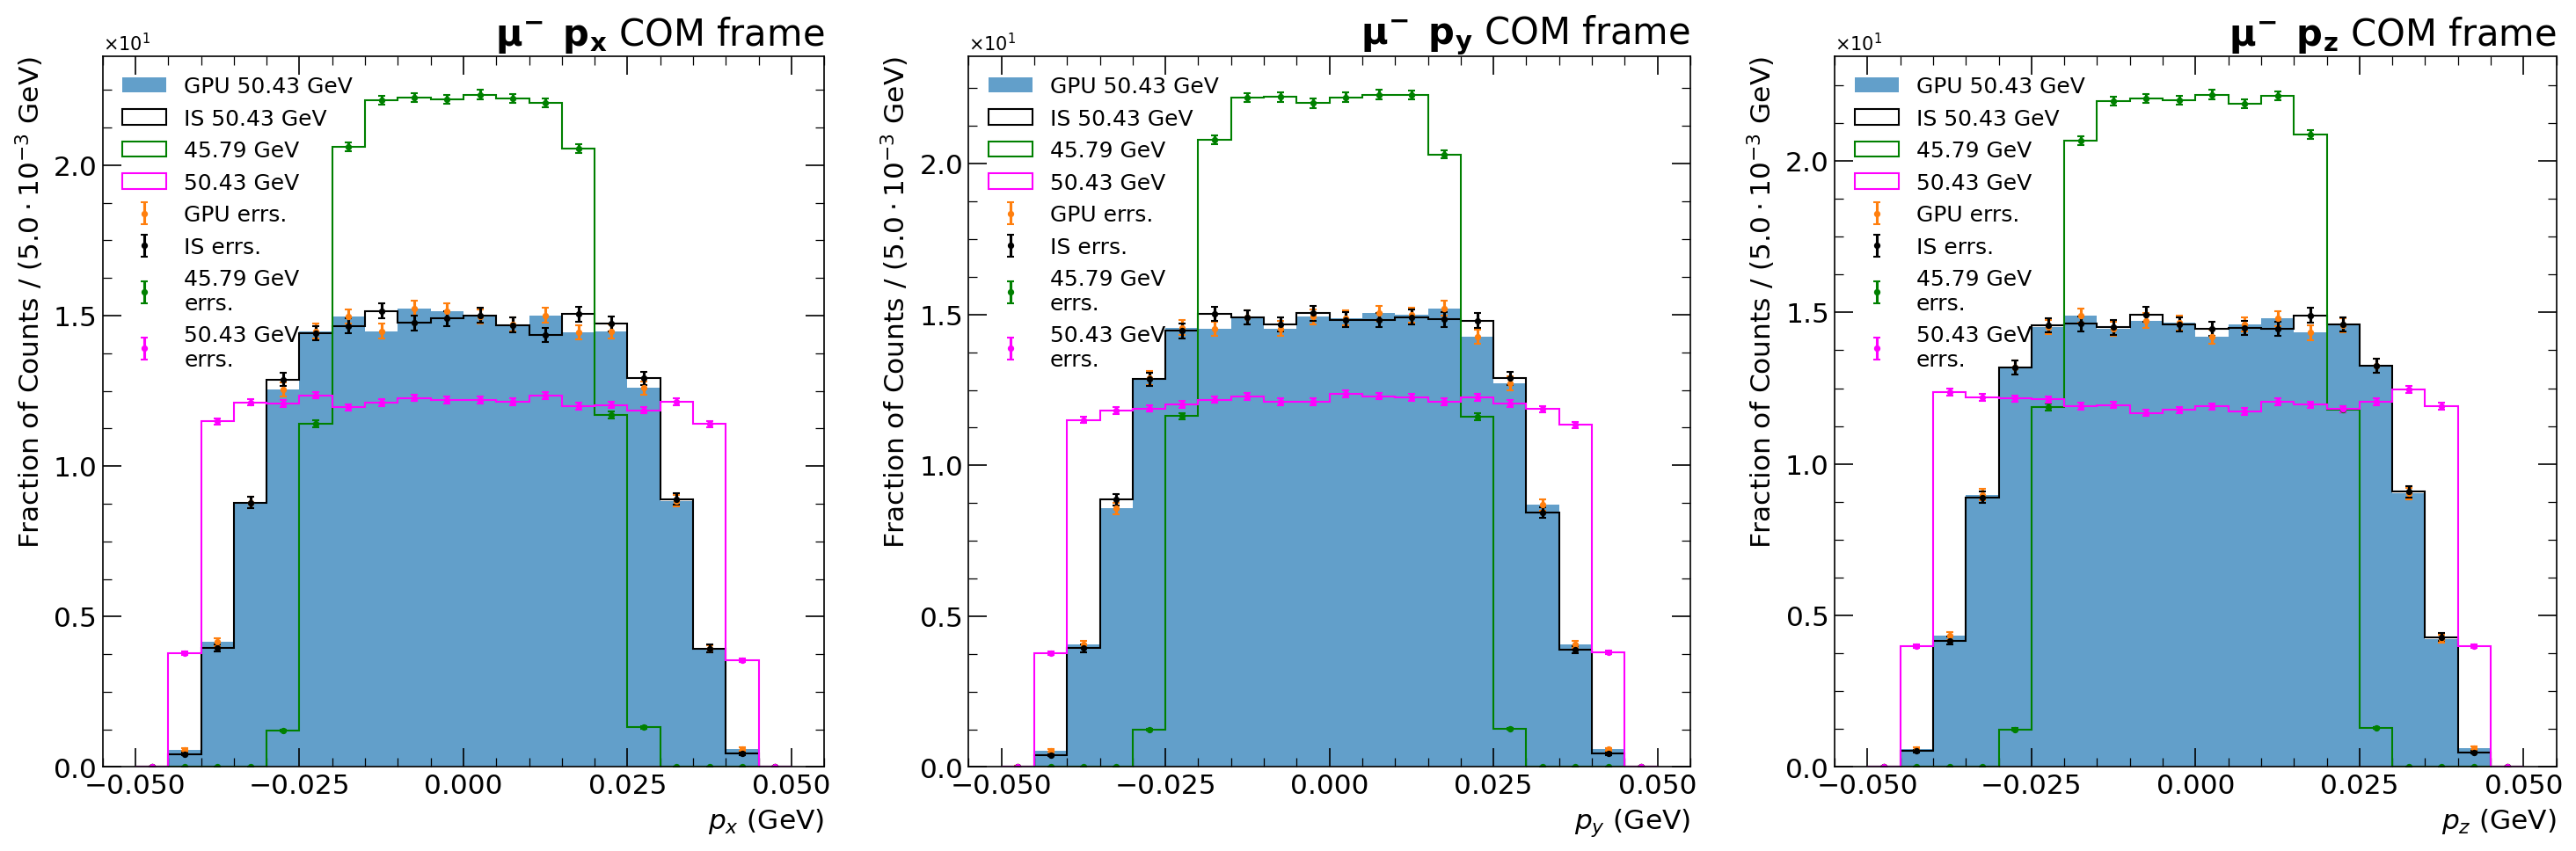

In [84]:
# plotting the momenta distributions of the muons in the CoM frame
fig, ax = plt.subplots(1,3,figsize=(24,7))
plot_features = ['CoM_Muon_px', 'CoM_Muon_py', 'CoM_Muon_pz']
plot_labels = ['x', 'y', 'z']
pl.MuonPlotsCOMPads(ax, EnergiesCUDA,
                    plot_features=plot_features,
                    plot_labels=plot_labels,
                    xrange=(-0.05,0.05),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                       ticksize_minor=8,
                       ticksize_major=15,
                       plotlabel="GPU 50.43 GeV",
                       errlabel="GPU errs.",
                       alpha=0.7
                 )
pl.MuonPlotsCOMPads(ax, EnergiesIS,
                    plot_features=plot_features,
                    plot_labels=plot_labels,
                    xrange=(-0.05,0.05),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                       ticksize_minor=8,
                       ticksize_major=15,
                       plotlabel="IS 50.43 GeV",
                       errlabel="IS errs.",
                       alpha=1.0,
                       histtype='step',
                    plot_color='black',
                    err_color='black'
                 )
pl.MuonPlotsCOMPads(ax, EnergiesOk,
                    plot_features=plot_features,
                    plot_labels=plot_labels,
                    xrange=(-0.05,0.05),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                       ticksize_minor=8,
                       ticksize_major=15,
                       plotlabel="45.79 GeV",
                       errlabel="45.79 GeV\nerrs.",
                       alpha=1.0,
                       histtype='step',
                    plot_color='green',
                    err_color='green'
                 )
pl.MuonPlotsCOMPads(ax, EnergiesCorrected,
                    plot_features=plot_features,
                    plot_labels=plot_labels,
                    xrange=(-0.05,0.05),
                    title_size=20,
                    xlabel_size=15,
                    ylabel_size=15,
                       ticksize_minor=8,
                       ticksize_major=15,
                       plotlabel="50.43 GeV",
                       errlabel="50.43 GeV\nerrs.",
                       legend=True,
                       legend_size=12,
                       legend_loc=2,
                       histtype='step',
                       alpha=1.0,
                    plot_color='magenta',
                    err_color='magenta'
                 )

For each pad, four momenta distributions are shown. The "filled" distribution represents the results of the GPU simulation, with the target in place. The "IS" distribution refers to the one obtained by inverse-sampling the computed pdf. The other two distributions refer to the previous setups with the gaussian beam and no target, where every positron with compatible energy for $\mu^\pm$ production was assumed to generate an event.

The different shapes of the momenta distributions might be explained as follows.
1. When there is no target, the energy spectrum of the positrons that interact is the incident gaussian beam itself.
   + For lower beam energies, the $\theta^*$ angle distribution becomes steeper around $90$ degrees thus reducing the "plateau" region that is visible in the momenta distributions around $p_{x,y,z}=0$. The distribution is narrower because with less energy the momenta components are also smaller.
   + Conversely, for higher beam energies, the $\theta^*$ angle distribution becomes flatter around $90$ degrees, effectively widening the "plateau" region and the distribution widens because of the increased energy yielding higher momenta components.

2. When a target is present, as it was previously shown, we no longer have that the interacting positrons' energy spectrum is a gaussian. As a consequence if we compare, at the same energy, the momenta distribution with the target and the one without it, we see that the one with the target is narrower. Furthermore:
   + For a thin target, the shape of the distribution will approximate that of the high energy, no target distribution since the loss due to transport in the material will tend to zero.
   + For a thick target, the shape of the distribution will instead become similar to the low energy, no target distribution. For a given incident beam energy, if the thickness of the target is increased beyond a certain limit, there won't be a deeper production of $\mu^\pm$ since the energy loss will be so large that the positrons won't have sufficient energy to trigger the production process. So, the shape of the distribution will "saturate" towards a limit.

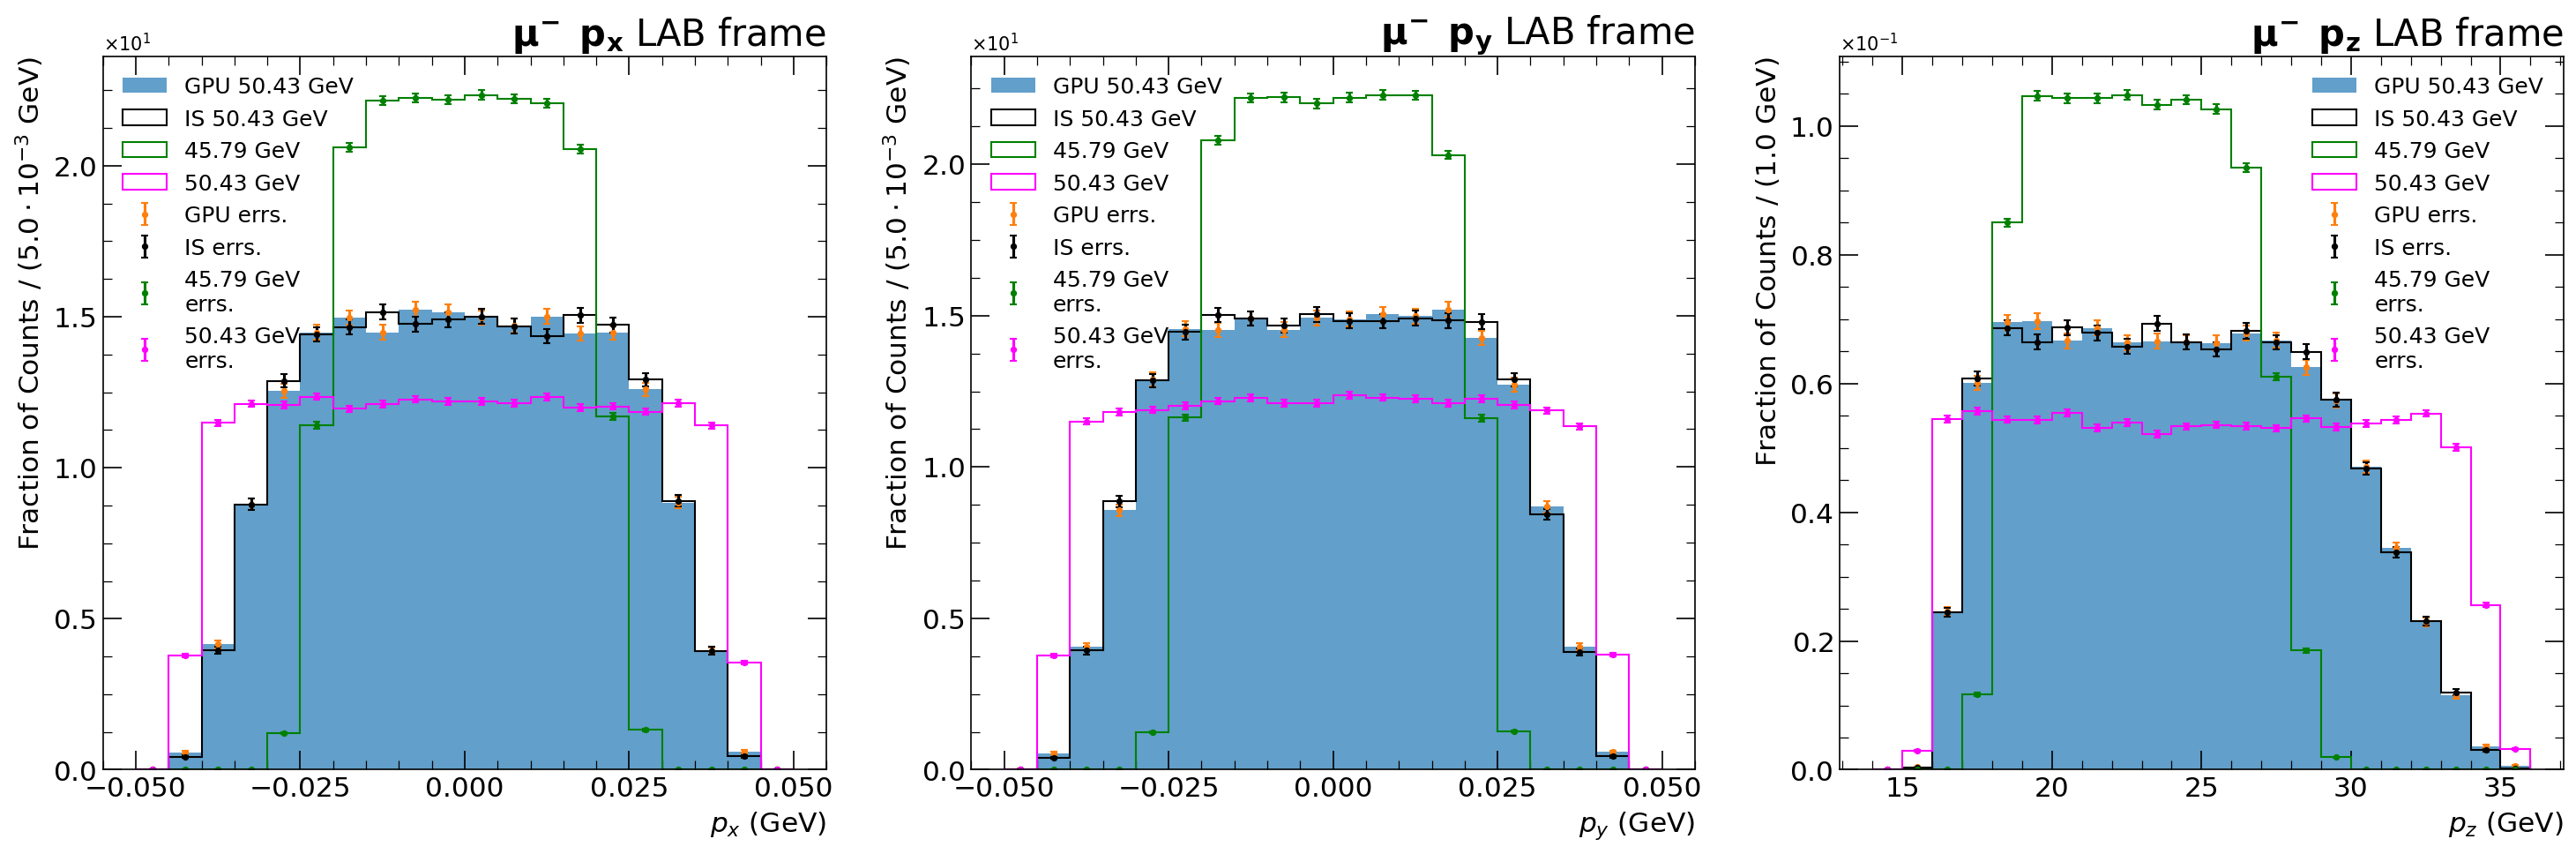

In [85]:
fig, ax = plt.subplots(1,3,figsize=(24,7))
plot_features = ['LAB_Muon_px', 'LAB_Muon_py', 'LAB_Muon_pz']
plot_labels = ['x', 'y', 'z']
pl.MuonPlotsLABPads(ax, EnergiesCUDA,
                       plot_features=plot_features,
                       plot_labels=plot_labels,
                       xrange_xy=(-0.05,0.05),
                       xrange_z=(14,36),
                       nbins_z=22,
                       title_size=20,
                       xlabel_size=15,
                       ylabel_size=15,
                       plotlabel="GPU 50.43 GeV",
                       errlabel="GPU errs.",
                       minloc_x_z=5,
                       maxloc_x_z=5,
                       alpha=0.7
                 )
pl.MuonPlotsLABPads(ax, EnergiesIS,
                       plot_features=plot_features,
                       plot_labels=plot_labels,
                       xrange_xy=(-0.05,0.05),
                       xrange_z=(14,36),
                       nbins_z=22,
                       title_size=20,
                       xlabel_size=15,
                       ylabel_size=15,
                       plotlabel="IS 50.43 GeV",
                       errlabel="IS errs.",
                       minloc_x_z=5,
                       maxloc_x_z=5,
                       alpha=1.0,
                       histtype='step',
                    plot_color='black',
                    err_color='black'
                 )
pl.MuonPlotsLABPads(ax, EnergiesOk,
                       plot_features=plot_features,
                       plot_labels=plot_labels,
                       xrange_xy=(-0.05,0.05),
                       xrange_z=(14,36),
                       nbins_z=22,
                       title_size=20,
                       xlabel_size=15,
                       ylabel_size=15,
                       plotlabel="45.79 GeV",
                       errlabel="45.79 GeV\nerrs.",
                       minloc_x_z=5,
                       maxloc_x_z=5,
                       alpha=1,
                       histtype='step',
                    plot_color='green',
                    err_color='green'
                 )
pl.MuonPlotsLABPads(ax, EnergiesCorrected,
                       plot_features=plot_features,
                       plot_labels=plot_labels,
                       xrange_xy=(-0.05,0.05),
                       xrange_z=(14,36),
                       nbins_z=22,
                       title_size=20,
                       xlabel_size=15,
                       ylabel_size=15,
                       ticksize_minor=8,
                       ticksize_major=15,
                       plotlabel="50.43 GeV",
                       errlabel="50.43 GeV\nerrs.",
                       legend=True,
                       legend_size=12,
                       legend_loc=2,
                       minloc_x_z=5,
                       maxloc_x_z=5,
                       histtype='step',
                       alpha=1.0,
                    plot_color='magenta',
                    err_color='magenta'
                 )
ax[2].legend(loc=0, fontsize=12, frameon=False)

The figure above shows the same quantities as before but boosted in the LAB frame.

#### Appendix - CUDA kernel
```c++
__global__ void Propagate(curandStateMRG32k3a* custate, unsigned int max_it, unsigned int n_l, double* d_z, double* d_ec, double* d_el)
{
    // setting some vars
    int idx = threadIdx.x + blockIdx.x * blockDim.x;
    unsigned int n_layers = n_l;
    double step_size = 3./n_layers;
    bool interact = false;
    unsigned int iter = 0;

    // starting particle sampling loop (up to 'max_it')
    while (iter < max_it) {
        // sampling the beam
        double e_lab0 = generate_normal_kernel(custate)*sigmaLAB + eLAB_0;
        // generates a random offset between 0 and step_size
        double z = generate_uniform_kernel(custate)*step_size;
        // for instance if the step size is 0.1, then we have a random offset ranging from 0 to 0.1
        // the step size itself is equal to all the threads but the initial offset allows each thread to sample the energy
        // at slightly offsetted spatial values.
        // starting propagation loop through the layers
        for (unsigned int it = 0; it < n_layers; it++) {
            // computing the energy at this depth
            double e = e_lab0*exp(-1.0*z/35.28);
            // boosting to center of mass
            double eCom = boost2CoM(sqrtf(e*e - electron_mass*electron_mass), e);
            // check if energy compatible with production
            if (eCom > muon_mass) {
                // computing the cross section
                double s = 4*eCom*eCom;
                double p = processTotalCS_nb(s);
                p *= step_size*target_Ne*1e-9*1e-24;
                // sampling a unif(0,1)
                double u = generate_uniform_kernel(custate);
                if (u < p) {
                    // interaction!
                    d_z[idx] = z;
                    d_ec[idx] = eCom;
                    d_el[idx] = e;
                    interact = true;
                    // stopping propagation cycle since the positron interacted
                    iter = max_it;
                    break;
                } else {
                    // no interaction, go deeper
                    z += step_size;
                }
            } else {
                // energy is incompatible with production, stopping propagation cycle
                break;
            }
        }
        // increment and propagate another
        iter++;
    }
    // if there was no interaction, set values as follows
    if (!interact) {
        d_z[idx] = -1;
        d_ec[idx] = -1;
        d_el[idx] = -1;
    }
}
```

### References

[1] [Hit or Miss MonteCarlo](https://www.researchgate.net/figure/The-basic-principle-of-the-Monte-Carlo-hit-and-miss-method_fig6_323557242)

[2] Anderson, E. C. (1999, October 20). Monte Carlo methods and importance sampling. ib.berkeley.edu. https://ib.berkeley.edu/labs/slatkin/eriq/classes/guest_lect/mc_lecture_notes.pdf

[3] Christian P. Robert (2015, April 08). The Metropolis-Hastings algorithm. https://arxiv.org/abs/1504.01896

[4] Sampling from a probability distribution https://cs.brown.edu/courses/cs1951k/lectures/2020/inverse_transform_sampling.pdf

[5] A. Doucet, N. de Freitas, N. Gordon. An Introduction To Sequential MonteCarlo Methods https://www.stats.ox.ac.uk/~doucet/doucet_defreitas_gordon_smcbookintro.pdf

[6] Stratified Sampling, ScienceDirect https://www.sciencedirect.com/topics/mathematics/stratified-sampling)

[7] Relativistic Kinematics of Particle Interactions, W von Schlipp e March 2002 https://web.physics.utah.edu/~jui/5110/hw/kin_rel.pdf

[8] Production of the Smallest QED Atom: True Muonium (𝜇+⁢𝜇−) Stanley J. Brodsky and Richard F. Lebed Phys. Rev. Lett. 102, 213401 – Published 26 May 2009

[9] Muon production and accumulation from positrons on target, M. Boscolo ,1,* M. Antonelli,1 A. Ciarma ,1 and P. Raimondi2 1INFN-LNF, Via E. Fermi 40, 00044 Frascati, Rome, Italy 2ESRF, 71 avenue des Martyrs, 38000 Grenoble, France

[10] Tranverse shape of beam https://cds.cern.ch/record/1213283/files/p377.pdf

[11] FLUKA: a multi-particle transport code. A. Ferrari, P.R. Sala, A. Fasso, and J. Ranft, CERN-2005-10 (2005), INFN/TC_05/11, SLAC-R-773

[12] Sigmund, P. S. (2005). Particle Penetration and Radiation Effects: General Aspects and Stopping of Swift Point Charges (1st ed.). Springer Berlin, Heidelberg. https://doi.org/10.1007/3-540-31718-X